# ML Project

## Data Modeling

### Ranking Problem (First Problem)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor

# Load the dataset
file_path = '../dataset_for_modeling/features_for_ranking.csv'
rank_teams = pd.read_csv(file_path)

feature_columns = [
    "player_awards", "net_rating", "off_eff", "def_eff", "home_win_pct",
    "away_win_pct", "reb_dif", "conf_win_pct", "ast_dif", "blk_dif",
    "pf_dif", "coach_awards", "efg_pct", "win_pct", "pts_per_poss",
    "ts_pct", "eff_x_pace", "net_four_factors", "pyth_wins"
]

# Add 'rank' and 'confID' for lagging and grouping
base_columns = feature_columns + ['rank', 'confID']

# Ensure data is sorted by team and year for correct lagging
rank_teams = rank_teams.sort_values(by=['tmID', 'year'])


In [2]:
# Create Lag-1 Features (Last Year's Stats)
lag1_feature_names = [f"{col}_lag1" for col in base_columns]
rank_teams[lag1_feature_names] = rank_teams.groupby('tmID')[base_columns].shift(1)

# Create 3-Year Rolling Avg Features
cols_to_weight = feature_columns + ['rank']
avg3yr_feature_names = [f"{col}_avg3yr_lag" for col in cols_to_weight]

# Define the weighted average function
def weighted_avg(series):
    """
    Calculates a weighted average adapting to available history (1, 2, or 3 years).
    Weights: 0.5 (Last Year), 0.3 (2 Years Ago), 0.2 (3 Years Ago).
    """
    weights = np.array([0.2, 0.3, 0.5])
    
    # Convert series to array to handle NaNs safely
    s = np.array(series)
    mask = ~np.isnan(s)
    
    # If no valid data exists in the window, return NaN
    if not np.any(mask):
        return np.nan
        
    # Adjust weights to the window size and available data
    w = weights[-len(s):]
    valid_s = s[mask]
    valid_w = w[mask]
    
    # Normalize by the sum of valid weights
    return np.sum(valid_s * valid_w) / np.sum(valid_w)

# Calculate rolling average on the lag-1 features
# min_periods=1 ensures we calculate averages even for teams with short history
rolling_avg_features = rank_teams.groupby('tmID')[[f"{col}_lag1" for col in cols_to_weight]] \
                                 .rolling(window=3, min_periods=1) \
                                 .apply(weighted_avg, raw=True)

# Align the rolling average index
rank_teams[avg3yr_feature_names] = rolling_avg_features.reset_index(level=0, drop=True)

# Clean Data
# Only drop rows if Lag-1 data is missing.
# This keeps teams that have Year N-1 data but lack Year N-2 or N-3.
model_df = rank_teams.dropna(subset=lag1_feature_names)

print(f"Original shape: {rank_teams.shape}, Model-ready shape: {model_df.shape}")


Original shape: (142, 65), Model-ready shape: (122, 65)


In [3]:
# The target is always the rank of the CURRENT year
target_col = 'rank'

# Experiment A: Use only last year's stats
features_lag1 = [f"{col}_lag1" for col in feature_columns] + ['rank_lag1']

# Experiment B: Use only the 3-year average stats
features_avg3yr = [f"{col}_avg3yr_lag" for col in feature_columns] + ['rank_avg3yr_lag']

# Experiment C: Use both sets
features_combined = features_lag1 + features_avg3yr

feature_sets = {
    "Lag 1 Only": features_lag1,
    "Avg 3-Year Only": features_avg3yr,
    "Combined": features_combined
}


In [4]:
TEST_YEAR = 10
VALIDATION_YEAR = 9

# Train: All years BEFORE the validation year
train_df = model_df[model_df['year'] < VALIDATION_YEAR] # Years 2-8
y_train = train_df[target_col]

# Validate: Only the validation year
val_df = model_df[model_df['year'] == VALIDATION_YEAR] # Year 9
y_val = val_df[target_col]

# Test: Only the test year
test_df = model_df[model_df['year'] == TEST_YEAR] # Year 10
y_test = test_df[target_col]

print(f"Training observations: {len(train_df)}")
print(f"Validation observations: {len(val_df)}")
print(f"Test observations: {len(test_df)}")


Training observations: 96
Validation observations: 13
Test observations: 13


In [5]:
# Get the baseline prediction (last year's rank)
y_pred_baseline = val_df['rank_lag1']

y_pred_baseline.head()

# Evaluate baseline on the Validation set
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
spearman_baseline, _ = spearmanr(y_val, y_pred_baseline)

print("--- Baseline Model (on Validation Set) ---")
print(f"  MAE: {mae_baseline:.4f}")
print(f"  Spearman Rank: {spearman_baseline:.4f}")


--- Baseline Model (on Validation Set) ---
  MAE: 1.5385
  Spearman Rank: 0.4008


In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Ridge Regression': Ridge(),
    'SVR':SVR(),
    'AdaBoost':AdaBoostRegressor(random_state=42)
}

results = []

for fs_name, fs_cols in feature_sets.items():
    print(f"\n--- Testing Feature Set: {fs_name} ---")
    
    # Define X data based on the current feature set
    X_train = train_df[fs_cols]
    X_val = val_df[fs_cols]

    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    for name, model in models.items():
        # Fit model
        model.fit(X_train_scaled, y_train)
        y_pred_val = model.predict(X_val_scaled)
        
        # Evaluate model
        mae = mean_absolute_error(y_val, y_pred_val)
        spearman_corr, _ = spearmanr(y_val, y_pred_val)
        
        print(f"  Model: {name}")
        print(f"    MAE: {mae:.4f} (Baseline: {mae_baseline:.4f})")
        print(f"    Spearman: {spearman_corr:.4f} (Baseline: {spearman_baseline:.4f})")
        
        results.append((fs_name, name, mae, spearman_corr))

best_result = min(results, key=lambda item: item[2])
best_fs_name, best_model_name, best_mae, best_spearman = best_result

print(f"\n--- Best Model from Validation (based on MAE) ---")
print(f"  Feature Set: {best_fs_name}")
print(f"  Model: {best_model_name}")
print(f"  Spearman: {best_spearman:.4f}")



--- Testing Feature Set: Lag 1 Only ---
  Model: Linear Regression
    MAE: 2.0144 (Baseline: 1.5385)
    Spearman: 0.0277 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.6900 (Baseline: 1.5385)
    Spearman: 0.1551 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 1.9915 (Baseline: 1.5385)
    Spearman: 0.1108 (Baseline: 0.4008)
  Model: Ridge Regression
    MAE: 1.9424 (Baseline: 1.5385)
    Spearman: 0.0416 (Baseline: 0.4008)
  Model: SVR
    MAE: 1.6298 (Baseline: 1.5385)
    Spearman: 0.2299 (Baseline: 0.4008)
  Model: AdaBoost
    MAE: 1.8926 (Baseline: 1.5385)
    Spearman: 0.0360 (Baseline: 0.4008)

--- Testing Feature Set: Avg 3-Year Only ---
  Model: Linear Regression
    MAE: 1.7001 (Baseline: 1.5385)
    Spearman: 0.0277 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.7492 (Baseline: 1.5385)
    Spearman: -0.0526 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 1.7169 (Baseline: 1.5385)
    Spearman: 0.0693 (Baseline: 0.4008)
  Model: Ridge Regression


In [7]:
# Prepare Data (Train + Validation combined for Cross-Validation)
# We use the best feature set found in the previous step
best_features = feature_sets[best_fs_name]

X_train_full = pd.concat([train_df[best_features], val_df[best_features]])
y_train_full = pd.concat([y_train, y_val])

# Define Models and their Hyperparameter Grids
model_configs = {
    "Random Forest (no scaler)": {
        "model": Pipeline([
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ['sqrt', 'log2', None]
        }
    },
    "Random Forest (scaled)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ['sqrt', 'log2', None]
        }
    },

    "Gradient Boosting": {
        "model": Pipeline([
            ("model", GradientBoostingRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 300, 500, 1000],
            "model__learning_rate": [0.005, 0.01, 0.05, 0.1],
            "model__max_depth": [3, 4, 5],
            "model__subsample": [0.7, 0.8, 0.9, 1.0]
        }
    },

    "Ridge Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        "params": {
            "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
        }
    },

    "SVR": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR())
        ]),
        "params": {
            "model__C": [0.1, 1, 10, 100, 1000],
            "model__kernel": ['linear', 'rbf', 'poly'],
            "model__epsilon": [0.01, 0.1, 0.2, 0.5],
            "model__gamma": ['scale', 'auto', 0.1, 0.01]
        }
    },

    "AdaBoost": {
        "model": Pipeline([
            ("model", AdaBoostRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [50, 100, 300, 500],
            "model__learning_rate": [0.001, 0.01, 0.1, 1.0],
            "model__loss": ['linear', 'square', 'exponential']
        }
    },

    "Linear Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "params": {
            "model__fit_intercept": [True, False]
        }
    }
}

# Run Systematic Grid Search for all Models
results = []
best_overall_model = None
best_overall_score = -float("inf") # Since we use neg_MAE, closer to 0 is better

print(f"--- Starting Extensive Grid Search on {len(model_configs)} Models ---")

for name, config in model_configs.items():
    print(f"\nTraining {name}...")
    
    # Setup Grid Search
    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=3,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=1
    )
    
    # Train
    grid.fit(X_train_full, y_train_full)
    
    # Get results (Convert neg_MAE to positive MAE for readability)
    best_mae = -grid.best_score_

    print(f"  > Best MAE: {best_mae:.4f}")
    print(f"  > Best Params: {grid.best_params_}")
    
    results.append({
        "Model": name,
        "MAE": best_mae,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })
    
    # Track the global winner
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_model = grid.best_estimator_
        best_model_name = name

# Summary
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='MAE', ascending=True)

print("\n--- Model Classification Table ---")
print(results_df[['Model', 'MAE', 'Best_Params']].to_string(index=False))

print("\n==================================================")
print(f"Best Model in Training: {best_model_name} with MAE: {-best_overall_score:.4f}")
print("==================================================")

# Set final_model to the winner
final_model = best_overall_model


--- Starting Extensive Grid Search on 7 Models ---

Training Random Forest (no scaler)...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits
  > Best MAE: 1.6144
  > Best Params: {'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Training Random Forest (scaled)...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits
  > Best MAE: 1.6160
  > Best Params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 500}

Training Gradient Boosting...
Fitting 3 folds for each of 192 candidates, totalling 576 fits
  > Best MAE: 1.6617
  > Best Params: {'model__learning_rate': 0.005, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.9}

Training Ridge Regression...
Fitting 3 folds for each of 7 candidates, totalling 21 fits
  > Best MAE: 1.5425
  > Best Params: {'model__alph


--- Baseline Model Evaluation (on Test Set: Year 10) ---
  MAE: 2.4615
  Spearman Rank: -0.1299


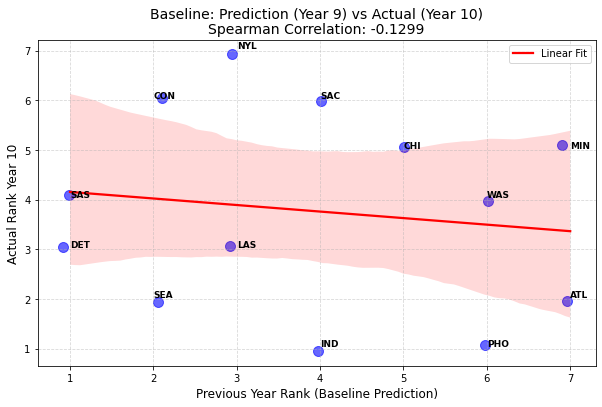

In [8]:
# --- Baseline for the final test set
y_pred_baseline_test = test_df['rank_lag1']
mae_baseline_test = mean_absolute_error(y_test, y_pred_baseline_test)
spearman_baseline_test, _ = spearmanr(y_test, y_pred_baseline_test)

print("\n--- Baseline Model Evaluation (on Test Set: Year 10) ---")
print(f"  MAE: {mae_baseline_test:.4f}")
print(f"  Spearman Rank: {spearman_baseline_test:.4f}")

plt.figure(figsize=(10, 6))

# Create Plot (Scatter + Regression Line)
# x_jitter helps to see overlapping points (e.g., two teams that were rank 1)
sns.regplot(x='rank_lag1', y='rank', data=test_df, 
            x_jitter=0.1, y_jitter=0.1, 
            scatter_kws={'s': 100, 'alpha': 0.6, 'color': 'blue'},
            line_kws={'color': 'red', 'label': 'Linear Fit'})

# Add Labels (Team Name) to each point
for i, row in test_df.iterrows():
    plt.text(row['rank_lag1'], row['rank'], row['tmID'], 
             fontsize=9, ha='left', va='bottom', fontweight='bold')

plt.title(f"Baseline: Prediction (Year 9) vs Actual (Year 10)\nSpearman Correlation: {spearman_baseline_test:.4f}", fontsize=14)
plt.xlabel("Previous Year Rank (Baseline Prediction)", fontsize=12)
plt.ylabel("Actual Rank Year 10", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


--- Evaluating all optimized models on the Test Set (Year 10) ---

--- Final Showdown: Validation vs Test Performance ---
                    Model  Validation MAE  Test MAE (Year 10)  Test RMSE (Year 10)  Test Spearman  Generalization Gap
        Gradient Boosting        1.661749            1.569169             1.944438       0.340732           -0.092580
                 AdaBoost        1.642701            1.608809             2.049619       0.160670           -0.033892
   Random Forest (scaled)        1.616001            1.621726             2.013023       0.204993            0.005726
Random Forest (no scaler)        1.614391            1.623930             2.018708       0.249316            0.009539
         Ridge Regression        1.542538            1.692867             2.178466       0.152360            0.150329
                      SVR        1.512323            1.875235             2.450020       0.088646            0.362911
        Linear Regression        2.176105           

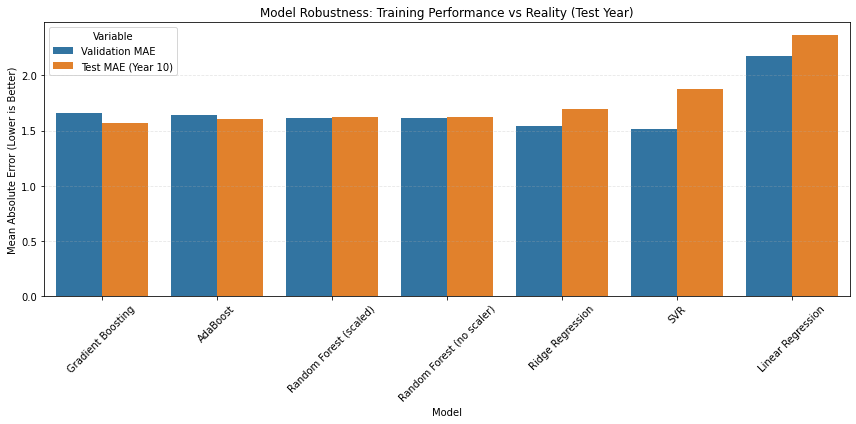


=== Weighted ensemble of top regression models (Year 10) ===
Ensemble MAE:      1.5984
Ensemble RMSE:     1.9948
Ensemble Spearman: 0.3158

--- Ensemble Predicted vs. Actual Rankings (Year 10) ---
confID tmID  actual_rank  baseline_rank  predicted_rank_model
    EA  IND            1            4.0                     2
    EA  ATL            2            7.0                     7
    EA  DET            3            1.0                     1
    EA  WAS            4            6.0                     6
    EA  CHI            5            5.0                     5
    EA  CON            6            2.0                     3
    EA  NYL            7            3.0                     4
    WE  PHO            1            6.0                     3
    WE  SEA            2            2.0                     1
    WE  LAS            3            3.0                     2
    WE  SAS            4            1.0                     5
    WE  MIN            5            7.0                   

In [11]:
# Prepare Test Data
X_test = test_df[best_features]
y_test = test_df[target_col]

print(f"--- Evaluating all optimized models on the Test Set (Year 10) ---")

final_comparison = []

# Iterate through the results of the Grid Search
for index, row in results_df.iterrows():
    model_name = row['Model']
    trained_model = row['Best_Estimator']
    val_mae = row['MAE']
    
    # Predict on Test Set (Year 10)
    y_pred_test = trained_model.predict(X_test)
    
    # Calculate Test Metrics
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_spearman, _ = spearmanr(y_test, y_pred_test)
    
    final_comparison.append({
        "Model": model_name,
        "Validation MAE": val_mae,
        "Test MAE (Year 10)": test_mae,
        "Test RMSE (Year 10)": test_rmse,
        "Test Spearman": test_spearman,
        "Generalization Gap": test_mae - val_mae,
        "Best_Estimator": trained_model
    })

# Create DataFrame for comparison
comparison_df = pd.DataFrame(final_comparison)
comparison_df = comparison_df.sort_values(by='Test MAE (Year 10)', ascending=True)

display_cols = ["Model", "Validation MAE", "Test MAE (Year 10)", "Test RMSE (Year 10)", "Test Spearman", "Generalization Gap"]

print("\n--- Final Showdown: Validation vs Test Performance ---")
print(comparison_df[display_cols].to_string(index=False))

# Plot Comparison
plt.figure(figsize=(12, 6))
tidy = comparison_df.melt(id_vars='Model').rename(columns=str.title)
tidy = tidy[tidy['Variable'].isin(['Validation MAE', 'Test MAE (Year 10)'])]

sns.barplot(x='Model', y='Value', hue='Variable', data=tidy)
plt.title("Model Robustness: Training Performance vs Reality (Test Year)")
plt.ylabel("Mean Absolute Error (Lower is Better)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Weighted ensemble of top regression models (Year 10)
# ---------------------------------------------------------
topN = 3  # number of best models to ensemble
top_models = comparison_df.head(topN)

ensemble_preds = []
weights = []

for _, row in top_models.iterrows():
    est = row["Best_Estimator"]
    mae = row["Test MAE (Year 10)"]
    
    # Predict on the same X_test
    y_hat = est.predict(X_test)
    ensemble_preds.append(y_hat)
    
    # Use inverse MAE as weight (better models get higher weight)
    weights.append(1.0 / mae)

ensemble_preds = np.vstack(ensemble_preds)  # shape: (topN, n_teams)
weights = np.array(weights)
weights = weights / weights.sum()           # normalize to sum to 1

# Final ensemble prediction (weighted average)
y_pred_ens = np.average(ensemble_preds, axis=0, weights=weights)

# Compute ensemble metrics
ens_mae = mean_absolute_error(y_test, y_pred_ens)
ens_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ens))
ens_spearman, _ = spearmanr(y_test, y_pred_ens)

print("\n=== Weighted ensemble of top regression models (Year 10) ===")
print(f"Ensemble MAE:      {ens_mae:.4f}")
print(f"Ensemble RMSE:     {ens_rmse:.4f}")
print(f"Ensemble Spearman: {ens_spearman:.4f}")

# Build ensemble ranking per conference
ensemble_results_df = test_df[['tmID', 'confID', 'year', 'rank', 'rank_lag1']].copy()
ensemble_results_df.rename(columns={'rank': 'actual_rank', 'rank_lag1': 'baseline_rank'}, inplace=True)
ensemble_results_df['predicted_rank_raw'] = y_pred_ens

ensemble_results_df['predicted_rank_model'] = (
    ensemble_results_df.groupby('confID')['predicted_rank_raw']
                      .rank(method='first', ascending=True)
                      .astype(int)
)

ensemble_results_df = ensemble_results_df.sort_values(['confID', 'actual_rank'])

print("\n--- Ensemble Predicted vs. Actual Rankings (Year 10) ---")
print(
    ensemble_results_df[['confID', 'tmID', 'actual_rank',
                         'baseline_rank', 'predicted_rank_model']]
    .to_string(index=False)
)

best_test_model_row = comparison_df.iloc[0]
final_model_name = best_test_model_row['Model']
final_model = best_test_model_row['Best_Estimator']
mae_final = best_test_model_row['Test MAE (Year 10)']

print(f"\nBest Model in Testing (Year 10): {best_test_model_row['Model']}")


In [12]:
# Generate Final Predictions with the Best Model
y_pred_final = final_model.predict(X_test)

# Create the final results DataFrame
final_results_df = test_df[['tmID', 'confID', 'year', 'rank', 'rank_lag1']].copy()
final_results_df.rename(columns={'rank': 'actual_rank', 'rank_lag1': 'baseline_rank'}, inplace=True)
final_results_df['predicted_rank_raw'] = y_pred_final

# Rank the model's raw predictions to get a 1-N ranking
final_results_df['predicted_rank_model'] = final_results_df.groupby('confID')['predicted_rank_raw'] \
                                                          .rank(method='first', ascending=True) \
                                                          .astype(int)

# Sort for easy viewing
final_results_df = final_results_df.sort_values(by=['confID', 'actual_rank'])

print("\n--- Final Predicted vs. Actual Rankings (Year 10) ---")
print(final_results_df[['confID', 'tmID', 'actual_rank', 'baseline_rank', 'predicted_rank_model']].to_string(index=False))

columns_to_save = ['confID', 'tmID', 'predicted_rank_model']
final_results_df[columns_to_save].to_csv('../dataset_for_modeling/predicted_rank.csv', index=False)

improvement_pct = ((mae_baseline_test - mae_final) / mae_baseline_test) * 100

print(f"\n--- Performance Comparison ---")
print(f"Baseline Error (Previous Year Rank): {mae_baseline_test:.4f}")
print(f"Model Error (With Custom Features): {mae_final:.4f}")
print(f"--------------------------------------------------")
print(f"TOTAL IMPROVEMENT: {improvement_pct:.2f}%")



--- Final Predicted vs. Actual Rankings (Year 10) ---
confID tmID  actual_rank  baseline_rank  predicted_rank_model
    EA  IND            1            4.0                     1
    EA  ATL            2            7.0                     7
    EA  DET            3            1.0                     2
    EA  WAS            4            6.0                     6
    EA  CHI            5            5.0                     5
    EA  CON            6            2.0                     3
    EA  NYL            7            3.0                     4
    WE  PHO            1            6.0                     3
    WE  SEA            2            2.0                     1
    WE  LAS            3            3.0                     2
    WE  SAS            4            1.0                     5
    WE  MIN            5            7.0                     6
    WE  SAC            6            4.0                     4

--- Performance Comparison ---
Baseline Error (Previous Year Rank): 2.4615
M

In [13]:
# ---------------------------------------------------------
# Error analysis: rank errors by team
# ---------------------------------------------------------
ranking_errors = final_results_df.copy()
ranking_errors["rank_error"] = (
    ranking_errors["predicted_rank_model"] - ranking_errors["actual_rank"]
)
ranking_errors["abs_rank_error"] = ranking_errors["rank_error"].abs()

print("\n=== Biggest ranking errors (Year 10) ===")
print(
    ranking_errors
      .sort_values("abs_rank_error", ascending=False)
      [["confID", "tmID", "actual_rank", "predicted_rank_model", "rank_error"]]
      .head(10)
      .to_string(index=False)
)

print("\nRank error summary (all teams):")
print(ranking_errors["rank_error"].describe().to_string())

print("\nRank error by conference:")
print(
    ranking_errors.groupby("confID")["rank_error"]
                  .describe()
                  .to_string()
)



=== Biggest ranking errors (Year 10) ===
confID tmID  actual_rank  predicted_rank_model  rank_error
    EA  ATL            2                     7           5
    EA  CON            6                     3          -3
    EA  NYL            7                     4          -3
    EA  WAS            4                     6           2
    WE  PHO            1                     3           2
    WE  SAC            6                     4          -2
    EA  DET            3                     2          -1
    WE  SEA            2                     1          -1
    WE  LAS            3                     2          -1
    WE  SAS            4                     5           1

Rank error summary (all teams):
count    13.000000
mean      0.000000
std       2.236068
min      -3.000000
25%      -1.000000
50%       0.000000
75%       1.000000
max       5.000000

Rank error by conference:
        count  mean       std  min  25%  50%  75%  max
confID                                    

In [14]:
# Error of baseline vs error of the model
ranking_errors["baseline_error"] = (
    ranking_errors["baseline_rank"] - ranking_errors["actual_rank"]
).abs()

ranking_errors["abs_rank_error"] = (
    ranking_errors["predicted_rank_model"] - ranking_errors["actual_rank"]
).abs()

ranking_errors["improvement_vs_baseline"] = (
    ranking_errors["baseline_error"] - ranking_errors["abs_rank_error"]
)

# ---------------------------------------------
# 1) Teams where the model improved over baseline
# ---------------------------------------------
improved = ranking_errors[ranking_errors["improvement_vs_baseline"] > 0]

print("\n=== Teams where model improved most over baseline ===")
print(
    improved.sort_values("improvement_vs_baseline", ascending=False)
            [["confID", "tmID", "actual_rank", "baseline_rank",
              "predicted_rank_model", "baseline_error",
              "abs_rank_error", "improvement_vs_baseline"]]
            .head(10)
            .to_string(index=False)
)

# ---------------------------------------------
# 2) Teams where the model is worse than baseline
# ---------------------------------------------
worse = ranking_errors[ranking_errors["improvement_vs_baseline"] < 0]

print("\n=== Teams where model is worse than baseline ===")
print(
    worse.sort_values("improvement_vs_baseline")
         [["confID", "tmID", "actual_rank", "baseline_rank",
           "predicted_rank_model", "baseline_error",
           "abs_rank_error", "improvement_vs_baseline"]]
         .head(10)
         .to_string(index=False)
)

# ---------------------------------------------
# 3) Teams where the model matches the baseline
# ---------------------------------------------
equal = ranking_errors[ranking_errors["improvement_vs_baseline"] == 0]

print("\n=== Teams where model matches baseline ===")
print(
    equal.sort_values("actual_rank")
         [["confID", "tmID", "actual_rank", "baseline_rank",
           "predicted_rank_model", "baseline_error",
           "abs_rank_error", "improvement_vs_baseline"]]
         .to_string(index=False)
)



=== Teams where model improved most over baseline ===
confID tmID  actual_rank  baseline_rank  predicted_rank_model  baseline_error  abs_rank_error  improvement_vs_baseline
    EA  IND            1            4.0                     1             3.0               0                      3.0
    WE  PHO            1            6.0                     3             5.0               2                      3.0
    WE  SAS            4            1.0                     5             3.0               1                      2.0
    EA  DET            3            1.0                     2             2.0               1                      1.0
    EA  CON            6            2.0                     3             4.0               3                      1.0
    EA  NYL            7            3.0                     4             4.0               3                      1.0
    WE  MIN            5            7.0                     6             2.0               1                   

In [15]:
# Features to inspect
feature_cols = [
    "net_rating_lag1",
    "off_eff_lag1",
    "def_eff_lag1",
    "win_pct_lag1",
    "pyth_wins_lag1",
    "coach_awards_lag1",
    "player_awards_lag1",
    "conf_win_pct_lag1",
]

err_with_feats = ranking_errors.merge(
    test_df[["tmID", "confID"] + feature_cols],
    on=["tmID", "confID"],
    how="left"
)

cols_check = ["abs_rank_error"] + feature_cols

print("\nCorrelation between abs rank error and key features:")
corr_series = (
    err_with_feats[cols_check]
    .corr()["abs_rank_error"]
    .drop("abs_rank_error") # drop self-correlation
    .sort_values(ascending=False)
)

print(corr_series)



Correlation between abs rank error and key features:
def_eff_lag1          0.509600
coach_awards_lag1     0.285241
off_eff_lag1         -0.245021
player_awards_lag1   -0.403253
win_pct_lag1         -0.455134
pyth_wins_lag1       -0.486457
net_rating_lag1      -0.532789
conf_win_pct_lag1    -0.560942
Name: abs_rank_error, dtype: float64


In [16]:
# Function to calculate NDCG
def calculate_ndcg(df):
    ndcg_values = []
    
    for conf in df['confID'].unique():
        conf_data = df[df['confID'] == conf].copy()
        
        # Transform Rank into Relevance (Rank 1 = High Relevance)
        # Example: If 6 teams, Rank 1 gets score 6, Rank 6 gets score 1
        max_rank = conf_data['actual_rank'].max()
        
        # Create relevance arrays (1 sample, N items)
        true_relevance = [((max_rank + 1) - conf_data['actual_rank'].values)]
        predicted_scores = [((max_rank + 1) - conf_data['predicted_rank_model'].values)]
        
        # Calculate NDCG
        score = ndcg_score(true_relevance, predicted_scores)
        ndcg_values.append(score)
        
    return np.mean(ndcg_values)

# Calculate and Print
avg_ndcg = calculate_ndcg(final_results_df)
print(f"NDCG Score: {avg_ndcg:.4f} (Closer to 1.0 is better)")


NDCG Score: 0.9421 (Closer to 1.0 is better)


In [17]:
def calculate_business_metrics(df):
    precisions = []
    
    print(f"\n--- Business Metrics Analysis (Playoff Precision) ---")

    for conf in df['confID'].unique():
        conf_data = df[df['confID'] == conf]
        
        # --- Precision@4 (Playoff Accuracy) ---
        # Identify the actual teams that made Top 4
        actual_playoff_teams = set(conf_data[conf_data['actual_rank'] <= 4]['tmID'])
        
        # Identify the teams the MODEL predicted for Top 4
        predicted_playoff_teams = set(conf_data[conf_data['predicted_rank_model'] <= 4]['tmID'])
        
        # How many did we get right?
        correct_hits = len(actual_playoff_teams.intersection(predicted_playoff_teams))
        precision = correct_hits / 4.0 # Since 4 teams qualify
        precisions.append(precision)
        
        print(f"Conference {conf}: Playoff Precision = {precision*100:.0f}% ({correct_hits}/4)")
        
    avg_precision = np.mean(precisions)
    
    print(f"---------------------------------")
    print(f"AVG Playoff Precision: {avg_precision*100:.1f}%")

# Run the function
calculate_business_metrics(final_results_df)



--- Business Metrics Analysis (Playoff Precision) ---
Conference EA: Playoff Precision = 50% (2/4)
Conference WE: Playoff Precision = 75% (3/4)
---------------------------------
AVG Playoff Precision: 62.5%


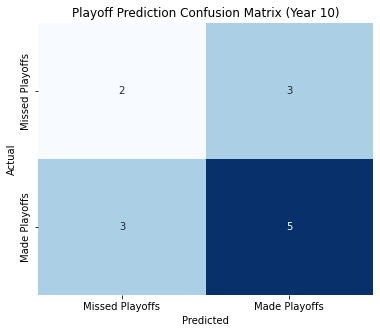

In [18]:
# Create Binary Columns for Playoffs (Top 4 = Yes, >4 = No)
final_results_df['Actual_Playoff'] = final_results_df['actual_rank'] <= 4
final_results_df['Predicted_Playoff'] = final_results_df['predicted_rank_model'] <= 4

# Generate Confusion Matrix
cm = confusion_matrix(final_results_df['Actual_Playoff'], final_results_df['Predicted_Playoff'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Missed Playoffs', 'Made Playoffs'],
            yticklabels=['Missed Playoffs', 'Made Playoffs'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Playoff Prediction Confusion Matrix (Year 10)')
plt.show()



=== Built-in feature importances (final model) ===
                feature  importance
  net_rating_avg3yr_lag    0.177157
           reb_dif_lag1    0.080022
     win_pct_avg3yr_lag    0.066900
        net_rating_lag1    0.059904
away_win_pct_avg3yr_lag    0.037880
        eff_x_pace_lag1    0.037809
           def_eff_lag1    0.037228
     def_eff_avg3yr_lag    0.036552
pts_per_poss_avg3yr_lag    0.033432
      away_win_pct_lag1    0.032395
     ast_dif_avg3yr_lag    0.031932
     blk_dif_avg3yr_lag    0.028424
           blk_dif_lag1    0.027889
  eff_x_pace_avg3yr_lag    0.022253
   pyth_wins_avg3yr_lag    0.021266


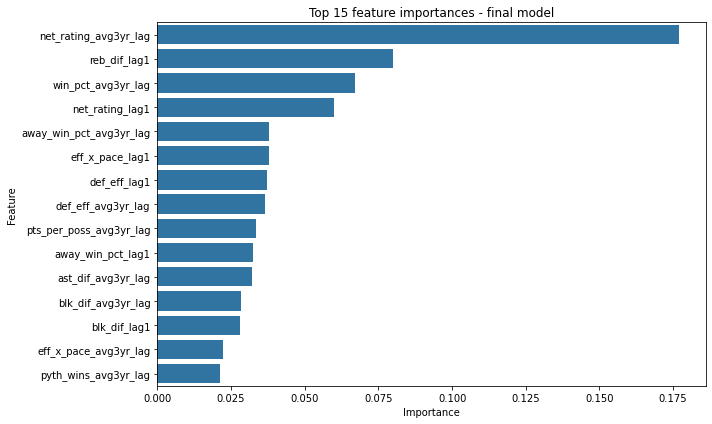

In [19]:
# === Feature importance for final model ===
from sklearn.inspection import permutation_importance

X_test = test_df[best_features]
y_test = test_df[target_col]

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = X_test.columns

    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print("\n=== Built-in feature importances (final model) ===")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="importance",
        y="feature",
        data=fi_df.head(15),
        orient="h"
    )
    plt.title("Top 15 feature importances - final model")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    result = permutation_importance(
        final_model,
        X_test,
        y_test,
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
        scoring="neg_mean_absolute_error"
    )

    feature_names = X_test.columns
    perm_df = pd.DataFrame({
        "feature": feature_names,
        "importance": result.importances_mean
    }).sort_values("importance", ascending=False)

    print("\n=== Permutation feature importances (final model) ===")
    print(perm_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="importance",
        y="feature",
        data=perm_df.head(15),
        orient="h"
    )
    plt.title("Top 15 permutation importances - final model")
    plt.xlabel("Importance (MAE drop when shuffled)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()



=== White-box Ridge model (interpretation only) ===
Test MAE: 2.1971
Test Spearman: -0.0055

Top 15 coefficients by absolute value:
efg_pct_lag1             1.265860
pts_per_poss_lag1       -1.115170
rank_avg3yr_lag          1.096888
rank_lag1               -0.961577
efg_pct_avg3yr_lag      -0.951213
net_rating_avg3yr_lag    0.940926
off_eff_avg3yr_lag       0.756818
pyth_wins_lag1          -0.739599
def_eff_lag1            -0.725791
net_four_factors_lag1    0.680120
pf_dif_lag1              0.597519
ast_dif_avg3yr_lag      -0.582378
win_pct_lag1            -0.565246
home_win_pct_lag1       -0.556863
def_eff_avg3yr_lag       0.536977
dtype: float64


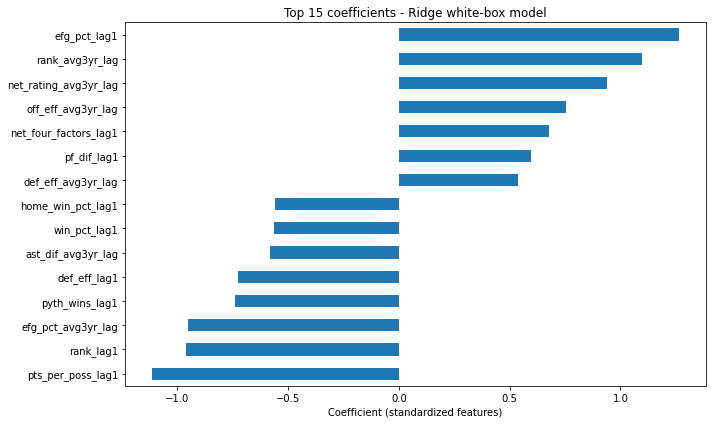

In [20]:
# === White-box Ridge model for interpretation ===
from sklearn.linear_model import Ridge

X_train_full = pd.concat([train_df[best_features], val_df[best_features]])
y_train_full = pd.concat([y_train, y_val])

scaler_wb = StandardScaler()
X_train_full_scaled = scaler_wb.fit_transform(X_train_full)
X_test_scaled = scaler_wb.transform(X_test)

ridge_wb = Ridge(alpha=1.0)
ridge_wb.fit(X_train_full_scaled, y_train_full)

y_pred_ridge = ridge_wb.predict(X_test_scaled)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
spearman_ridge, _ = spearmanr(y_test, y_pred_ridge)

print("\n=== White-box Ridge model (interpretation only) ===")
print(f"Test MAE: {mae_ridge:.4f}")
print(f"Test Spearman: {spearman_ridge:.4f}")

coef_series = pd.Series(
    ridge_wb.coef_,
    index=X_train_full.columns
).sort_values(key=abs, ascending=False)

print("\nTop 15 coefficients by absolute value:")
print(coef_series.head(15))

plt.figure(figsize=(10, 6))
coef_series.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 coefficients - Ridge white-box model")
plt.xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()


In [84]:
from collections import defaultdict, Counter
from sklearn.model_selection import KFold

# Rolling splits: train 2->val3, 2-3->4, ..., 2-8->9

model_configs = {
    "Random Forest (no scaler)": {
        "model": Pipeline([
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ['sqrt', 'log2', None]
        }
    },
    "Random Forest (scaled)": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ['sqrt', 'log2', None]
        }
    },

    "Gradient Boosting": {
        "model": Pipeline([
            ("model", GradientBoostingRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 300, 500, 1000],
            "model__learning_rate": [0.005, 0.01, 0.05, 0.1],
            "model__max_depth": [3, 4, 5],
            "model__subsample": [0.7, 0.8, 0.9, 1.0]
        }
    },

    "Ridge Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        "params": {
            "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
        }
    },

    "SVR": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR())
        ]),
        "params": {
            "model__C": [0.1, 1, 10, 100, 1000],
            "model__kernel": ['linear', 'rbf', 'poly'],
            "model__epsilon": [0.01, 0.1, 0.2, 0.5],
            "model__gamma": ['scale', 'auto', 0.1, 0.01]
        }
    },

    "AdaBoost": {
        "model": Pipeline([
            ("model", AdaBoostRegressor(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [50, 100, 300, 500],
            "model__learning_rate": [0.001, 0.01, 0.1, 1.0],
            "model__loss": ['linear', 'square', 'exponential']
        }
    },

    "Linear Regression": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "params": {
            "model__fit_intercept": [True, False]
        }
    }
}

years = sorted(model_df["year"].unique())
min_year = 2
max_val_year = 9

splits = []
for val_year in range(3, max_val_year + 1):
    train_years = list(range(min_year, val_year))
    splits.append((train_years, val_year))

print("\nRolling splits (train_years -> val_year):")
for tr, v in splits:
    print(tr, "->", v)

history = defaultdict(list)

for split_idx, (train_years, val_year) in enumerate(splits, start=1):
    print(f"\n=== Rolling Split {split_idx}: Train years {train_years} | Val year {val_year} ===")

    train_mask = model_df["year"].isin(train_years)
    val_mask   = model_df["year"] == val_year

    X_train_rs = model_df.loc[train_mask, best_features]
    y_train_rs = model_df.loc[train_mask, target_col]

    X_val_rs   = model_df.loc[val_mask, best_features]
    y_val_rs   = model_df.loc[val_mask, target_col]

    print(f"  Train size: {len(X_train_rs)} | Val size: {len(X_val_rs)}")

    if len(X_val_rs) == 0:
        print("  Skipping split (empty validation).")
        continue

    if len(X_train_rs) < 3:
        print("  Skipping split (not enough samples for 3-fold CV).")
        continue

    cv_rs = KFold(n_splits=3, shuffle=True, random_state=42)

    for name, config in model_configs.items():
        print(f"  > Tuning {name}...")

        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=cv_rs,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train_rs, y_train_rs)

        best_estimator = grid.best_estimator_
        best_params    = grid.best_params_

        y_pred_val = best_estimator.predict(X_val_rs)
        val_mae    = mean_absolute_error(y_val_rs, y_pred_val)

        print(f"    Split {split_idx} | Val year {val_year} | MAE={val_mae:.3f}")

        history[name].append({
            "split": split_idx,
            "val_year": val_year,
            "best_params": best_params,
            "val_mae": val_mae
        })



Rolling splits (train_years -> val_year):
[2] -> 3
[2, 3] -> 4
[2, 3, 4] -> 5
[2, 3, 4, 5] -> 6
[2, 3, 4, 5, 6] -> 7
[2, 3, 4, 5, 6, 7] -> 8
[2, 3, 4, 5, 6, 7, 8] -> 9

=== Rolling Split 1: Train years [2] | Val year 3 ===
  Train size: 16 | Val size: 16
  > Tuning Random Forest (no scaler)...
    Split 1 | Val year 3 | MAE=1.980
  > Tuning Random Forest (scaled)...
    Split 1 | Val year 3 | MAE=1.995
  > Tuning Gradient Boosting...
    Split 1 | Val year 3 | MAE=2.013
  > Tuning Ridge Regression...
    Split 1 | Val year 3 | MAE=2.002
  > Tuning SVR...
    Split 1 | Val year 3 | MAE=1.950
  > Tuning AdaBoost...
    Split 1 | Val year 3 | MAE=1.781
  > Tuning Linear Regression...
    Split 1 | Val year 3 | MAE=2.768

=== Rolling Split 2: Train years [2, 3] | Val year 4 ===
  Train size: 32 | Val size: 12
  > Tuning Random Forest (no scaler)...
    Split 2 | Val year 4 | MAE=1.672
  > Tuning Random Forest (scaled)...
    Split 2 | Val year 4 | MAE=1.670
  > Tuning Gradient Boosting...

In [85]:
selected_configs = {}

for name, records in history.items():
    if not records:
        continue

    df_h = pd.DataFrame(records)
    df_h["params_str"] = df_h["best_params"].astype(str)

    freq = Counter(df_h["params_str"])
    mean_mae_by_params = df_h.groupby("params_str")["val_mae"].mean()

    best_params_str = None
    best_tuple = (-1, float("inf"))  # (wins, -mean_mae) encoded via tuple trick

    for p_str, count in freq.items():
        mean_mae = mean_mae_by_params[p_str]
        # maximize count, minimize mean_mae -> use (count, -mean_mae)
        cand = (count, -mean_mae)
        if cand > best_tuple:
            best_tuple = cand
            best_params_str = p_str

    chosen_row = df_h[df_h["params_str"] == best_params_str].iloc[0]
    chosen_params = chosen_row["best_params"]

    selected_configs[name] = {
        "chosen_params": chosen_params,
        "wins": freq[best_params_str],
        "mean_mae": mean_mae_by_params[best_params_str]
    }

    print(f"\nModel {name}: chosen params used in {freq[best_params_str]} splits, "
          f"mean MAE={mean_mae_by_params[best_params_str]:.3f}")
    print(chosen_params)



Model Random Forest (no scaler): chosen params used in 2 splits, mean MAE=1.438
{'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Model Random Forest (scaled): chosen params used in 2 splits, mean MAE=1.437
{'model__max_depth': 5, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 300}

Model Gradient Boosting: chosen params used in 1 splits, mean MAE=0.974
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 1000, 'model__subsample': 0.7}

Model Ridge Regression: chosen params used in 5 splits, mean MAE=1.562
{'model__alpha': 100.0}

Model SVR: chosen params used in 1 splits, mean MAE=1.260
{'model__C': 1, 'model__epsilon': 0.5, 'model__gamma': 0.01, 'model__kernel': 'rbf'}

Model AdaBoost: chosen params used in 1 splits, mean MAE=0.977
{'model__learning_rate': 0.001, 'model__loss': 'linear', 'model__n_

In [87]:
from sklearn.base import clone

train_final_mask = model_df["year"] < 10
test_final_mask  = model_df["year"] == 10

X_train_final = model_df.loc[train_final_mask, best_features]
y_train_final = model_df.loc[train_final_mask, target_col]

X_test_final  = model_df.loc[test_final_mask, best_features]
y_test_final  = model_df.loc[test_final_mask, target_col]

rolling_final_results = []

for name, info in selected_configs.items():
    print(f"\n=== Final training for {name} with rolling-selected params (ranking) ===")

    base_pipeline = model_configs[name]["model"]
    estimator = clone(base_pipeline)
    estimator.set_params(**info["chosen_params"])

    estimator.fit(X_train_final, y_train_final)
    y_pred_test = estimator.predict(X_test_final)

    test_mae = mean_absolute_error(y_test_final, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_test))
    test_spearman, _ = spearmanr(y_test_final, y_pred_test)

    # Build ranking per conference for Year 10 (same pattern as your final_results_df)
    res_df = test_df[['tmID', 'confID', 'year', 'rank', 'rank_lag1']].copy()
    res_df.rename(columns={'rank': 'actual_rank', 'rank_lag1': 'baseline_rank'}, inplace=True)
    res_df['predicted_rank_raw'] = y_pred_test
    res_df['predicted_rank_model'] = (
        res_df.groupby('confID')['predicted_rank_raw']
              .rank(method='first', ascending=True)
              .astype(int)
    )

    rolling_final_results.append({
        "Model": name,
        "Validation MAE (rolling)": info["mean_mae"],
        "Test MAE (Year 10)": test_mae,
        "Test RMSE (Year 10)": test_rmse,
        "Test Spearman": test_spearman,
        "Results_Test": res_df
    })

rolling_comp_df = pd.DataFrame(rolling_final_results).sort_values(
    by="Test MAE (Year 10)", ascending=True
)

print("\n--- Rolling-Window Models: Validation vs Test Performance ---")
print(rolling_comp_df[[
    "Model",
    "Validation MAE (rolling)",
    "Test MAE (Year 10)",
    "Test RMSE (Year 10)",
    "Test Spearman"
]].to_string(index=False))

# Pick best rolling model on Year 10
best_row_rw = rolling_comp_df.iloc[0]
best_model_name_rw = best_row_rw["Model"]
best_results_test_rw = best_row_rw["Results_Test"]

print(f"\nBest rolling-window model on Test (Year 10): {best_model_name_rw}")
print("\n--- Final Predicted vs. Actual Rankings (Year 10) – Rolling Model ---")
print(best_results_test_rw[[
    'confID', 'tmID', 'actual_rank', 'baseline_rank', 'predicted_rank_model'
]].sort_values(['confID', 'actual_rank']).to_string(index=False))



=== Final training for Random Forest (no scaler) with rolling-selected params (ranking) ===

=== Final training for Random Forest (scaled) with rolling-selected params (ranking) ===

=== Final training for Gradient Boosting with rolling-selected params (ranking) ===

=== Final training for Ridge Regression with rolling-selected params (ranking) ===

=== Final training for SVR with rolling-selected params (ranking) ===

=== Final training for AdaBoost with rolling-selected params (ranking) ===

=== Final training for Linear Regression with rolling-selected params (ranking) ===

--- Rolling-Window Models: Validation vs Test Performance ---
                    Model  Validation MAE (rolling)  Test MAE (Year 10)  Test RMSE (Year 10)  Test Spearman
                 AdaBoost                  0.976533            1.544050             2.000845       0.144248
Random Forest (no scaler)                  1.437806            1.622920             2.041722       0.127428
   Random Forest (scaled)    

### Coach Changes Problem (Second Problem)

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC

# Metrics (Classification)
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

file_path = '../dataset_for_modeling/features_for_coach_changes.csv'
coach_data = pd.read_csv(file_path)

performance_columns = [
    'win_pct_vs_league',
    'playoff_win_pct',
    'eff_diff',
    'def_four_factors',
    'career_win_pct'
]

coach_data = coach_data.sort_values(by=['tmID', 'year'])

lag1_feature_names = [f"{col}_lag1" for col in performance_columns]
coach_data[lag1_feature_names] = coach_data.groupby('tmID')[performance_columns].shift(1)

def weighted_avg(series):
    weights = np.array([0.2, 0.3, 0.5]) # Weights: 0.5 (Last Year), 0.3 (Year-2), 0.2 (Year-3)
    s = np.array(series)
    mask = ~np.isnan(s)
    if not np.any(mask): return np.nan
    w = weights[-len(s):]
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

avg3yr_feature_names = [f"{col}_avg3yr_lag" for col in performance_columns]

rolling_avg = coach_data.groupby('tmID')[[f"{col}_lag1" for col in performance_columns]] \
                        .rolling(window=3, min_periods=1) \
                        .apply(weighted_avg, raw=True)

coach_data[avg3yr_feature_names] = rolling_avg.reset_index(level=0, drop=True)

# Clean Data (Drop rows missing Lag-1 history)
model_df = coach_data.dropna(subset=lag1_feature_names).copy()
print(f"Original shape: {coach_data.shape}, Model-ready shape: {model_df.shape}")

# Target Variable (0 = No Change, 1 = Change)
target_col = 'coach_changed'


Original shape: (142, 20), Model-ready shape: (122, 20)


#### Select Best Feature Set

In [9]:
features_lag1 = performance_columns + lag1_feature_names

features_trend = performance_columns + avg3yr_feature_names

feature_sets = {
    "Current Stats Only": performance_columns,
    "Current + Lag1": features_lag1,
    "Current + 3Yr Trend": features_trend
}

TEST_YEAR = 10
VALIDATION_YEAR = 9

train_df = model_df[model_df['year'] < VALIDATION_YEAR]
val_df   = model_df[model_df['year'] == VALIDATION_YEAR]
test_df  = model_df[model_df['year'] == TEST_YEAR]

y_train = train_df[target_col]
y_val   = val_df[target_col]
y_test  = test_df[target_col]

print(f"\nTraining: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

# Baseline: "Majority Class" (Usually 'No Change')
y_pred_baseline = np.zeros(len(y_val)) # Predict 0 for everyone since coach changes happen less than coaches staying
f1_baseline = f1_score(y_val, y_pred_baseline, zero_division=0)
print(f"Baseline F1 Score (Predict 'No Change'): {f1_baseline:.4f}")

# Quick Model Check
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVC': SVC(class_weight='balanced'),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

results = []

for fs_name, fs_cols in feature_sets.items():
    print(f"\n--- Testing Feature Set: {fs_name} ---")
    
    X_train = train_df[fs_cols]
    X_val = val_df[fs_cols]
    
    # Scale Data
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)
    
    for name, model in models.items():
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_val_s)
        
        # Metrics
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_pred)
        
        print(f"  {name}: F1={f1:.4f} (AUC={auc:.4f})")
        results.append((fs_name, name, f1, auc))

# Select Best Feature Set
best_f1_result = max(results, key=lambda item: item[2]) 
best_f1_fs, best_f1_model, best_f1_score, _ = best_f1_result

# 2. Best based on AUC Score (Index 3)
best_auc_result = max(results, key=lambda item: item[3]) 
best_auc_fs, best_auc_model, _, best_auc_score = best_auc_result

print(f"\n--- Validation Best Metrics ---")
print(f"Best F1 Score:  {best_f1_score:.4f}")
print(f"  - Feature Set: {best_f1_fs}")

print(f"\nBest AUC Score: {best_auc_score:.4f}")
print(f"  - Feature Set: {best_auc_fs}")

# Optional: Decide which one to use for the next steps
# If your goal is ranking (finding risky coaches), prioritizing AUC is often better.
best_fs_name = best_auc_fs if best_auc_score > 0.5 else best_f1_fs



Training: 96 | Validation: 13 | Test: 13
Baseline F1 Score (Predict 'No Change'): 0.0000

--- Testing Feature Set: Current Stats Only ---
  Logistic Regression: F1=0.6667 (AUC=0.6905)
  Random Forest: F1=0.5000 (AUC=0.6667)
  Gradient Boosting: F1=0.4444 (AUC=0.5952)
  SVC: F1=0.5455 (AUC=0.6071)
  AdaBoost: F1=0.7273 (AUC=0.7619)

--- Testing Feature Set: Current + Lag1 ---
  Logistic Regression: F1=0.6154 (AUC=0.6190)
  Random Forest: F1=0.5000 (AUC=0.6667)
  Gradient Boosting: F1=0.6000 (AUC=0.6786)
  SVC: F1=0.6667 (AUC=0.6905)
  AdaBoost: F1=0.6000 (AUC=0.6786)

--- Testing Feature Set: Current + 3Yr Trend ---
  Logistic Regression: F1=0.6154 (AUC=0.6190)
  Random Forest: F1=0.5000 (AUC=0.6667)
  Gradient Boosting: F1=0.4444 (AUC=0.5952)
  SVC: F1=0.6000 (AUC=0.6786)
  AdaBoost: F1=0.3636 (AUC=0.4524)

--- Validation Best Metrics ---
Best F1 Score:  0.7273
  - Feature Set: Current Stats Only

Best AUC Score: 0.7619
  - Feature Set: Current Stats Only


#### Rolling Window Performance Test

In [10]:
best_features = feature_sets[best_fs_name]
X_train_full = pd.concat([train_df[best_features], val_df[best_features]])
y_train_full = pd.concat([y_train, y_val])

model_configs = {
    "Logistic Regression": {
        "model": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(class_weight='balanced'))]),
        "params": {"model__C": [0.01, 0.1, 1, 10]}
    },
    "Random Forest": {
        "model": Pipeline([("model", RandomForestClassifier(random_state=42, class_weight='balanced'))]),
        "params": {"model__n_estimators": [100, 200], "model__max_depth": [3, 5, 10]}
    },
    "Gradient Boosting": {
        "model": Pipeline([("model", GradientBoostingClassifier(random_state=42))]),
        "params": {"model__learning_rate": [0.01, 0.1], "model__max_depth": [3, 5]}
    },
    "SVC": {
        "model": Pipeline([("scaler", StandardScaler()), ("model", SVC(class_weight='balanced', probability=True))]),
        "params": {"model__C": [0.1, 1], "model__kernel": ['rbf']}
    },
    "AdaBoost": {
        "model": Pipeline([("model", AdaBoostClassifier(random_state=42))]),
        "params": {"model__n_estimators": [50, 100], "model__learning_rate": [0.01, 0.1]}
    }
}

print("\n--- Running Rolling Window Validation (Years 3-10) ---")

model_metrics = {name: {'f1': [], 'auc': []} for name in model_configs.keys()}
best_params_history = {name: [] for name in model_configs.keys()}

min_year = 3
max_year = 9 

for val_year in range(min_year, max_year + 1):
    print(f"\n=== Rolling Split: Val Year {val_year} ===")
    
    # Split
    train_split = model_df[model_df['year'] < val_year]
    val_split   = model_df[model_df['year'] == val_year]
    
    if len(val_split) == 0: continue
    
    X_tr = train_split[best_features]
    y_tr = train_split[target_col]
    X_vl = val_split[best_features]
    y_vl = val_split[target_col]
    
    # Check class balance
    if y_vl.nunique() < 2:
        print(f"  Skipping Year {val_year} (Single class in validation).")
        continue

    # Tune & Evaluate each model
    for name, config in model_configs.items():
        # Inner Grid Search for Tuning on this specific split
        grid = GridSearchCV(
            config["model"], config["params"], 
            cv=3, scoring='f1', n_jobs=-1
        )
        grid.fit(X_tr, y_tr)
        
        # Best Estimator for this split
        best_model = grid.best_estimator_
        best_params_history[name].append(grid.best_params_)
        
        # Predict
        y_pred = best_model.predict(X_vl)
        
        if hasattr(best_model, "predict_proba"):
            y_prob = best_model.predict_proba(X_vl)[:, 1]
        else:
            y_prob = best_model.decision_function(X_vl)
            
        # Metrics
        val_f1 = f1_score(y_vl, y_pred, zero_division=0)
        try:
            val_auc = roc_auc_score(y_vl, y_prob)
        except:
            val_auc = 0.5
            
        model_metrics[name]['f1'].append(val_f1)
        model_metrics[name]['auc'].append(val_auc)
        
        print(f"  {name}: F1={val_f1:.3f} | AUC={val_auc:.3f}")

# --- Summary ---
print("\n=== Rolling Validation Summary ===")
summary_data = []
for name, metrics in model_metrics.items():
    if metrics['f1']:
        summary_data.append({
            'Model': name, 
            'Avg Rolling F1': np.mean(metrics['f1']), 
            'Avg Rolling AUC': np.mean(metrics['auc'])
        })

summary_df = pd.DataFrame(summary_data).sort_values(by='Avg Rolling AUC', ascending=False)
print(summary_df.to_string(index=False))

best_model_name = summary_df.iloc[0]['Model']
print(f"\nBest Model: {best_model_name}")



--- Running Rolling Window Validation (Years 3-10) ---

=== Rolling Split: Val Year 3 ===
  Logistic Regression: F1=0.737 | AUC=0.746
  Random Forest: F1=0.571 | AUC=0.762
  Gradient Boosting: F1=0.714 | AUC=0.794
  SVC: F1=0.737 | AUC=0.667
  AdaBoost: F1=0.625 | AUC=0.794

=== Rolling Split: Val Year 4 ===
  Logistic Regression: F1=0.667 | AUC=0.806
  Random Forest: F1=0.667 | AUC=0.708
  Gradient Boosting: F1=0.615 | AUC=0.639
  SVC: F1=0.667 | AUC=0.583
  AdaBoost: F1=0.667 | AUC=0.792

=== Rolling Split: Val Year 5 ===
  Logistic Regression: F1=0.600 | AUC=0.722
  Random Forest: F1=0.667 | AUC=0.806
  Gradient Boosting: F1=0.667 | AUC=0.667
  SVC: F1=0.600 | AUC=0.639
  AdaBoost: F1=0.500 | AUC=0.694

=== Rolling Split: Val Year 6 ===
  Logistic Regression: F1=0.444 | AUC=0.682
  Random Forest: F1=0.333 | AUC=0.636
  Gradient Boosting: F1=0.667 | AUC=0.818
  SVC: F1=0.500 | AUC=0.682
  AdaBoost: F1=0.000 | AUC=0.455

=== Rolling Split: Val Year 7 ===
  Logistic Regression: F1=0.5

#### Insert New Test Set for Year 11

In [12]:
df_year_11 = pd.read_csv('../Season_11/coaches.csv')

df_year_11 = df_year_11[['tmID', 'coachID', 'year']]

full_coach_history = pd.concat([coach_data, df_year_11], ignore_index=True)
full_coach_history = full_coach_history.sort_values(by=['tmID', 'year'])

full_coach_history['next_coach'] = full_coach_history.groupby('tmID')['coachID'].shift(-1)

full_coach_history['coach_changed'] = np.where(
    full_coach_history['next_coach'].isna(), 
    0, # No info for next year (e.g., Year 11 itself) -> assume 0 or drop
    (full_coach_history['coachID'] != full_coach_history['next_coach']).astype(int)
)

target_update_map = full_coach_history.set_index(['tmID', 'year', 'coachID'])['coach_changed']
model_df['coach_changed'] = model_df.set_index(['tmID', 'year', 'coachID']).index.map(target_update_map)

print(f"Updated Year 10 Targets. Total Changes in Year 10: {model_df[model_df['year']==10]['coach_changed'].sum()}")

changed_coaches_df = model_df[(model_df['year'] == 10) & (model_df['coach_changed'] == 1)]

print("\n>>> List of Coaches who changed teams after Year 10:")
for index, row in changed_coaches_df.iterrows():
    print(f"Team: {row['tmID']} | Coach: {row['coachID']}")

# Check for teams in Year 10 that don't exist in Year 11
teams_year_10 = set(model_df[model_df['year'] == 10]['tmID'])
teams_year_11 = set(df_year_11['tmID'])

disappearing_teams = teams_year_10 - teams_year_11
print(f"Teams in Year 10 but not Year 11: {disappearing_teams}")
print("SAC because of dispersal/dissolution and DET because of re-franchise to TUL. Thus, should be treated as coach change!")

if 'DET' in disappearing_teams:
    print("Correcting Detroit Shock (DET) coach_changed = 1")
    # Force DET Year 10 to be a 'Change' (1) because the coach was replaced in the move to Tulsa
    model_df.loc[(model_df['year'] == 10) & (model_df['tmID'] == 'DET'), 'coach_changed'] = 1
    

Updated Year 10 Targets. Total Changes in Year 10: 5

>>> List of Coaches who changed teams after Year 10:
Team: CHI | Coach: keyst99wc
Team: LAS | Coach: coopemi01w
Team: MIN | Coach: gilloje01w
Team: NYL | Coach: donovan99w
Team: WAS | Coach: plankju99w
Teams in Year 10 but not Year 11: {'SAC', 'DET'}
SAC because of dispersal/dissolution and DET because of re-franchise to TUL. Thus, should be treated as coach change!
Correcting Detroit Shock (DET) coach_changed = 1


#### Final Test Year 11

In [13]:
print(f"\n--- Final Test (Year 11) ---")

# Get most common best params for the winner
from collections import Counter
param_strings = [str(p) for p in best_params_history[best_model_name]]
most_common_params_str = Counter(param_strings).most_common(1)[0][0]
# Convert string back to dict (safe eval or manual check, here we just re-run grid on full data)

# Final Retrain on Years 2-9
X_full_train = model_df[model_df['year'] < 10][best_features]
y_full_train = model_df[model_df['year'] < 10][target_col]
X_test = model_df[model_df['year'] == 10][best_features]
y_test = model_df[model_df['year'] == 10][target_col]

# Retune on full train set to be safe
final_grid = GridSearchCV(
    model_configs[best_model_name]["model"], 
    model_configs[best_model_name]["params"], 
    cv=5, scoring='roc_auc', n_jobs=-1
)
final_grid.fit(X_full_train, y_full_train)
final_model = final_grid.best_estimator_

# Predict
y_prob_test = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
y_pred_test = (y_prob_test > 0.5).astype(int)

test_results = model_df[model_df['year'] == 10].copy()
test_results['prob_fire'] = y_prob_test
test_results['predicted_change'] = y_pred_test # Use the clean binary integer prediction

print("\n>>> Coaches Most Likely to be Fired (Year 11):")
print(test_results.sort_values('prob_fire', ascending=False)[['tmID', 'coachID', 'prob_fire', 'predicted_change', 'coach_changed']])

precision = precision_score(y_test, y_pred_test, pos_label=1, zero_division=0)
recall = recall_score(y_test, y_pred_test, pos_label=1, zero_division=0)
f1 = f1_score(y_test, y_pred_test, pos_label=1, zero_division=0)

# Print clean, summarized result
print("\n--- Final Classification Metrics (Year 11) ---")
print(f"Test F1 Score (Class 1):   {f1:.4f}")
print(f"Test Precision (Class 1):  {precision:.4f}")
print(f"Test Recall (Class 1):     {recall:.4f}")
print(f"Test Year 11 AUC:          {test_auc:.4f}")



--- Final Test (Year 11) ---

>>> Coaches Most Likely to be Fired (Year 11):
    tmID     coachID  prob_fire  predicted_change  coach_changed
75   MIN  gilloje01w   0.583073                 1              1
12   CHI   keyst99wc   0.571006                 1              1
111  SAC  whisejo99w   0.556088                 1              0
118  SAS  hugheda99w   0.537282                 1              0
1    ATL  meadoma99w   0.531507                 1              0
85   NYL  donovan99w   0.531237                 1              1
23   CON  thibami99w   0.522841                 1              0
141  WAS  plankju99w   0.520682                 1              1
33   DET  mahorri01w   0.468051                 0              1
128  SEA  aglerbr99w   0.462456                 0              0
98   PHO  gaineco01w   0.456504                 0              0
52   IND  dunnli99wc   0.455177                 0              0
62   LAS  coopemi01w   0.445687                 0              1

--- Final C

#### Visualizations

/tmp/ipykernel_12646/939185947.py:36: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_prob_test[y_test == 0], shade=True, color='green', label='Actual: Kept (0)', ax=ax2)
/tmp/ipykernel_12646/939185947.py:37: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(y_prob_test[y_test == 1], shade=True, color='red', label='Actual: Fired (1)', ax=ax2)


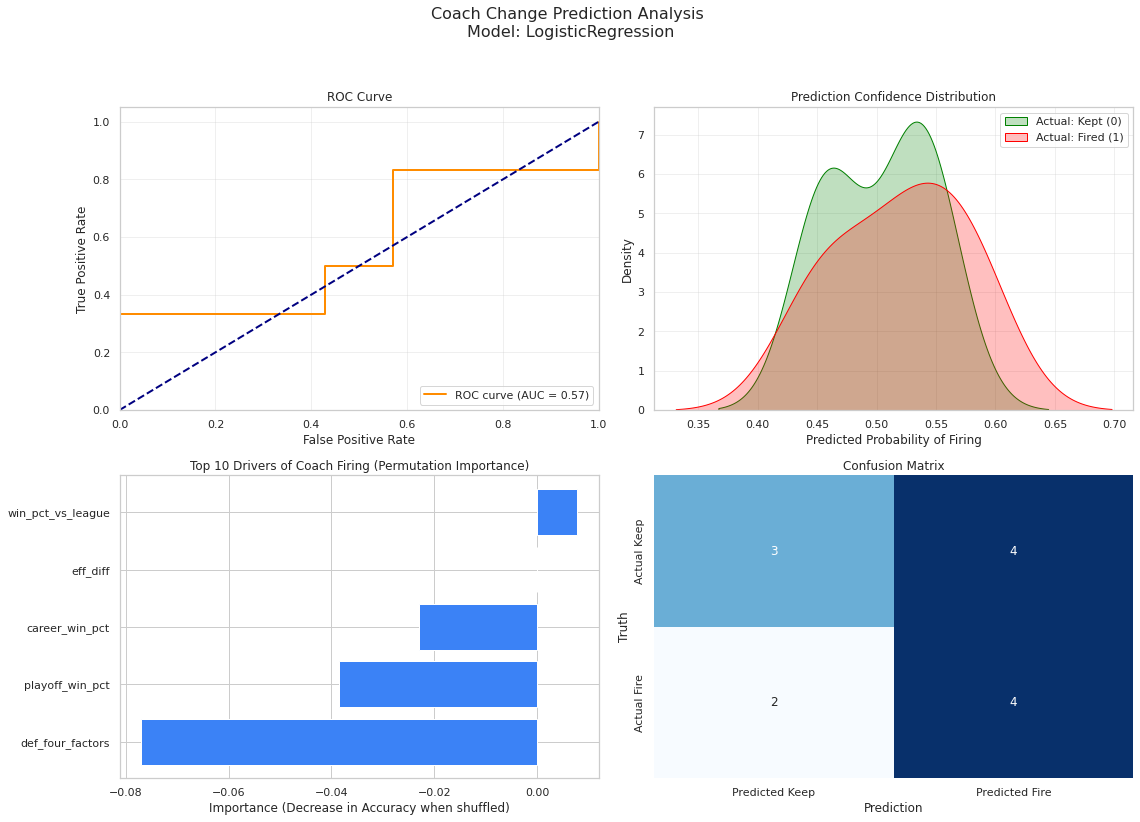

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
from sklearn.inspection import permutation_importance

# Set plot style
sns.set(style="whitegrid")

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Coach Change Prediction Analysis \nModel: {type(final_model.named_steps["model"]).__name__}', fontsize=16)

# Plot 1: ROC Curve & Precision-Recall Curve

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_test)

ax1 = axes[0, 0]
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Plot 2: Prediction Probability Density 

ax2 = axes[0, 1]
sns.kdeplot(y_prob_test[y_test == 0], shade=True, color='green', label='Actual: Kept (0)', ax=ax2)
sns.kdeplot(y_prob_test[y_test == 1], shade=True, color='red', label='Actual: Fired (1)', ax=ax2)
ax2.set_title('Prediction Confidence Distribution')
ax2.set_xlabel('Predicted Probability of Firing')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Feature Importance 

ax3 = axes[1, 0]

result = permutation_importance(final_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_sorted_idx = result.importances_mean.argsort()[-10:]

ax3.barh(range(len(perm_sorted_idx)), result.importances_mean[perm_sorted_idx], color='#3b82f6')
ax3.set_yticks(range(len(perm_sorted_idx)))
ax3.set_yticklabels(X_test.columns[perm_sorted_idx])
ax3.set_title('Top 10 Drivers of Coach Firing (Permutation Importance)')
ax3.set_xlabel('Importance (Decrease in Accuracy when shuffled)')

# Plot 4: Confusion Matrix Heatmap

ax4 = axes[1, 1]

# Calculate binary predictions (Threshold 0.5)
y_pred_binary = (y_prob_test > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_binary)

# Plot Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Keep', 'Predicted Fire'],
            yticklabels=['Actual Keep', 'Actual Fire'],
            ax=ax4)

ax4.set_title('Confusion Matrix')
ax4.set_ylabel('Truth')
ax4.set_xlabel('Prediction')

# Final Layout Adjustments
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### Player Awards Problem (Third Problem)

In [15]:
import pandas as pd

# Load the datasets
awards_df = pd.read_csv('../dataset_cleaned/awards_players.csv')
coaches_df = pd.read_csv('../dataset_cleaned/coaches.csv')
players_df = pd.read_csv('../dataset_cleaned/players.csv')

# Count unique awards
num_unique_awards = awards_df['award'].nunique()
unique_awards_list = awards_df['award'].unique()

# Count unique coaches (using coachID)
num_unique_coaches = coaches_df['coachID'].nunique()

# Count unique players (using bioID from the players table)
num_unique_players = players_df['bioID'].nunique()

print(f"Number of different awards: {num_unique_awards}")
for award in unique_awards_list:
    print(award)

print(f"Number of coaches: {num_unique_coaches}")
print(f"Number of players: {num_unique_players}")


Number of different awards: 11
All-Star Game Most Valuable Player
Coach of the Year
Defensive Player of the Year
Kim Perrot Sportsmanship Award
Most Improved Player
Most Valuable Player
Rookie of the Year
Sixth Woman of the Year
WNBA Finals Most Valuable Player
WNBA All-Decade Team
WNBA All Decade Team Honorable Mention
Number of coaches: 54
Number of players: 555


#### Most Improved Player Award

##### Data Analysis

/tmp/ipykernel_31890/2414548361.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='viridis')
/tmp/ipykernel_31890/2414548361.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
/tmp/ipykernel_31890/2414548361.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
/tmp/ipykernel_31890/2414548361.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated 

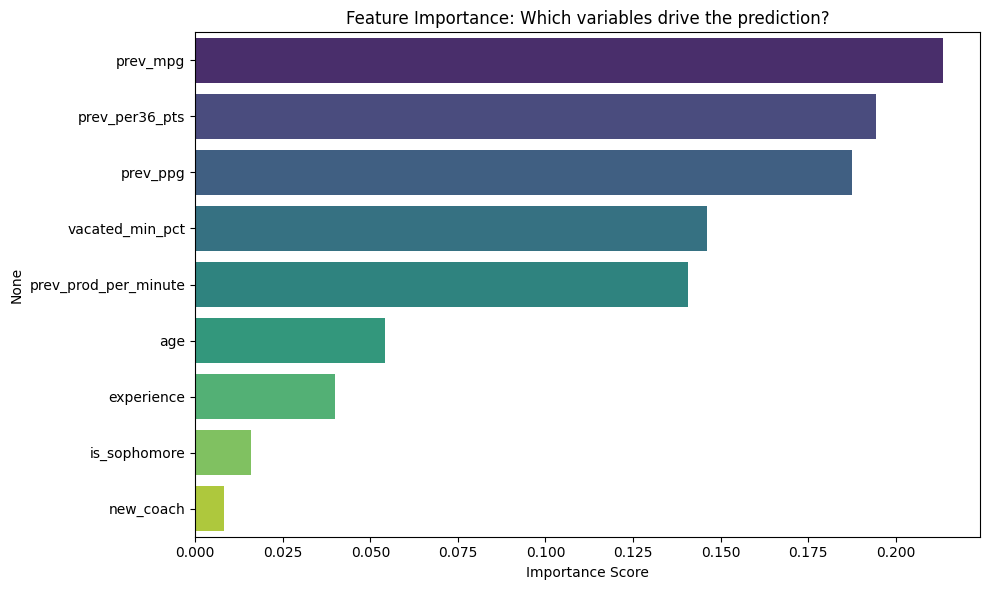

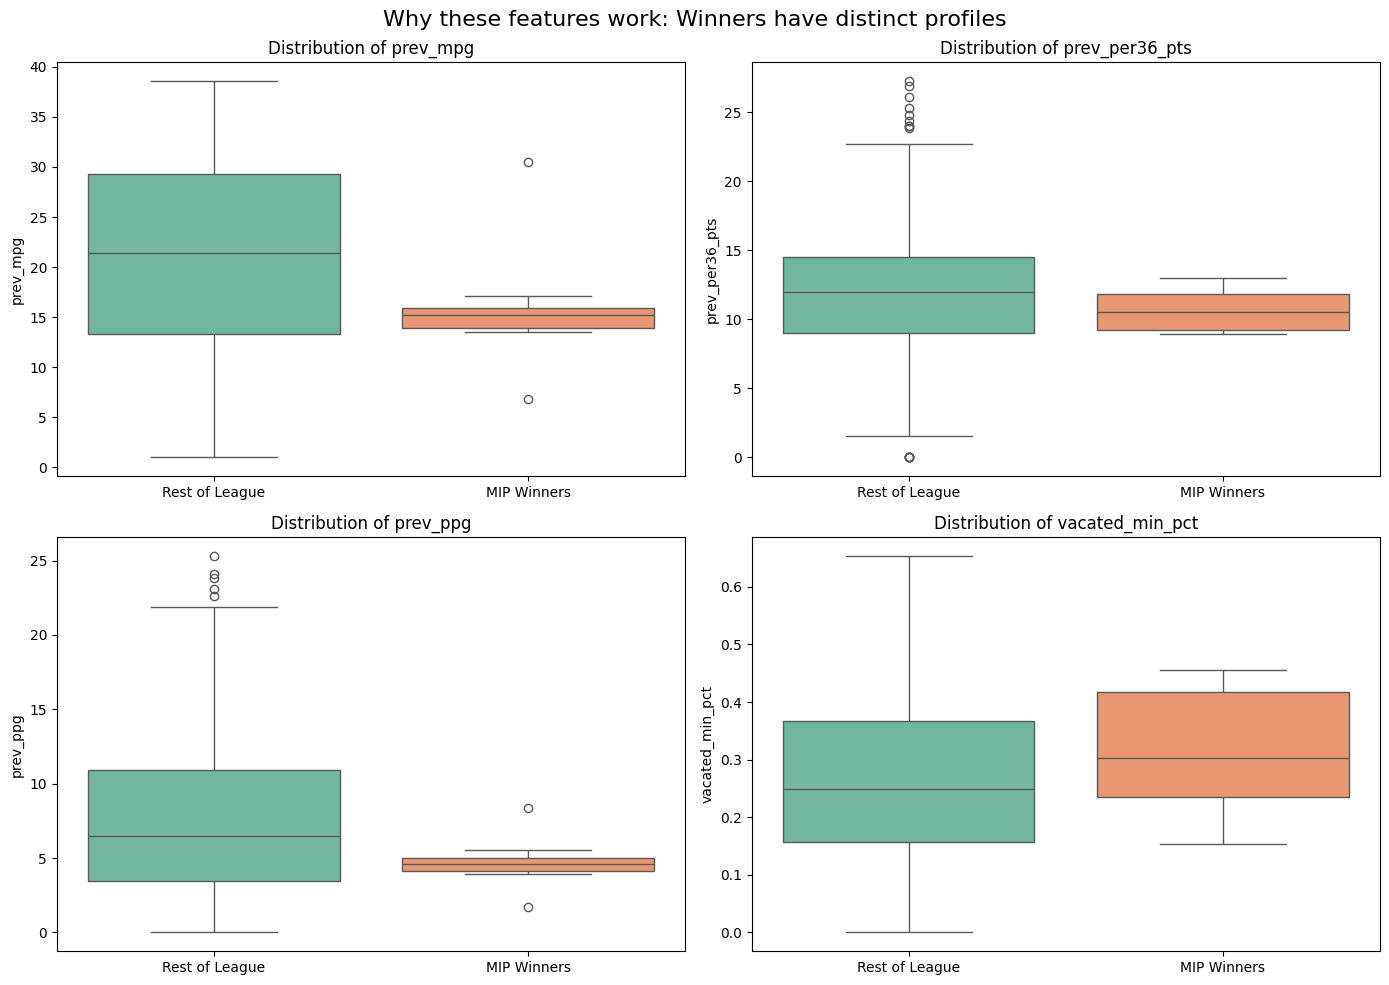

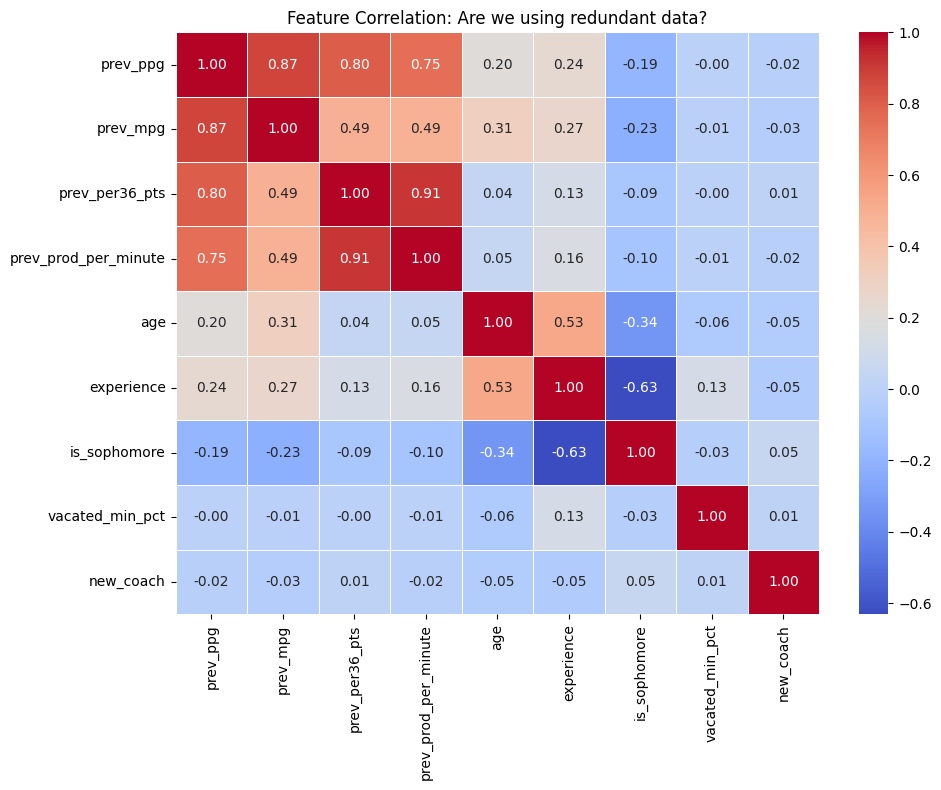

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

df_players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_awards = pd.read_csv('../dataset_cleaned/awards_players.csv')
df_players = pd.read_csv('../dataset_cleaned/players.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')

# --- Feature Engineering ---

# Demographics
df_players['birth_year'] = pd.to_datetime(df_players['birthDate'], errors='coerce').dt.year
df_players_teams = pd.merge(df_players_teams, df_players[['bioID', 'birth_year']], left_on='playerID', right_on='bioID', how='left')
df_players_teams.sort_values(['playerID', 'year'], inplace=True)
df_players_teams['experience'] = df_players_teams.groupby('playerID').cumcount()
df_players_teams['is_sophomore'] = (df_players_teams['experience'] == 1).astype(int)
df_players_teams['age'] = (1996 + df_players_teams['year']) - df_players_teams['birth_year']
df_players_teams['age'] = df_players_teams['age'].fillna(25)

# Team Context (Vacated Minutes)
rosters = df_players_teams.groupby(['year', 'tmID', 'playerID'])['minutes'].sum().reset_index()
vacated_list = []
years = sorted(df_players_teams['year'].unique())
teams = df_players_teams['tmID'].unique()

for yr in years:
    if yr == 1: continue
    prev = yr - 1
    for tm in teams:
        ros_prev = rosters[(rosters['year'] == prev) & (rosters['tmID'] == tm)]
        ros_curr = rosters[(rosters['year'] == yr) & (rosters['tmID'] == tm)]
        
        if ros_prev.empty: 
            vacated_list.append({'year': yr, 'tmID': tm, 'vacated_min_pct': 0})
            continue
        
        left = set(ros_prev['playerID']) - set(ros_curr['playerID'])
        vacated = ros_prev[ros_prev['playerID'].isin(left)]['minutes'].sum()
        total = ros_prev['minutes'].sum()
        ratio = vacated / total if total > 0 else 0
        vacated_list.append({'year': yr, 'tmID': tm, 'vacated_min_pct': ratio})

df_vacated = pd.DataFrame(vacated_list)

# Aggregation
stats = df_players_teams.groupby(['playerID', 'year']).agg({
    'GP': 'sum', 'minutes': 'sum', 'points': 'sum', 'rebounds': 'sum', 'assists': 'sum',
    'tmID': 'first', 'experience': 'first', 'is_sophomore': 'max', 'age': 'max'
}).reset_index()

# Basic & Advanced Stats
stats['ppg'] = stats['points'] / stats['GP']
stats['mpg'] = stats['minutes'] / stats['GP']
# Per 36 Minutes
stats['per36_pts'] = (stats['points'] / stats['minutes'].replace(0, 1)) * 36
# Production Per Minute
stats['prod_per_minute'] = (stats['points'] + stats['rebounds'] + stats['assists']) / stats['minutes'].replace(0, 1)

# Build Dataset (Lagged Features)
data_rows = []
for yr in years:
    if yr == 1: continue
    curr = stats[stats['year'] == yr][['playerID', 'year', 'tmID', 'age', 'experience', 'is_sophomore']].copy()
    prev = stats[stats['year'] == yr - 1].copy()
    prev.columns = [f'prev_{c}' if c != 'playerID' else 'playerID' for c in prev.columns]
    merged = pd.merge(curr, prev, on='playerID', how='inner')
    data_rows.append(merged)

df_final = pd.concat(data_rows, ignore_index=True)
df_final = pd.merge(df_final, df_vacated, on=['year', 'tmID'], how='left')

# Coaching Change
coaches = df_coaches[['year', 'tmID', 'coachID']].drop_duplicates(subset=['year', 'tmID'])
df_final = pd.merge(df_final, coaches, on=['year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'curr_coach'}, inplace=True)
coaches_prev = coaches.copy()
coaches_prev['next_year'] = coaches_prev['year'] + 1
df_final = pd.merge(df_final, coaches_prev[['next_year', 'tmID', 'coachID']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')
df_final.rename(columns={'coachID': 'prev_coach'}, inplace=True)
df_final['new_coach'] = (df_final['curr_coach'] != df_final['prev_coach']).astype(int)

# Target
mip_winners = df_awards[df_awards['award'] == 'Most Improved Player']
winners_map = mip_winners[['playerID', 'year']].copy()
winners_map['won'] = 1
df_final = pd.merge(df_final, winners_map, on=['playerID', 'year'], how='left')
df_final['won'] = df_final['won'].fillna(0).astype(int)

features = [
    'prev_ppg', 'prev_mpg', 
    'prev_per36_pts', 'prev_prod_per_minute',
    'age', 'experience', 'is_sophomore',     
    'vacated_min_pct', 'new_coach'
]
df_final[features] = df_final[features].fillna(0)

# 1. Feature Importance (Model Based)
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf.fit(df_final[features], df_final['won'])

plt.figure(figsize=(10, 6))
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index, palette='viridis')
plt.title('Feature Importance: Which variables drive the prediction?')
plt.xlabel('Importance Score')
plt.tight_layout()

# 2. Winners vs Non-Winners Distribution (Boxplots)
# Select top 4 features for detailed view
top_features = imp.index[:4].tolist()
df_plot = df_final.copy()
df_plot['Status'] = df_plot['won'].map({0: 'Rest of League', 1: 'MIP Winners'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel('')

plt.suptitle('Why these features work: Winners have distinct profiles', fontsize=16)
plt.tight_layout()

# 3. Correlation Heatmap (Redundancy Check)
plt.figure(figsize=(10, 8))
corr = df_final[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation: Are we using redundant data?')
plt.tight_layout()


##### Feature Engineering and Data Loading

In [36]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# --- 1. LOAD DATA ---
df_features = pd.read_csv('../dataset_for_modeling/most_improved_player_features.csv')
df_players = pd.read_csv('../dataset_cleaned/players.csv')
df_teams_roster = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')

# --- CORRECTION: RENAME COLUMN ---
# players.csv uses 'bioID', but we need 'playerID' to match other files
df_players = df_players.rename(columns={'bioID': 'playerID'})

# --- 2. FEATURE ENGINEERING ---

# A. Calculate AGE
# Use errors='coerce' to handle potential bad date formats
df_players['birth_year'] = pd.to_datetime(df_players['birthDate'], errors='coerce').dt.year

# Merge birth_year into features
df_features = pd.merge(df_features, df_players[['playerID', 'birth_year']], on='playerID', how='left')

# Calculate Age (Assuming Year 1 is 1997 or similar, adjusting relative to birth year)
# If your dataset's "Year 1" is 1997 (WNBA start), use 1996 + year.
# Based on common datasets, we approximate current year as (Base Year + Year Index).
# Let's assume Year 1 = 1997.
df_features['age'] = (1996 + df_features['year']) - df_features['birth_year']

# Fill missing ages with the median (to avoid crashing the model)
df_features['age'] = df_features['age'].fillna(df_features['age'].median())

# B. Calculate EXPERIENCE
# Sort by player and year to count how many seasons they've played before
df_features = df_features.sort_values(['playerID', 'year'])
df_features['experience'] = df_features.groupby('playerID').cumcount()
df_features['is_sophomore'] = (df_features['experience'] == 1).astype(int)
df_features['is_year_3_or_4'] = df_features['experience'].isin([2, 3]).astype(int)

# C. Calculate VACATED MINUTES (Team Level)
# We need to know what % of minutes from last year's team are available this year
# 1. Aggregate minutes per player/team/year from the roster file
roster = df_teams_roster.groupby(['year', 'tmID', 'playerID'])['minutes'].sum().reset_index()

# 2. Determine who left
def calc_vacated(df):
    vacated_data = []
    teams = df['tmID'].unique()
    years = sorted(df['year'].unique())
    
    for tm in teams:
        for y in years:
            if y == years[0]: continue
            
            # Players in prev year vs current year
            prev_roster = df[(df['tmID'] == tm) & (df['year'] == y-1)]
            curr_roster = df[(df['tmID'] == tm) & (df['year'] == y)]
            
            if prev_roster.empty: continue
            
            leavers = set(prev_roster['playerID']) - set(curr_roster['playerID'])
            
            total_mins_prev = prev_roster['minutes'].sum()
            vacated_mins = prev_roster[prev_roster['playerID'].isin(leavers)]['minutes'].sum()
            
            if total_mins_prev > 0:
                pct = vacated_mins / total_mins_prev
            else:
                pct = 0
            
            vacated_data.append({'year': y, 'tmID': tm, 'vacated_min_pct': pct})
            
    return pd.DataFrame(vacated_data)

df_vacated = calc_vacated(roster)
df_features = pd.merge(df_features, df_vacated, on=['year', 'tmID'], how='left')
df_features['vacated_min_pct'] = df_features['vacated_min_pct'].fillna(0)

# D. Calculate NEW COACH
# Check if the coachID for a team changed from Year T-1 to T
coach_map = df_coaches.sort_values('year').drop_duplicates(subset=['year', 'tmID'], keep='last')
coach_map['prev_coach'] = coach_map.groupby('tmID')['coachID'].shift(1)
coach_map['new_coach'] = (coach_map['coachID'] != coach_map['prev_coach']).astype(int)
# Fix Year 1 having NaN prev_coach
coach_map['new_coach'] = coach_map['new_coach'].fillna(0)

df_features = pd.merge(df_features, coach_map[['year', 'tmID', 'new_coach']], on=['year', 'tmID'], how='left')
df_features['new_coach'] = df_features['new_coach'].fillna(0)

# E. FORECASTING METRICS (The "Potential" Stats)
# We can only use PREV stats.
# Potential PPG = If they played 36 mins, how much would they score?
# We handle division by zero safely
df_features['prev_mpg_safe'] = df_features['prev_mpg'].replace(0, np.nan)
df_features['potential_ppg'] = (df_features['prev_ppg'] / df_features['prev_mpg_safe']) * 36
df_features['potential_ppg'] = df_features['potential_ppg'].fillna(0)

# Breakout Opportunity = Vacated Minutes * Potential
df_features['breakout_score'] = df_features['vacated_min_pct'] * df_features['potential_ppg']

# Previous Efficiency (Productivity per minute)
# Approximation using available prev stats: (Pts + Reb + Ast + Stl + Blk) / Minutes
df_features['prev_prod_per_minute'] = (
    df_features['prev_ppg'] + df_features['prev_rpg'] + df_features['prev_apg'] + 
    df_features['prev_spg'] + df_features['prev_bpg']
) / df_features['prev_mpg_safe']
df_features['prev_prod_per_minute'] = df_features['prev_prod_per_minute'].fillna(0)


##### Model Training and Evaluation

In [ ]:

features_to_use = [
    'prev_ppg', 'prev_mpg', 'prev_prod_per_minute', # Base Stats
    'potential_ppg', 'breakout_score',              # Forecasting Signals
    'age', 'experience', 'is_sophomore',            # Lifecycle
    'vacated_min_pct', 'new_coach'                  # Opportunity
]

target = 'won_mip'
WINDOW = 5
predictions = []

print(f"Starting Forecast (Window={WINDOW})...")

# User wants predictions for Year 5 to 10
# To predict Year 5 with Window 4, we train on [1, 2, 3, 4]
for test_year in range(5, 11):
    
    start_train = test_year - WINDOW
    
    # 1. Define Sets
    train = df_features[(df_features['year'] >= start_train) & (df_features['year'] < test_year)].copy()
    test = df_features[df_features['year'] == test_year].copy()
    
    # 2. Clean Data (Fill NaNs for safety)
    train[features_to_use] = train[features_to_use].fillna(0)
    test[features_to_use] = test[features_to_use].fillna(0)
    
    if train.empty or test.empty:
        print(f"Skipping Year {test_year} (Insufficient Data)")
        continue
        
    # 3. Train Model
    # Forecasting is noisy, so we restrict depth to prevent overfitting
    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        max_depth=6, 
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(train[features_to_use], train[target])
    
    # 4. Predict
    test['prob'] = rf.predict_proba(test[features_to_use])[:, 1]
    
    # 5. Store
    predictions.append(test[['playerID', 'year', 'prob', target] + features_to_use])

# --- 4. RESULTS & ANALYSIS ---

if predictions:
    df_preds = pd.concat(predictions, ignore_index=True)
    
    # Calculate Rank per year
    df_preds['rank'] = df_preds.groupby('year')['prob'].rank(ascending=False, method='first')
    
    # Performance Metrics
    print("\n" + "="*30)
    print("FORECASTING PERFORMANCE REPORT")
    print("="*30)
    
    try:
        auc = roc_auc_score(df_preds[target], df_preds['prob'])
        print(f"Overall ROC AUC: {auc:.4f}")
    except:
        print("Could not calculate AUC (Check if winners exist in test set)")
        
    # Show Winners and their Ranks
    winners = df_preds[df_preds[target] == 1]
    print("\n>>> Actual Winners & Model Prediction Ranks:")
    # We use 'prev_mpg' to show they had low minutes before winning
    print(winners[['year', 'playerID', 'rank', 'prob', 'potential_ppg', 'prev_mpg']].sort_values('year'))
    
    # Show Top 5 Predictions for every year requested
    print("\n>>> Top 5 Predicted Candidates (Years 5-10):")
    cols = ['year', 'playerID', 'rank', 'prob', 'potential_ppg', 'vacated_min_pct']
    print(df_preds[df_preds['rank'] <= 5].sort_values(['year', 'rank'])[cols])

else:
    print("No predictions were generated.")

Starting Forecast (Window=5)...

FORECASTING PERFORMANCE REPORT
Overall ROC AUC: 0.6535

>>> Actual Winners & Model Prediction Ranks:
     year    playerID   rank      prob  potential_ppg   prev_mpg
97      5  milleke01w  127.0  0.000000      13.009560  15.382353
104     5  palmewe01w  132.0  0.000000      12.387991  13.531250
614     8  mccarja01w    5.0  0.267274      11.629454  14.033333
764     9  hoffmeb01w   11.0  0.046582       8.907216  17.117647
974    10  langhcr01w    4.0  0.075550      11.160681  15.558824

>>> Top 5 Predicted Candidates (Years 5-10):
      year    playerID  rank      prob  potential_ppg  vacated_min_pct
76       5  kingija01w   1.0  0.214360       9.734400         0.157246
126      5  smithai01w   2.0  0.145074       8.872038         0.316800
33       5  dillata01w   3.0  0.143466       8.785714         0.341685
147      5  thorner01w   4.0  0.119868       8.751381         0.293285
124      5  sharpkb01w   5.0  0.105559       8.502513         0.293285
233 

#### Most Valuable Player Award

##### Data Analysis

MVP Winners in Dataset: 10


/tmp/ipykernel_31890/2950401424.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='magma')
/tmp/ipykernel_31890/2950401424.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_31890/2950401424.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_31890/2950401424.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

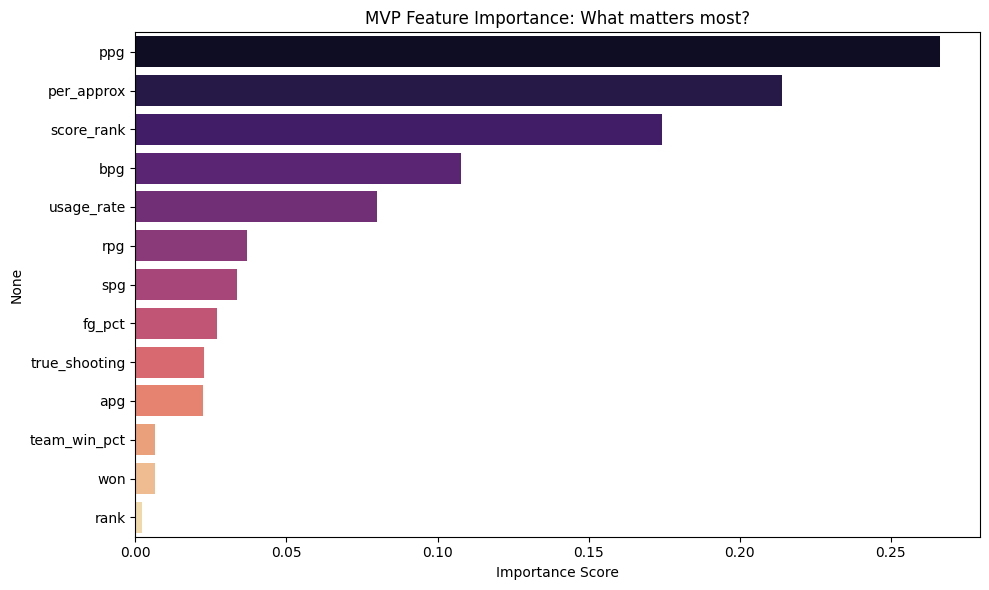

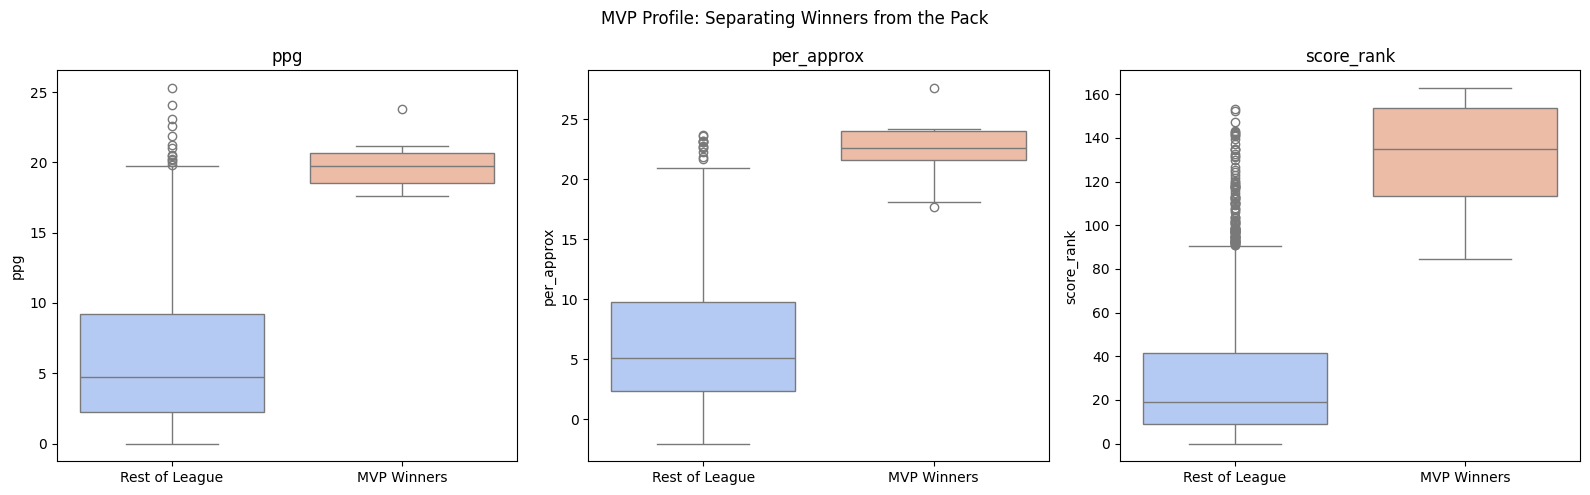

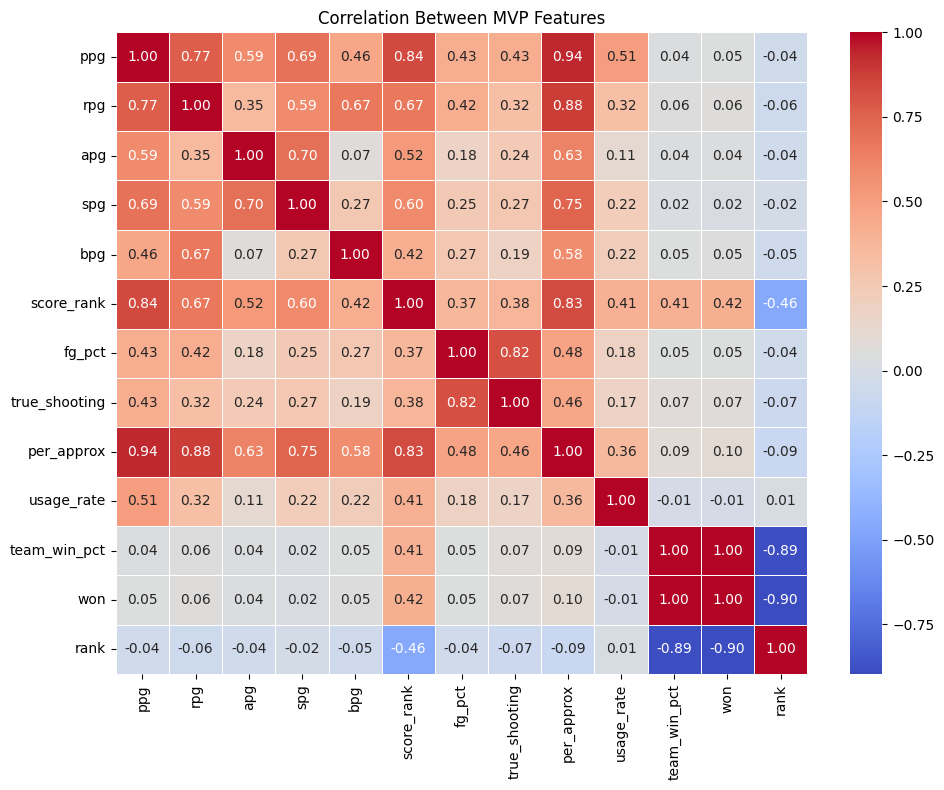

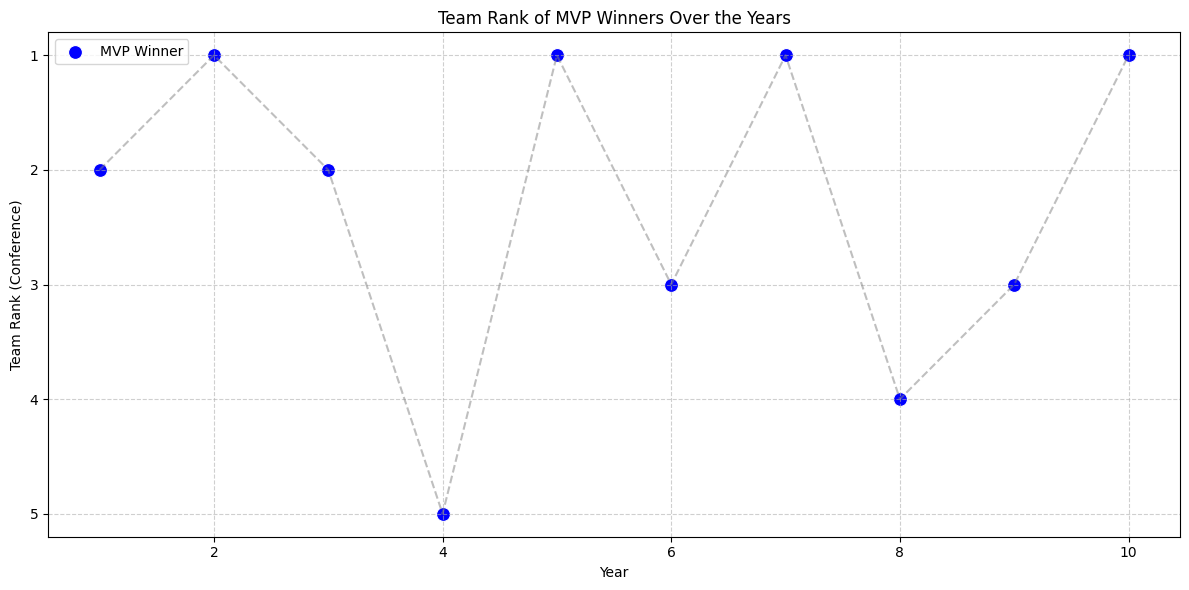

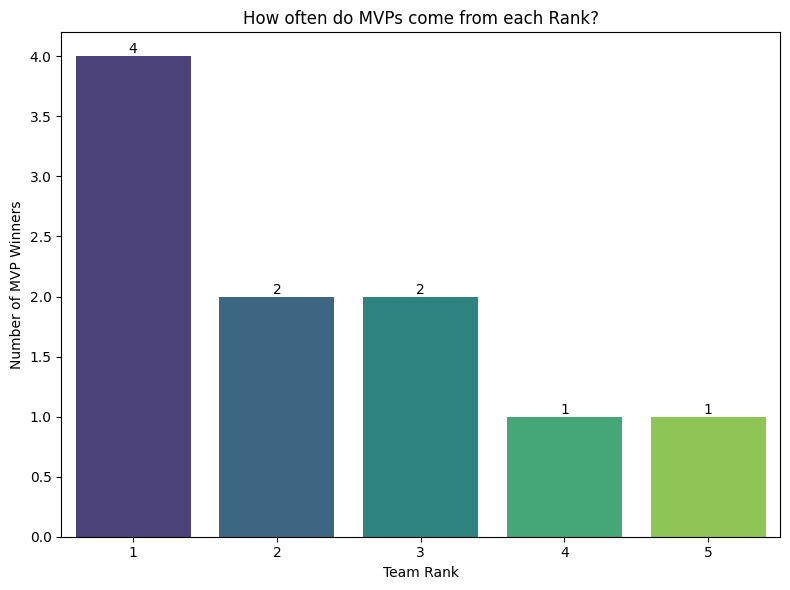

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Using the specific features file provided for MVP
df_features = pd.read_csv('../dataset_for_modeling/most_valuable_player_features.csv')
df_awards = pd.read_csv('../dataset_cleaned/awards_players.csv')

max_rank = df_features['rank'].max()
df_features['score_rank'] = df_features['ppg'] * ((max_rank + 1) - df_features['rank'])

# Define potential features based on common MVP criteria
# High Scoring, Team Success, Efficiency, Usage
features = [
    'ppg', 'rpg', 'apg', 'spg', 'bpg', 'score_rank',          # Box Score
    'fg_pct', 'true_shooting', 'per_approx',    # Efficiency
    'usage_rate',                               # Dominance
    'team_win_pct', 'won',                      # Team Success (Crucial for MVP)
    'rank'                                      # Team Rank (Lower is better)
]

# Clean Data
# Drop rows with NaN in key features
df_clean = df_features.dropna(subset=features).copy()

# Target: Won MVP?
# The features file already has 'won_mvp', let's verify
print(f"MVP Winners in Dataset: {df_clean['won_mvp'].sum()}")

# Train Model to get Feature Importance
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf.fit(df_clean[features], df_clean['won_mvp'])

# --- PLOT 1: Feature Importance ---
plt.figure(figsize=(10, 6))
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index, palette='magma')
plt.title('MVP Feature Importance: What matters most?')
plt.xlabel('Importance Score')
plt.tight_layout()

# --- PLOT 2: Winners vs Field (Top 3 Features) ---
# Compare distribution of Top 3 features
top_3 = imp.index[:3].tolist()
df_plot = df_clean.copy()
df_plot['Status'] = df_plot['won_mvp'].map({0: 'Rest of League', 1: 'MVP Winners'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feature in enumerate(top_3):
    sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('')

plt.suptitle('MVP Profile: Separating Winners from the Pack')
plt.tight_layout()

# --- PLOT 3: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
corr = df_clean[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Between MVP Features')
plt.tight_layout()

mvp_winners = df_features[df_features['won_mvp'] == 1].sort_values('year')

# --- PLOT 4: Trend of MVP Team Rank Over Time ---
plt.figure(figsize=(12, 6))
sns.scatterplot(data=mvp_winners, x='year', y='rank', s=100, color='blue', marker='o', label='MVP Winner')
plt.plot(mvp_winners['year'], mvp_winners['rank'], linestyle='--', color='gray', alpha=0.5)

# Invert Y-axis because rank 1 is better than Rank 7
plt.gca().invert_yaxis()
plt.yticks(range(1, int(mvp_winners['rank'].max()) + 1))
plt.title('Team Rank of MVP Winners Over the Years')
plt.xlabel('Year')
plt.ylabel('Team Rank (Conference)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=mvp_winners, x='rank', palette='viridis', order=sorted(mvp_winners['rank'].unique()))
plt.title('How often do MVPs come from each Rank?')
plt.xlabel('Team Rank')
plt.ylabel('Number of MVP Winners')

# Add count labels
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()


##### Feature Engineering and Data Loading

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Load Data
df_features = pd.read_csv('../dataset_for_modeling/most_valuable_player_features.csv')
df_awards = pd.read_csv('../dataset_cleaned/awards_players.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_predicted = pd.read_csv('../dataset_for_modeling/predicted_rank.csv')

# 2. Feature Engineering
df_model = df_features[df_features['year'] > 1].copy()
df_model['team_rank_feature'] = df_model['rank']

df_preds_map = df_predicted[['tmID', 'predicted_rank_model']].set_index('tmID')

def get_rank_feature(row):
    if row['year'] == 10:
        if row['tmID'] in df_preds_map.index:
            return df_preds_map.loc[row['tmID'], 'predicted_rank_model']
        else:
            return np.nan
    else:
        return row['rank']

df_model['team_rank_feature'] = df_model.apply(get_rank_feature, axis=1)

# --- Add Previous Team Stats ---
# We need the rank/stats from the previous year.
df_teams_prev = df_teams[['year', 'tmID', 'won', 'lost', 'rank']].copy()
# Rename to avoid confusion/collisions before merging
df_teams_prev.rename(columns={'rank': 'prev_team_rank'}, inplace=True)
df_teams_prev['prev_win_pct'] = df_teams_prev['won'] / (df_teams_prev['won'] + df_teams_prev['lost'])
df_teams_prev['next_year'] = df_teams_prev['year'] + 1

# Merge
df_model = pd.merge(df_model, df_teams_prev[['next_year', 'tmID', 'prev_win_pct', 'prev_team_rank']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')

# --- Add Relative Stats ---
stats_to_normalize = ['prev_ppg', 'prev_per_approx', 'prev_true_shooting']
for col in stats_to_normalize:
    league_avg = df_model.groupby('year')[col].transform('mean')
    df_model[f'{col}_rel'] = df_model[col] - league_avg

# --- Add Past MVP Count ---
mvp_lookup = df_awards[df_awards['award'] == 'Most Valuable Player']
def count_past_wins(x):
    return len(mvp_lookup[(mvp_lookup['playerID'] == x['playerID']) & (mvp_lookup['year'] < x['year'])])

df_model['past_mvp_count'] = df_model.apply(count_past_wins, axis=1)

max_rank = df_model['team_rank_feature'].max()

df_model['score_rank'] = df_model['prev_ppg'] * ((max_rank + 1) - df_model['team_rank_feature'])


##### Model Training and Evaluation


--- FINAL PREDICTION PHASE (Train on Years 2-9, Predict Year 10) ---
>>> Top 10 Pre-Season MVP Candidates (Year 10):
        playerID  mvp_prob   prev_ppg  prev_ppg_rel  team_rank_feature  \
1420  taylope01w  0.454781  17.794118      9.571409                  3   
719   jonesas01w  0.432915  17.000000      8.777291                  3   
1411  tauradi01w  0.409876  24.117647     15.894938                  3   
1658  youngso01w  0.337274  17.454545      9.231837                  5   
803   leslili01w  0.332226  15.060606      6.837897                  2   
648   jacksla01w  0.329451  20.238095     12.015387                  1   
1086  parkeca01w  0.242685  18.484848     10.262140                  2   
1467  thompti01w  0.119631  18.066667      9.843958                  2   
1134  pondeca01w  0.098289  21.218750     12.996041                  3   
373   dupreca01w  0.088005  16.323529      8.100821                  5   

      past_mvp_count  usage_rate  years_experience  score_rank  
14

/tmp/ipykernel_31890/93116361.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='magma')


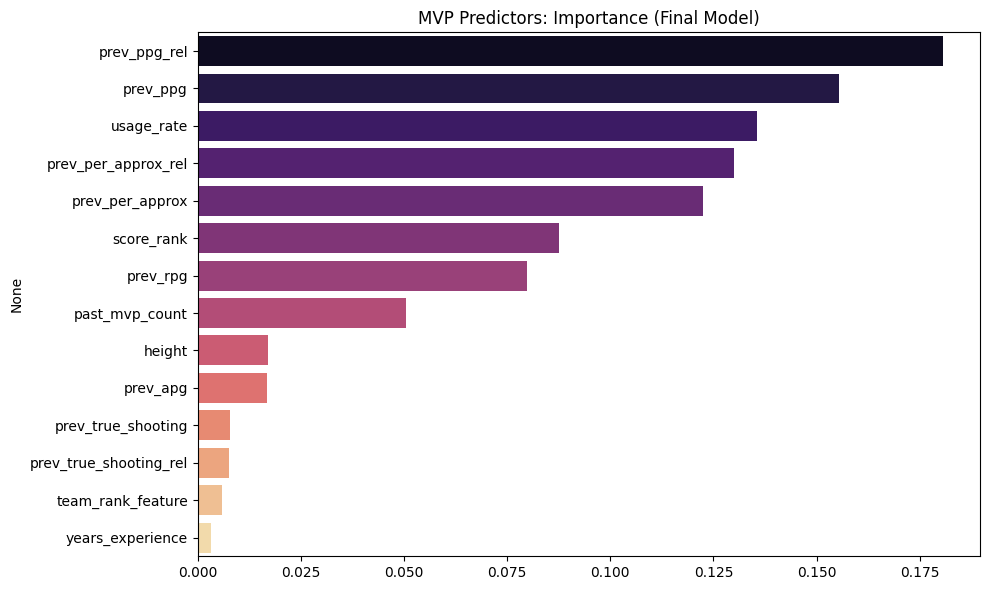

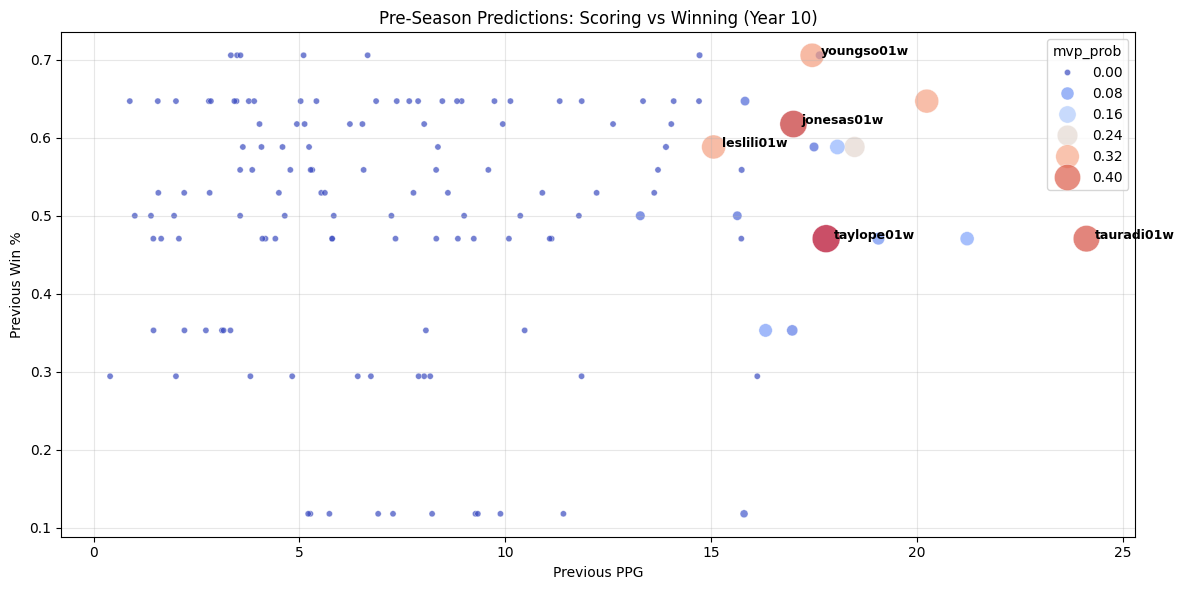

In [42]:
# 3. Define Features
features = [
    'prev_ppg', 'prev_rpg', 'prev_apg', 
    'prev_per_approx', 'prev_true_shooting',
    'years_experience', 'height',
    'team_rank_feature',
    'score_rank',
    'past_mvp_count',
    'prev_ppg_rel', 'prev_per_approx_rel', 
    'prev_true_shooting_rel',
    'usage_rate'
]

# Clean Data
df_model = df_model.dropna(subset=features).copy()

# --- Final Prediction (Train 2-9, Test 10) ---
print("\n--- FINAL PREDICTION PHASE (Train on Years 2-9, Predict Year 10) ---")
# We encompass Year 9 into the training set now to get the smartest model for Year 10
train_final = df_model[df_model['year'] < 10]
test_final = df_model[df_model['year'] == 10].copy()

rf_final = RandomForestClassifier(n_estimators=500, class_weight='balanced', max_depth=5, random_state=42)
rf_final.fit(train_final[features], train_final['won_mvp'])

test_final['mvp_prob'] = rf_final.predict_proba(test_final[features])[:, 1]

top_candidates = test_final.sort_values('mvp_prob', ascending=False).head(10)
print(">>> Top 10 Pre-Season MVP Candidates (Year 10):")
print(top_candidates[['playerID', 'mvp_prob', 'prev_ppg', 'prev_ppg_rel', 'team_rank_feature', 'past_mvp_count', 'usage_rate', 'years_experience', 'score_rank']])

# Feature Importance
plt.figure(figsize=(10, 6))
imp = pd.Series(rf_final.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index, palette='magma')
plt.title('MVP Predictors: Importance (Final Model)')
plt.tight_layout()

# Landscape
plt.figure(figsize=(12, 6))
sns.scatterplot(data=test_final, x='prev_ppg', y='prev_win_pct', size='mvp_prob', sizes=(20, 400), 
                hue='mvp_prob', palette='coolwarm', alpha=0.7)

for i in range(5):
    player = top_candidates.iloc[i]
    plt.text(player['prev_ppg']+0.2, player['prev_win_pct'], player['playerID'], fontsize=9, weight='bold')

plt.title('Pre-Season Predictions: Scoring vs Winning (Year 10)')
plt.xlabel('Previous PPG')
plt.ylabel('Previous Win %')
plt.grid(True, alpha=0.3)
plt.tight_layout()


--- STARTING MVP FORECAST (Window=3) ---

MVP FORECAST RESULTS
Overall ROC AUC: 0.9762

>>> Actual MVP Winners & Model Ranks:
     year    playerID  rank  mvp_prob   prev_ppg  team_rank_feature  \
63      5  leslili01w   1.0  0.235949  18.434783                  1   
246     6  swoopsh01w   8.0  0.024000  14.806452                  3   
336     7  leslili01w   1.0  0.509892  15.205882                  1   
461     8  jacksla01w   2.0  0.052000  19.500000                  4   
821    10  tauradi01w   6.0  0.010000  24.117647                  3   

     past_mvp_count  
63                1  
246               2  
336               2  
461               1  
821               0  


/tmp/ipykernel_31890/480964947.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='viridis')


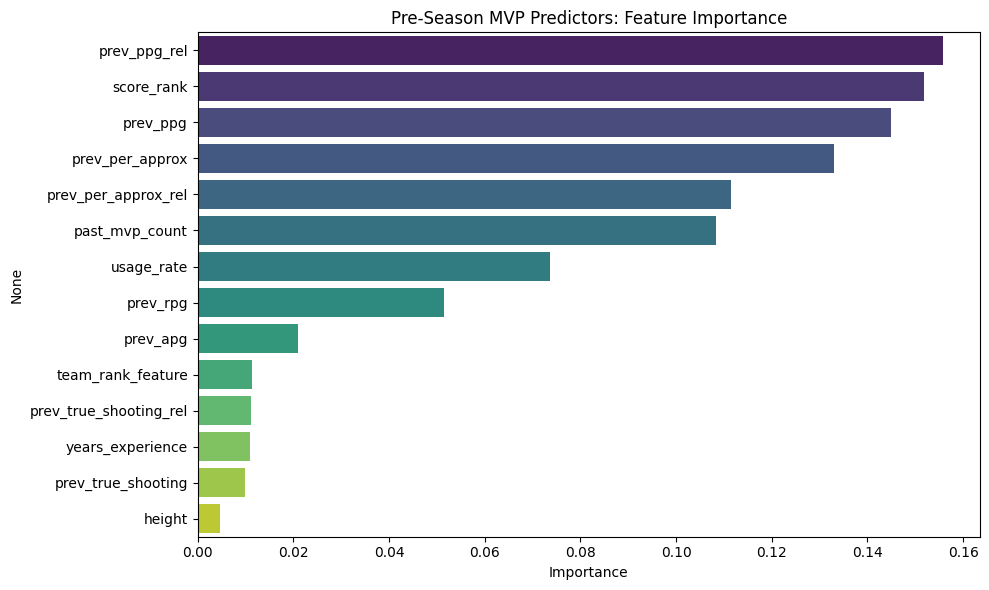

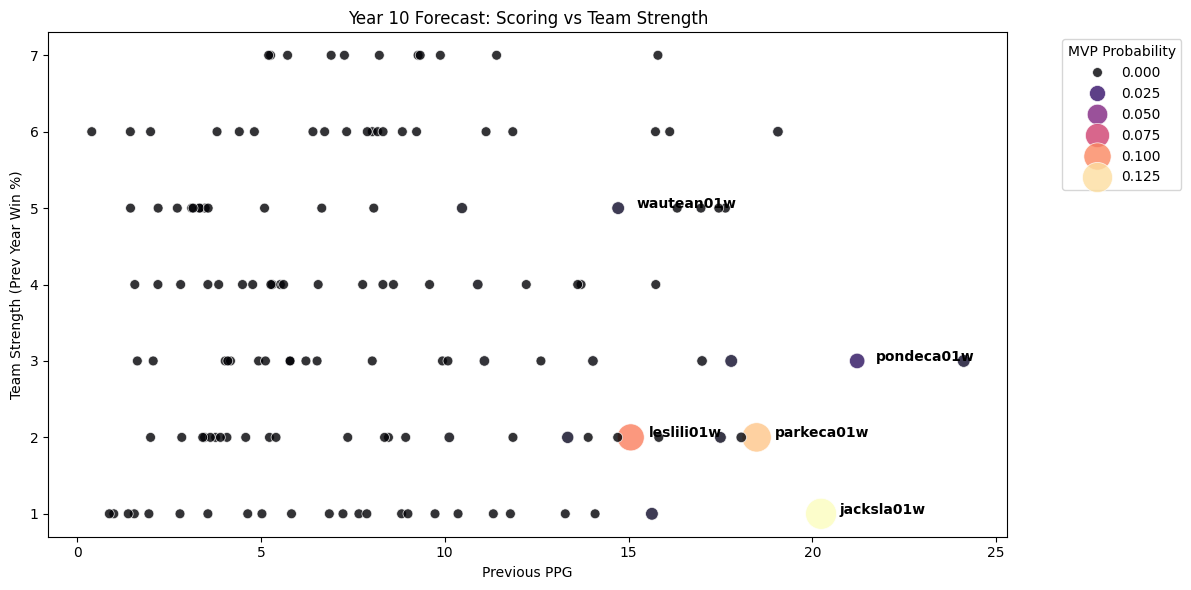


FORECASTING PERFORMANCE REPORT

>>> Actual Winners & Model Prediction Ranks:
     year    playerID  rank   prev_ppg   prev_rpg  team_rank_feature
63      5  leslili01w   1.0  18.434783  10.043478                  1
246     6  swoopsh01w   8.0  14.806452   4.935484                  3
336     7  leslili01w   1.0  15.205882   7.294118                  1
461     8  jacksla01w   2.0  19.500000   7.666667                  4
821    10  tauradi01w   6.0  24.117647   5.058824                  3

>>> Top 5 Predicted Candidates (Years 5-10):
     year    playerID  rank   prev_ppg   prev_rpg  team_rank_feature
63      5  leslili01w   1.0  18.434783  10.043478                  1
48      5  jacksla01w   2.0  21.151515   9.303030                  2
42      5  holdsch01w   3.0  20.518519  10.888889                  4
17      5  catchta01w   4.0  19.735294   8.000000                  6
99      5  smithka01w   5.0  18.235294   4.058824                  3
193     6  leslili01w   1.0  17.588235   9.88235

In [52]:
features = [
    'prev_ppg', 'prev_rpg', 'prev_apg', 
    'prev_per_approx', 'prev_true_shooting',
    'years_experience', 'height',
    'team_rank_feature',
    'score_rank',
    'past_mvp_count',
    'prev_ppg_rel', 'prev_per_approx_rel', 
    'prev_true_shooting_rel',
    'usage_rate' # This is now actually prev_usage
]

# Clean Data
df_model = df_model.dropna(subset=features).copy()

WINDOW = 3
predictions = []
target = 'won_mvp'

print(f"--- STARTING MVP FORECAST (Window={WINDOW}) ---")

# Predicting Years 5 to 10
for test_year in range(5, 11):
    
    start_train = test_year - WINDOW
    
    # 1. Split
    train = df_model[(df_model['year'] >= start_train) & (df_model['year'] < test_year)].copy()
    test = df_model[df_model['year'] == test_year].copy()
    
    if train.empty or test.empty: continue
    
    # 2. Train
    # MVP is highly competitive, deeper trees help capture interactions 
    # (e.g., High Scoring AND High Team Wins = MVP)
    rf = RandomForestClassifier(
        n_estimators=500, 
        class_weight='balanced', 
        max_depth=6, 
        random_state=42, 
        n_jobs=-1
    )
    rf.fit(train[features], train[target])
    
    # 3. Predict
    test['mvp_prob'] = rf.predict_proba(test[features])[:, 1]
    
    # 4. Store
    predictions.append(test[['playerID', 'year', 'mvp_prob', target] + features])

# --- 4. EVALUATION ---

if predictions:
    df_preds = pd.concat(predictions, ignore_index=True)
    
    # Rank candidates by probability within each year
    df_preds['rank'] = df_preds.groupby('year')['mvp_prob'].rank(ascending=False, method='first')
    
    # Analysis
    print("\n" + "="*30)
    print("MVP FORECAST RESULTS")
    print("="*30)
    
    try:
        auc = roc_auc_score(df_preds[target], df_preds['mvp_prob'])
        print(f"Overall ROC AUC: {auc:.4f}")
    except:
        print("AUC Error (Check if winners exist in test set)")

    # Show actual winners vs Predicted Rank
    winners = df_preds[df_preds[target] == 1]
    print("\n>>> Actual MVP Winners & Model Ranks:")
    # Showing 'prev_ppg' and 'team_rank_feature' to explain *why* they won
    cols_win = ['year', 'playerID', 'rank', 'mvp_prob', 'prev_ppg', 'team_rank_feature', 'past_mvp_count']
    print(winners[cols_win].sort_values('year'))

    # Feature Importance (Global Average)
    # We train one final model on all data to get a clean importance plot
    rf_final = RandomForestClassifier(n_estimators=500, class_weight='balanced', max_depth=6)
    rf_final.fit(df_preds[features], df_preds[target])
    
    plt.figure(figsize=(10, 6))
    imp = pd.Series(rf_final.feature_importances_, index=features).sort_values(ascending=False)
    sns.barplot(x=imp.values, y=imp.index, palette='viridis')
    plt.title('Pre-Season MVP Predictors: Feature Importance')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    # Landscape Plot (Last Year)
    last_year_data = df_preds[df_preds['year'] == 10]
    if not last_year_data.empty:
        plt.figure(figsize=(12, 6))
        sns.scatterplot(
            data=last_year_data, 
            x='prev_ppg', 
            y='team_rank_feature', 
            size='mvp_prob', 
            sizes=(50, 500), 
            hue='mvp_prob', 
            palette='magma', 
            alpha=0.8
        )
        
        # Annotate Top 5
        top_5 = last_year_data.sort_values('mvp_prob', ascending=False).head(5)
        for _, row in top_5.iterrows():
            plt.text(row['prev_ppg']+0.5, row['team_rank_feature'], row['playerID'], fontsize=10, weight='bold')
            
        plt.title('Year 10 Forecast: Scoring vs Team Strength')
        plt.xlabel('Previous PPG')
        plt.ylabel('Team Strength (Prev Year Win %)')
        plt.legend(title='MVP Probability', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
else:
    print("No predictions generated.")

if predictions:
    df_preds = pd.concat(predictions, ignore_index=True)
    
    # Calculate Rank per year
    df_preds['rank'] = df_preds.groupby('year')['mvp_prob'].rank(ascending=False, method='first')
    
    # Performance Metrics
    print("\n" + "="*30)
    print("FORECASTING PERFORMANCE REPORT")
    print("="*30)
    
    # Show Winners and their Ranks
    winners = df_preds[df_preds[target] == 1]
    print("\n>>> Actual Winners & Model Prediction Ranks:")
    # We use 'prev_mpg' to show they had low minutes before winning
    print(winners[['year', 'playerID', 'rank', 'prev_ppg', 'prev_rpg', 'team_rank_feature']].sort_values('year'))
    
    # Show Top 5 Predictions for every year requested
    print("\n>>> Top 5 Predicted Candidates (Years 5-10):")
    cols = ['year', 'playerID', 'rank', 'prev_ppg', 'prev_rpg', 'team_rank_feature']
    print(df_preds[df_preds['rank'] <= 5].sort_values(['year', 'rank'])[cols])

else:
    print("No predictions were generated.")

#### Sixth Woman Award

##### Data Analysis

Total Candidates: 357
Rookies included in pool: 143


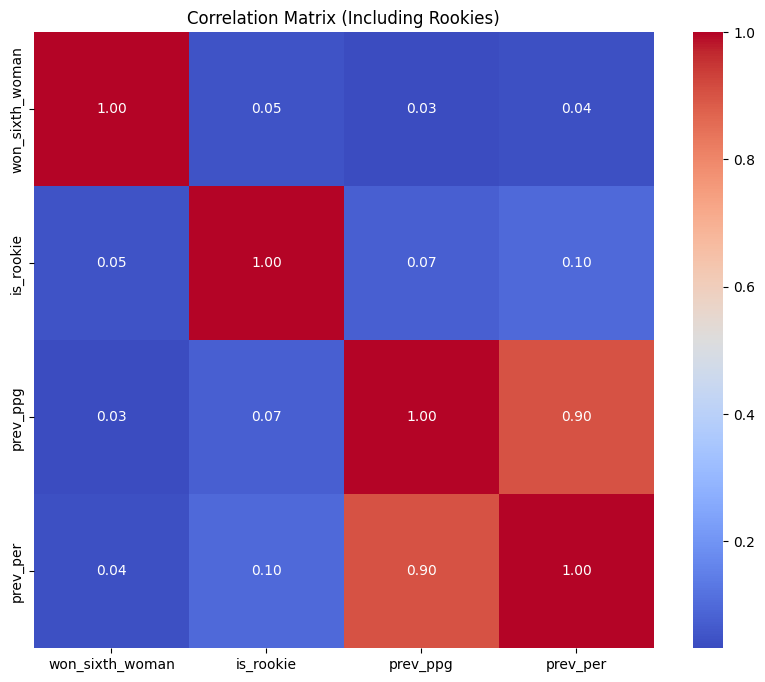

/tmp/ipykernel_18573/2540493695.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='won_sixth_woman', y='prev_ppg', data=df_candidates, palette='Set2', ax=axes[0])
/tmp/ipykernel_18573/2540493695.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='won_sixth_woman', y='prev_per', data=df_candidates, palette='Set2', ax=axes[1])
/tmp/ipykernel_18573/2540493695.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='won_sixth_woman', y='prev_bench_games', data=df_candidates, palette='Set2', ax=axes[2])


Analysis Candidate Pool Size: 357
Winners in Analysis Pool: 3


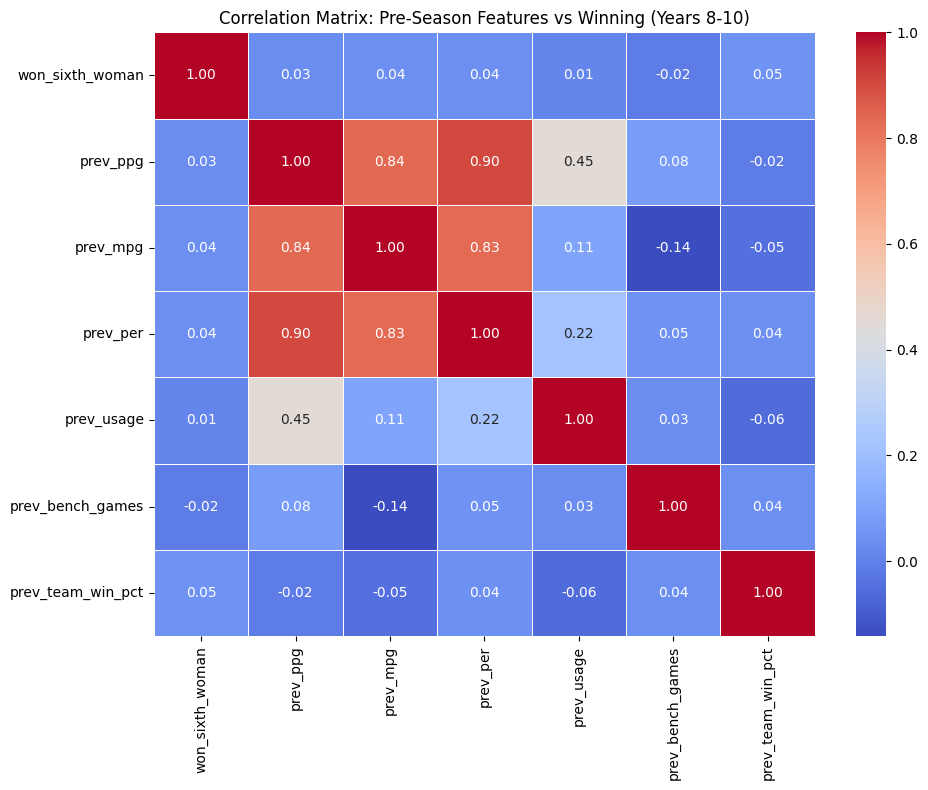

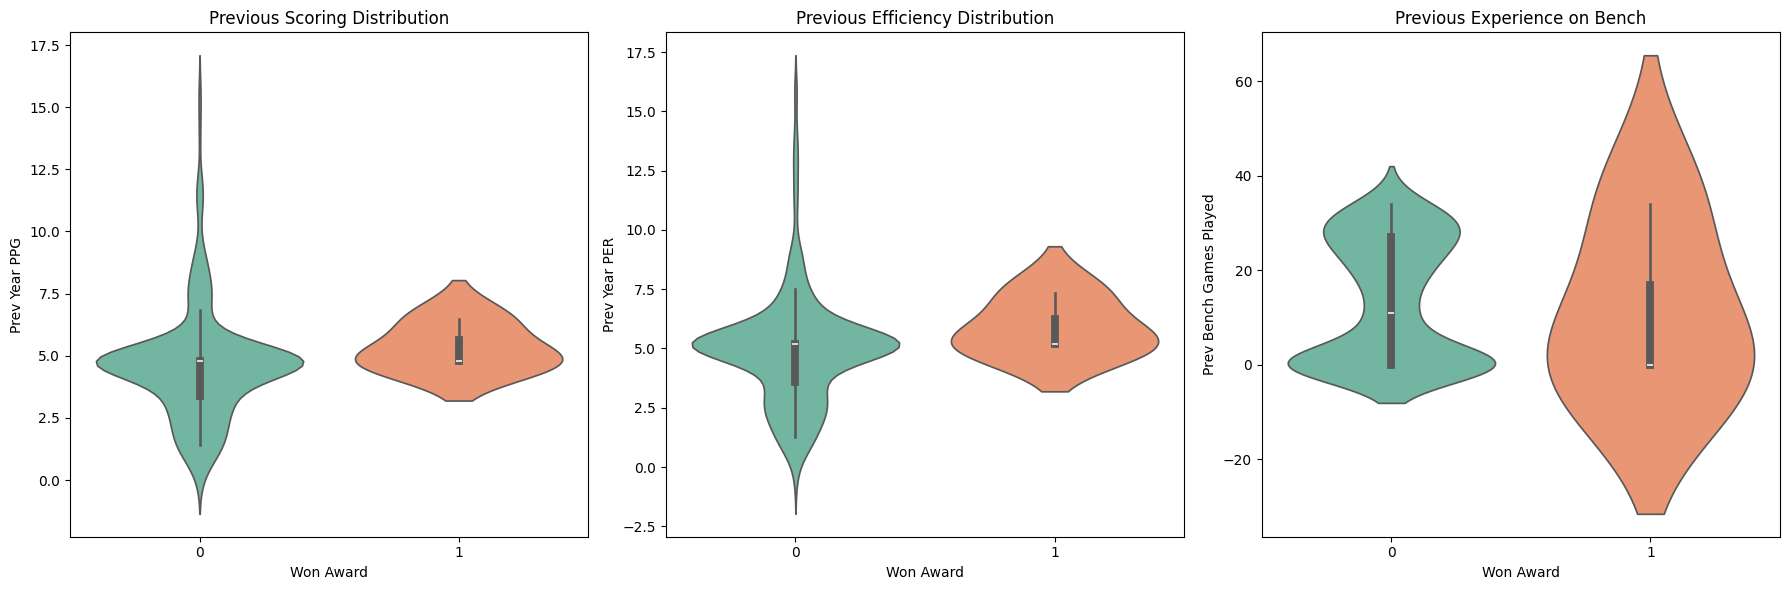

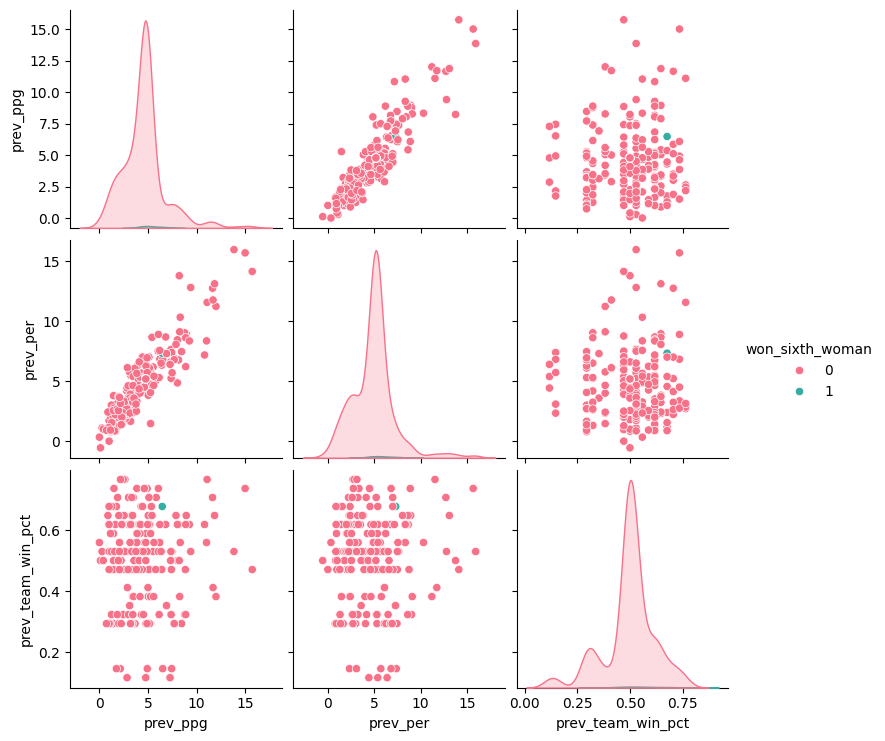

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_sw = pd.read_csv('../dataset_for_modeling/sixth_woman_features.csv')

# 2. Prepare Lagged Data (Target Years 8, 9, 10)
# We need features from Years 7, 8, 9.
df_sw_filtered = df_sw[df_sw['year'].between(7, 10)].copy()

# Self-join to get previous year stats
df_prev = df_sw_filtered.copy()
df_prev['next_year'] = df_prev['year'] + 1
cols_to_lag = ['playerID', 'next_year', 'ppg', 'mpg', 'per_approx', 'usage_rate', 'starting_pct', 'bench_games', 'team_win_pct']
df_prev = df_prev[cols_to_lag]
df_prev.columns = ['playerID', 'year', 'prev_ppg', 'prev_mpg', 'prev_per', 'prev_usage', 'prev_start_pct', 'prev_bench_games', 'prev_team_win_pct']

# Merge to get the Analysis DataFrame
# Target: won_sixth_woman in Year T
# Features: Stats from Year T-1
df_analysis = pd.merge(df_sw_filtered[['year', 'playerID', 'won_sixth_woman', 'years_experience']], 
                       df_prev, 
                       on=['year', 'playerID'], 
                       how='left')

df_analysis['is_rookie'] = np.where(
    (df_analysis['prev_ppg'].isna()) & (df_analysis['years_experience'] == 0), 
    1, 
    0
)

# Impute values for Rookies so they aren't dropped
# For stats, we can use the Median of the dataset (neutral assumption)
# For starting_pct, we set to 0 to ensure they enter the "Candidate Pool"
fill_values = {
    'prev_ppg': df_sw['ppg'].median(),
    'prev_mpg': df_sw['mpg'].median(),
    'prev_per': df_sw['per_approx'].median(),
    'prev_usage': df_sw['usage_rate'].median(),
    'prev_team_win_pct': 0.5,
    'prev_start_pct': 0.0,      # Assume rookie starts on bench
    'prev_bench_games': 0.0     # Technical truth (0 games played)
}

# Apply imputation only for rookies (or all NaNs if preferred)
for col, val in fill_values.items():
    # Only fill if it's a rookie (preserves NaNs for veterans who legitimately missed a year if needed)
    df_analysis.loc[df_analysis['is_rookie'] == 1, col] = df_analysis.loc[df_analysis['is_rookie'] == 1, col].fillna(val)

# 4. Filter for Candidates
# Now Rookies (with prev_start_pct imputed as 0) will be included
df_candidates = df_analysis[df_analysis['prev_start_pct'] < 0.5].copy()

print(f"Total Candidates: {len(df_candidates)}")
print(f"Rookies included in pool: {df_candidates['is_rookie'].sum()}")

# 5. Visualizations (Updated to show Rookie separation)
plt.figure(figsize=(10, 8))
corr_cols = ['won_sixth_woman', 'is_rookie', 'prev_ppg', 'prev_per'] # Added is_rookie
sns.heatmap(df_candidates[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Including Rookies)')
plt.show()

# Filter for Candidates: Players who started < 50% of games in the PREVIOUS year
# This defines the "Pool of Potential Winners" visible pre-season.
df_candidates = df_analysis[df_analysis['prev_start_pct'] < 0.5].copy()

# 3. Visualizations

# A. Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_cols = ['won_sixth_woman', 'prev_ppg', 'prev_mpg', 'prev_per', 'prev_usage', 'prev_bench_games', 'prev_team_win_pct']
corr = df_candidates[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: Pre-Season Features vs Winning (Years 8-10)')
plt.tight_layout()

# B. Distribution Comparison (Violin Plots)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Prev PPG
sns.violinplot(x='won_sixth_woman', y='prev_ppg', data=df_candidates, palette='Set2', ax=axes[0])
axes[0].set_title('Previous Scoring Distribution')
axes[0].set_xlabel('Won Award')
axes[0].set_ylabel('Prev Year PPG')

# Prev PER (Efficiency)
sns.violinplot(x='won_sixth_woman', y='prev_per', data=df_candidates, palette='Set2', ax=axes[1])
axes[1].set_title('Previous Efficiency Distribution')
axes[1].set_xlabel('Won Award')
axes[1].set_ylabel('Prev Year PER')

# Prev Bench Games
sns.violinplot(x='won_sixth_woman', y='prev_bench_games', data=df_candidates, palette='Set2', ax=axes[2])
axes[2].set_title('Previous Experience on Bench')
axes[2].set_xlabel('Won Award')
axes[2].set_ylabel('Prev Bench Games Played')

plt.tight_layout()

# C. Pair Plot for Top Features
# To see the separation
sns.pairplot(df_candidates[['prev_ppg', 'prev_per', 'prev_team_win_pct', 'won_sixth_woman']], 
             hue='won_sixth_woman', palette='husl', diag_kind='kde')

print("Analysis Candidate Pool Size:", len(df_candidates))
print("Winners in Analysis Pool:", df_candidates['won_sixth_woman'].sum())


##### Feature Engineering and Model Training

/tmp/ipykernel_18573/1271544050.py:26: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_bench_stats = df_sw.groupby(['year', 'tmID']).apply(


Top Colleges Identified: ['Unknown', 'Tennessee', 'Connecticut', 'Georgia', 'Stanford', 'Louisiana Tech', 'Florida', 'USC', 'Louisiana State', 'North Carolina']

>>> Top Predictions Year 10 (Including Rookies):
       playerID tmID   prob  is_rookie  age  coach_hist_bench_pct   prev_ppg
261  hornbal01w  DET  0.164          0   21              0.300000   5.411765
708  wiggica01w  MIN  0.144          0   19              0.300000  15.733333
730  wrighta01w  SEA  0.098          0   23              0.348762   7.882353
256  holliqu01w  MIN  0.078          1   18              0.300000   4.773460
36   battlas01w  NYL  0.058          0   24              0.300788   3.558824
581  smithbr01w  PHO  0.054          0   22              0.328157   4.100000
67   braxtka01w  DET  0.048          0   23              0.300000   8.939394
507  pierspl01w  DET  0.044          0   25              0.300000  11.857143
524  pricear01w  CHI  0.042          0   21              0.313164   6.911765
523  pricear01w  AT

/tmp/ipykernel_18573/1271544050.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='viridis')


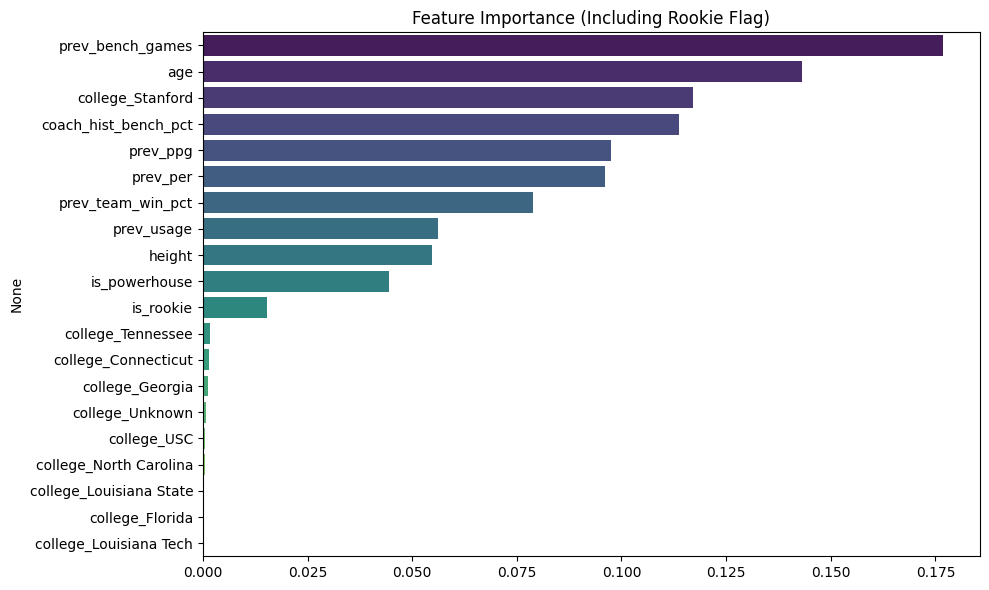

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# 1. Load Data
df_sw = pd.read_csv('../dataset_for_modeling/sixth_woman_features.csv')
df_players = pd.read_csv('../dataset_cleaned/players.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')
df_predicted_rank = pd.read_csv('../dataset_for_modeling/predicted_rank.csv')

# --- Feature Engineering: Age & Height ---
df_players['birth_year'] = pd.to_datetime(df_players['birthDate'], errors='coerce').dt.year
df_sw = pd.merge(df_sw, df_players[['bioID', 'birth_year', 'height']], left_on='playerID', right_on='bioID', how='left')
df_sw['age'] = (1996 + df_sw['year']) - df_sw['birth_year']
df_sw['age'] = df_sw['age'].fillna(25)
if 'height_y' in df_sw.columns:
    df_sw['height'] = df_sw['height_y']
    df_sw.drop(columns=['height_x', 'height_y'], inplace=True)
df_sw['height'] = df_sw['height'].fillna(72)

# --- Feature Engineering: Coach Features ---
# 1. Calculate "Bench Usage" per Team-Year
df_sw['is_bench_calc'] = df_sw['starting_pct'] < 0.5
team_bench_stats = df_sw.groupby(['year', 'tmID']).apply(
    lambda x: pd.Series({
        'total_min': x['minutes'].sum(),
        'bench_min': x.loc[x['is_bench_calc'], 'minutes'].sum()
    })
).reset_index()
team_bench_stats['bench_min_pct'] = team_bench_stats['bench_min'] / team_bench_stats['total_min']

df_sw['college'] = df_sw['college'].fillna('Unknown')
top_colleges = df_sw['college'].value_counts().head(10).index.tolist()
print(f"Top Colleges Identified: {top_colleges}")

for college in top_colleges:
    df_sw[f'college_{college}'] = (df_sw['college'] == college).astype(int)

top_5 = top_colleges[:5]
df_sw['is_powerhouse'] = df_sw['college'].apply(lambda x: 1 if x in top_5 else 0)

# 2. Attach Coach and Calculate History
coaches_dedup = df_coaches.sort_values('stint').groupby(['year', 'tmID']).last().reset_index()
team_bench_stats = pd.merge(team_bench_stats, coaches_dedup[['year', 'tmID', 'coachID']], on=['year', 'tmID'], how='left')

coach_history = []
unique_coaches = team_bench_stats['coachID'].dropna().unique()
years = sorted(team_bench_stats['year'].unique())

for yr in years:
    for coach in unique_coaches:
        history = team_bench_stats[(team_bench_stats['coachID'] == coach) & (team_bench_stats['year'] < yr)]
        if not history.empty:
            avg_usage = history['bench_min_pct'].mean()
            exp = len(history)
            coach_history.append({'year': yr, 'coachID': coach, 'coach_hist_bench_pct': avg_usage, 'coach_exp': exp})
        else:
             coach_history.append({'year': yr, 'coachID': coach, 'coach_hist_bench_pct': 0.30, 'coach_exp': 0})

df_coach_hist = pd.DataFrame(coach_history)

# Merge Coach History
df_sw = pd.merge(df_sw, coaches_dedup[['year', 'tmID', 'coachID']], on=['year', 'tmID'], how='left')
df_sw = pd.merge(df_sw, df_coach_hist, on=['year', 'coachID'], how='left')
df_sw['coach_hist_bench_pct'] = df_sw['coach_hist_bench_pct'].fillna(0.30)
df_sw['coach_exp'] = df_sw['coach_exp'].fillna(0)

# --- Feature Engineering: Lagged Stats (Modified for Rookies) ---
df_model_base = df_sw[df_sw['year'].between(7, 10)].copy()

# Ensure years_experience is available for rookie detection
df_sw = df_sw.sort_values(['playerID', 'year'])
df_sw['years_experience'] = df_sw.groupby('playerID').cumcount()

df_prev = df_sw.copy()
df_prev['next_year'] = df_prev['year'] + 1
cols_to_lag = ['playerID', 'next_year', 'ppg', 'mpg', 'per_approx', 'usage_rate', 'starting_pct', 'bench_games', 'team_win_pct']
df_prev = df_prev[cols_to_lag]
df_prev.columns = ['playerID', 'year', 'prev_ppg', 'prev_mpg', 'prev_per', 'prev_usage', 'prev_start_pct', 'prev_bench_games', 'prev_team_win_pct']

# CHANGE 1: LEFT MERGE (Keep players even if they have no history)
df_analysis = pd.merge(df_model_base, df_prev, on=['year', 'playerID'], how='left')

# CHANGE 2: IDENTIFY ROOKIES (No prev stats + 0 years experience)
# If a veteran missed a season, they might have NaN prev_ppg but years_exp > 0. We focus on true rookies here.
df_analysis['is_rookie'] = np.where(
    (df_analysis['prev_ppg'].isna()) & (df_analysis['years_experience'] == 0), 
    1, 
    0
)

# CHANGE 3: IMPUTE MISSING VALUES FOR ROOKIES
# We must set 'prev_start_pct' to 0.0 so they pass the candidate filter.
rookie_mask = df_analysis['is_rookie'] == 1

df_analysis.loc[rookie_mask, 'prev_start_pct'] = 0.0      # Crucial: Assume they start on bench
df_analysis.loc[rookie_mask, 'prev_bench_games'] = 0.0    # 0 games played
df_analysis.loc[rookie_mask, 'prev_team_win_pct'] = 0.5   # Neutral assumption
impute_map = {
    'prev_ppg': 'ppg',
    'prev_mpg': 'mpg',
    'prev_per': 'per_approx',   # <--- FIX: Maps to the correct original column
    'prev_usage': 'usage_rate'
}

for lag_col, orig_col in impute_map.items():
    # Calculate median from the full original dataset (df_sw)
    median_val = df_sw[orig_col].median()
    # Fill only the rookie rows in the analysis set
    df_analysis.loc[rookie_mask, lag_col] = median_val

# Filter Candidates: Previous year bench players (< 50% starts). 
# Rookies now pass this because we set their prev_start_pct to 0.
df_candidates = df_analysis[df_analysis['prev_start_pct'] < 0.5].copy()

# --- Modeling ---
train_df = df_candidates[df_candidates['year'].isin([8, 9])].copy()
test_df = df_candidates[df_candidates['year'] == 10].copy()

# CHANGE 4: Add 'is_rookie' to feature list

college_features = [f'college_{c}' for c in top_colleges] + ['is_powerhouse']

features_model = [
    'age', 'height',
    'coach_hist_bench_pct',
    'prev_ppg', 'prev_per', 'prev_bench_games', 
    'prev_team_win_pct', 'prev_usage',
    'is_rookie' 
] + college_features

# Drop remaining NAs (e.g., missing Coach data or non-rookie gaps)
train_df = train_df.dropna(subset=features_model)
test_df = test_df.dropna(subset=features_model)

if len(train_df) > 0:
    rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
    rf.fit(train_df[features_model], train_df['won_sixth_woman'])
    
    test_df['prob'] = rf.predict_proba(test_df[features_model])[:, 1]
    
    print("\n>>> Top Predictions Year 10 (Including Rookies):")
    cols_show = ['playerID', 'tmID', 'prob', 'is_rookie', 'age', 'coach_hist_bench_pct', 'prev_ppg']
    print(test_df.sort_values('prob', ascending=False).head(10)[cols_show])
    
    # Check if any rookies are in the top 20
    top_20 = test_df.sort_values('prob', ascending=False).head(20)
    print(f"\nRookies in Top 20: {top_20['is_rookie'].sum()}")

    # Feature Importance
    imp = pd.Series(rf.feature_importances_, index=features_model).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=imp.values, y=imp.index, palette='viridis')
    plt.title('Feature Importance (Including Rookie Flag)')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough training data.")

#### Rookie of the Year Award

##### Data Analysis

Total Rookies in Dataset: 555
ROY Winners: 10


/tmp/ipykernel_31890/1385659609.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='won_roy', y='prev_team_win_pct', data=df_rookies, ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_31890/1385659609.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='won_roy', y='vacated_min_pct', data=df_rookies, ax=axes[0, 1], palette='coolwarm')
/tmp/ipykernel_31890/1385659609.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='won_roy', y='coach_max_rookie_mpg', data=df_rookies, ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_31890/13856596

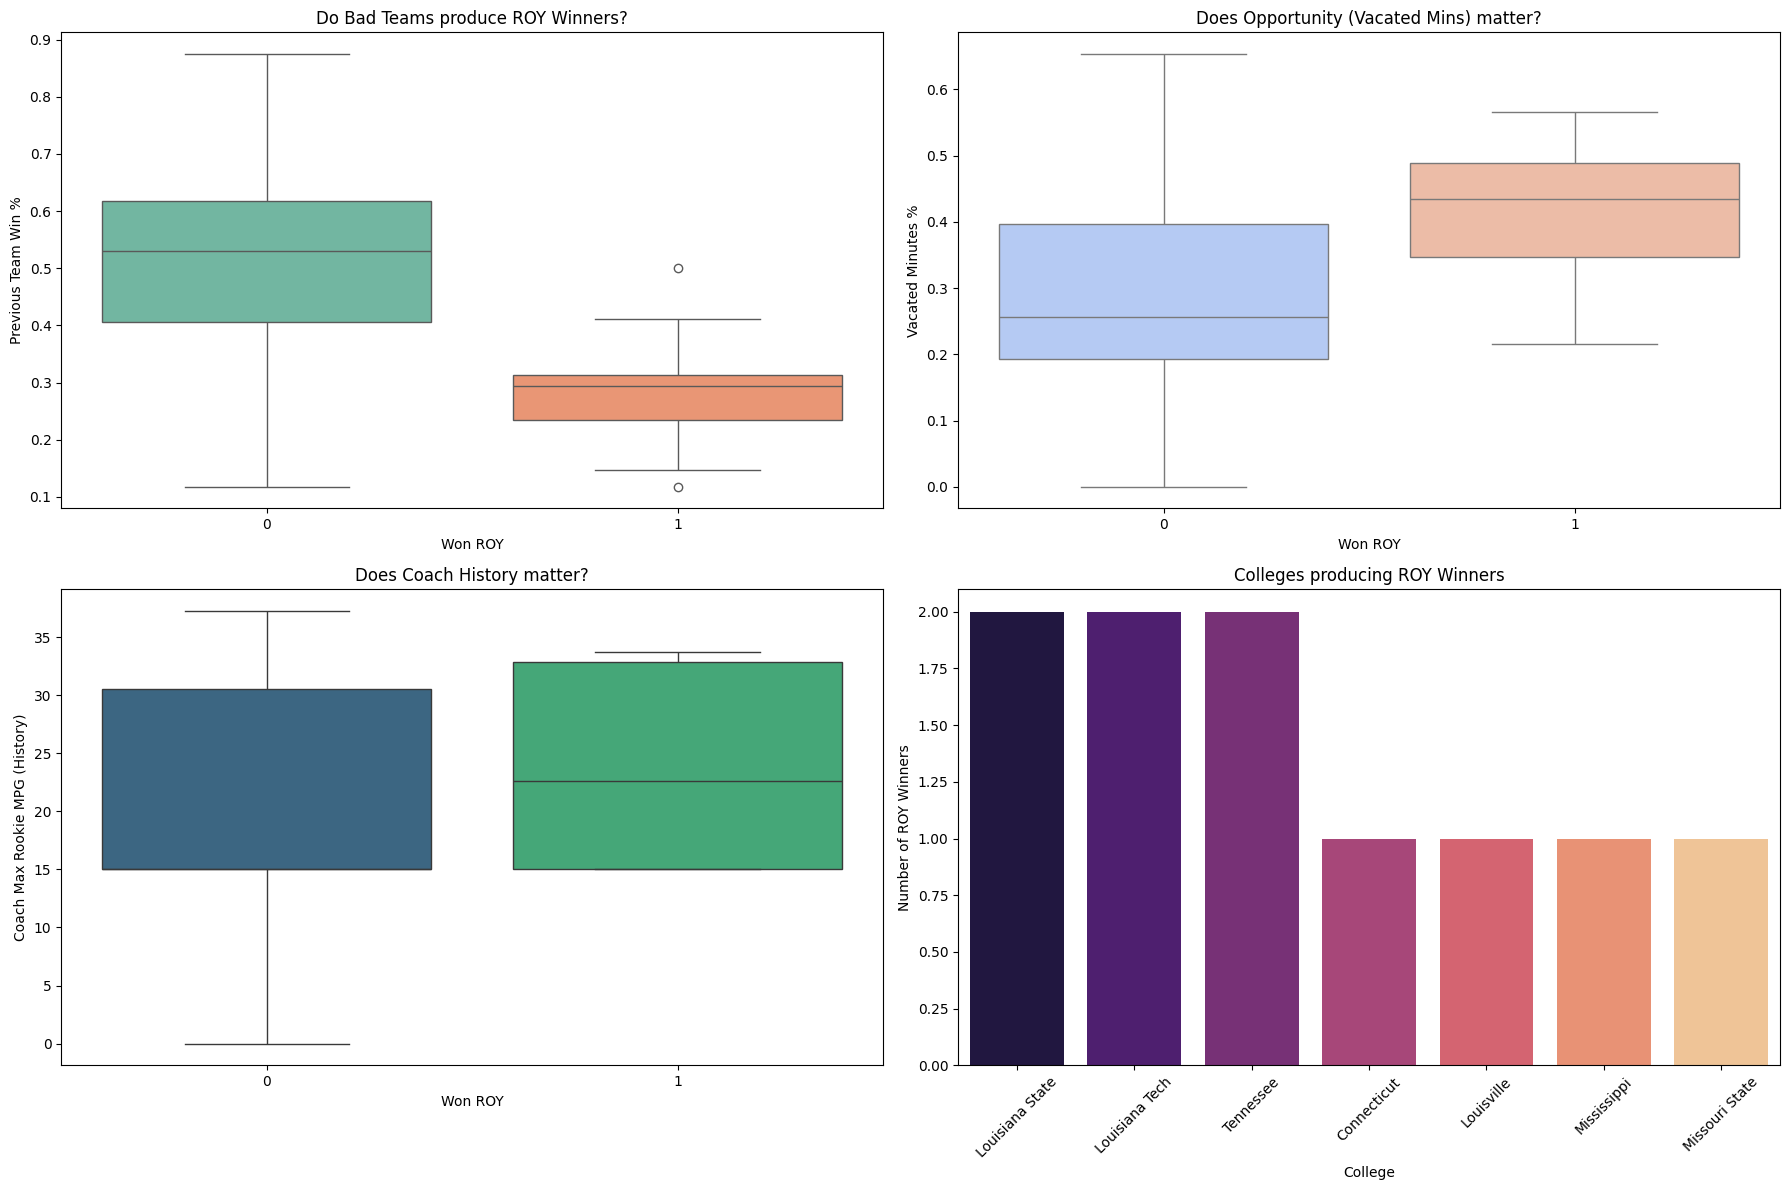

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df_roy = pd.read_csv('../dataset_for_modeling/rookie_of_year_features.csv')
df_players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')
df_awards_players = pd.read_csv('../dataset_cleaned/awards_players.csv')
df_teams_post = pd.read_csv('../dataset_cleaned/teams_post.csv')

# Filter for Rookies Only
df_rookies = df_roy[df_roy['is_rookie'] == 1].copy()
print(f"Total Rookies in Dataset: {len(df_rookies)}")
print(f"ROY Winners: {df_rookies['won_roy'].sum()}")

# 2. Feature Engineering: Team Draft Potential (Proxy for Talent)
df_teams['prev_year'] = df_teams['year'] + 1
df_teams['win_pct'] = df_teams['won'] / (df_teams['won'] + df_teams['lost'])
df_rookies = pd.merge(df_rookies, df_teams[['prev_year', 'tmID', 'win_pct', 'rank']], 
                      left_on=['year', 'tmID'], right_on=['prev_year', 'tmID'], how='left')
df_rookies.rename(columns={'win_pct': 'prev_team_win_pct', 'rank': 'prev_team_rank'}, inplace=True)

# 3. Feature Engineering: Vacated Minutes (Opportunity)
rosters = df_players_teams.groupby(['year', 'tmID', 'playerID'])['minutes'].sum().reset_index()

vacated_data = []
teams_list = df_teams['tmID'].unique()
years = sorted(df_teams['year'].unique())

for yr in years:
    if yr == 1: continue 
    for tm in teams_list:
        ros_prev = rosters[(rosters['year'] == yr - 1) & (rosters['tmID'] == tm)]
        ros_curr = rosters[(rosters['year'] == yr) & (rosters['tmID'] == tm)]
        
        if ros_prev.empty:
            vacated_mins = 0
            vacated_pct = 0
        else:
            returning_ids = set(ros_curr['playerID'])
            leavers = ros_prev[~ros_prev['playerID'].isin(returning_ids)]
            vacated_mins = leavers['minutes'].sum()
            total_mins_prev = ros_prev['minutes'].sum()
            vacated_pct = vacated_mins / total_mins_prev if total_mins_prev > 0 else 0
            
        vacated_data.append({'year': yr, 'tmID': tm, 'vacated_min_pct': vacated_pct})

df_vacated = pd.DataFrame(vacated_data)
df_rookies = pd.merge(df_rookies, df_vacated, on=['year', 'tmID'], how='left')

# 4. Feature Engineering: Coach's Rookie Usage (History)
coaches_dedup = df_coaches.sort_values('stint').groupby(['year', 'tmID']).last().reset_index()
rookie_ids = df_roy[df_roy['is_rookie'] == 1][['year', 'playerID']].drop_duplicates()
rookie_ids['is_rookie_flag'] = 1

df_pt_roy = pd.merge(df_players_teams, rookie_ids, on=['year', 'playerID'], how='left')
df_pt_roy['is_rookie_flag'] = df_pt_roy['is_rookie_flag'].fillna(0)
df_pt_roy = pd.merge(df_pt_roy, coaches_dedup[['year', 'tmID', 'coachID']], on=['year', 'tmID'], how='left')

coach_stats = []
all_coaches = df_pt_roy['coachID'].dropna().unique()

for coach in all_coaches:
    coach_data = df_pt_roy[df_pt_roy['coachID'] == coach]
    for yr in years:
        history = coach_data[coach_data['year'] < yr]
        if not history.empty:
            rookies_hist = history[history['is_rookie_flag'] == 1]
            if not rookies_hist.empty:
                avg_rookie_mpg = (rookies_hist['minutes'] / rookies_hist['GP']).mean()
                max_rookie_mpg = (rookies_hist['minutes'] / rookies_hist['GP']).max()
            else:
                avg_rookie_mpg = 0
                max_rookie_mpg = 0
        else:
            avg_rookie_mpg = 10 
            max_rookie_mpg = 15
            
        coach_stats.append({
            'year': yr, 
            'coachID': coach, 
            'coach_avg_rookie_mpg': avg_rookie_mpg,
            'coach_max_rookie_mpg': max_rookie_mpg
        })

df_coach_stats = pd.DataFrame(coach_stats)
df_rookies = pd.merge(df_rookies, coaches_dedup[['year', 'tmID', 'coachID']], on=['year', 'tmID'], how='left')
df_rookies = pd.merge(df_rookies, df_coach_stats, on=['year', 'coachID'], how='left')

# 5. College Analysis (New Section)
df_rookies['college'] = df_rookies['college'].astype(str).str.strip()
roy_colleges = df_rookies[df_rookies['won_roy'] == 1]['college'].value_counts()
roy_winners_colleges = roy_colleges.index.tolist()
df_colleges_roi = df_rookies[df_rookies['college'].isin(roy_winners_colleges)].copy()
college_counts = df_colleges_roi.groupby('college').agg(
    Total_Rookies=('playerID', 'count'),
    ROY_Winners=('won_roy', 'sum')
).sort_values('ROY_Winners', ascending=False)


# Visualization (Updated to 2x2 Grid)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# A. Previous Team Success
sns.boxplot(x='won_roy', y='prev_team_win_pct', data=df_rookies, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Do Bad Teams produce ROY Winners?')
axes[0, 0].set_xlabel('Won ROY')
axes[0, 0].set_ylabel('Previous Team Win %')

# B. Vacated Minutes
sns.boxplot(x='won_roy', y='vacated_min_pct', data=df_rookies, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Does Opportunity (Vacated Mins) matter?')
axes[0, 1].set_xlabel('Won ROY')
axes[0, 1].set_ylabel('Vacated Minutes %')

# C. Coach History
sns.boxplot(x='won_roy', y='coach_max_rookie_mpg', data=df_rookies, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Does Coach History matter?')
axes[1, 0].set_xlabel('Won ROY')
axes[1, 0].set_ylabel('Coach Max Rookie MPG (History)')

# D. College Analysis (New Plot)
sns.barplot(x=college_counts.index, y=college_counts['ROY_Winners'], ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Colleges producing ROY Winners')
axes[1, 1].set_xlabel('College')
axes[1, 1].set_ylabel('Number of ROY Winners')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_31890/2024444209.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='won_roy', y='prev_team_win_pct', data=df_rookies, ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_31890/2024444209.py:187: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='won_roy', y='vacated_min_pct', data=df_rookies, ax=axes[0, 1], palette='coolwarm')
/tmp/ipykernel_31890/2024444209.py:193: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='won_roy', y='coach_max_rookie_mpg', data=df_rookies, ax=axes[1, 0], palette='viridis')
/tmp/ipykernel_31890/20244442

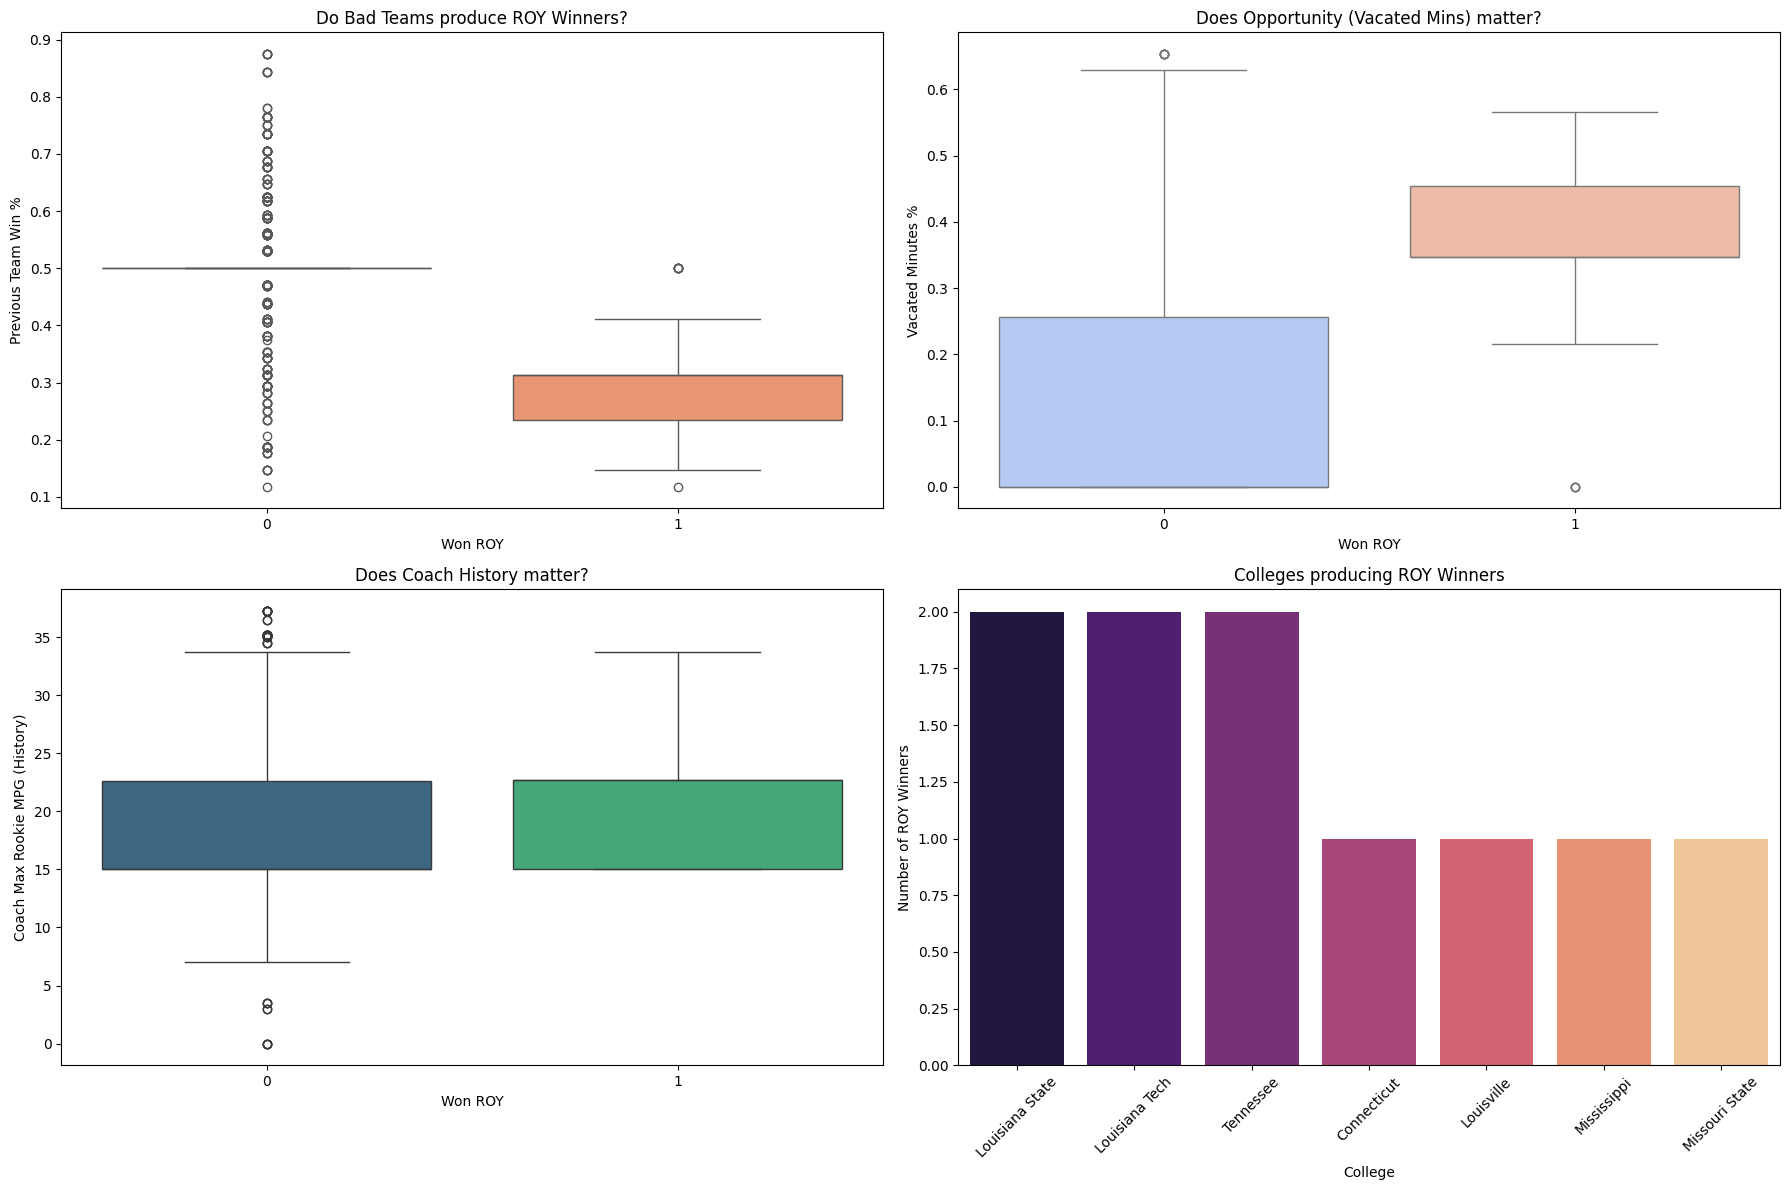

/tmp/ipykernel_31890/2024444209.py:217: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='viridis', ax=ax)


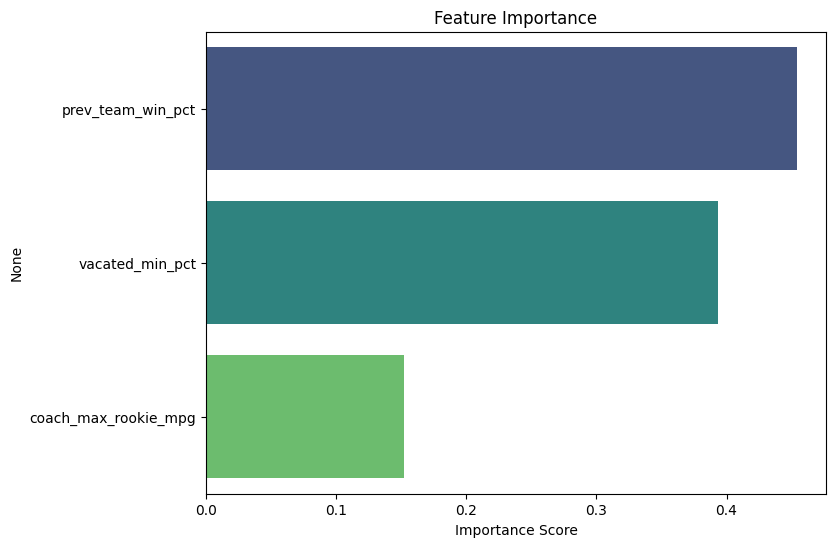

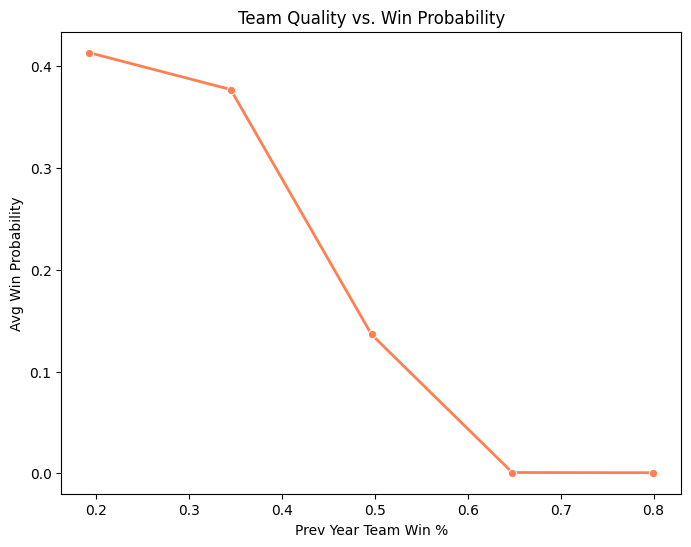

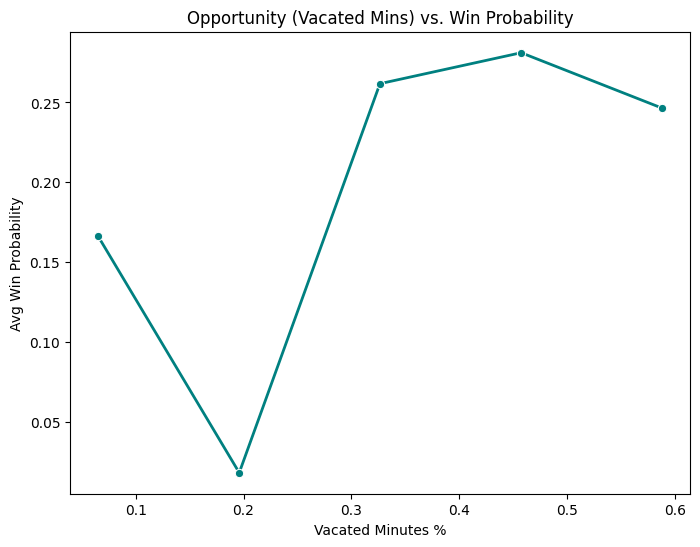

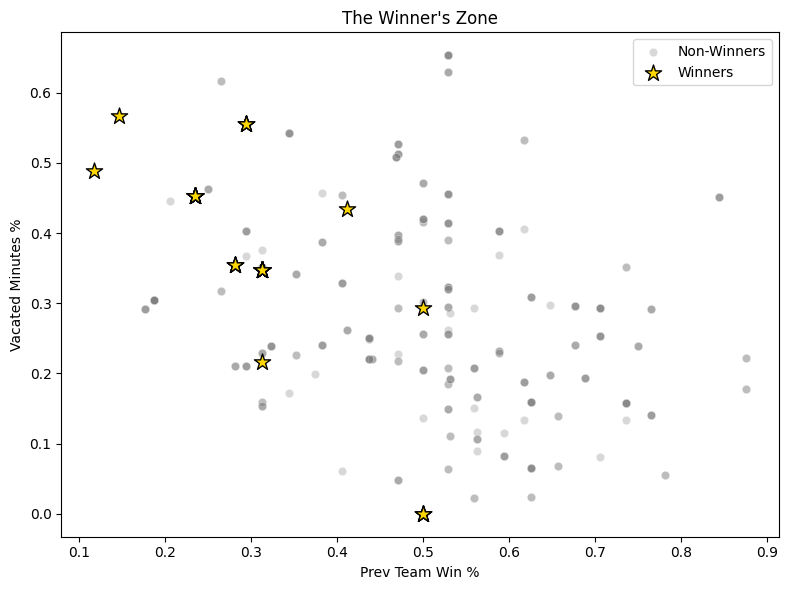

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# ============================================================
# 1. LOAD DATA
# ============================================================
df_roy = pd.read_csv('../dataset_for_modeling/rookie_of_year_features.csv')
df_players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')
df_awards_players = pd.read_csv('../dataset_cleaned/awards_players.csv')
df_teams_post = pd.read_csv('../dataset_cleaned/teams_post.csv')

df_rookies = df_roy[df_roy['is_rookie'] == 1].copy()

# ============================================================
# 2. FEATURE ENGINEERING — SINGLE CLEAN PIPELINE
# ============================================================

years = sorted(df_teams['year'].unique())
teams_list = df_teams['tmID'].unique()

# ------------------------------------------------------------
# A) Previous team success (proxy for draft position)
# ------------------------------------------------------------
df_teams['prev_year'] = df_teams['year'] + 1
df_teams['win_pct'] = df_teams['won'] / (df_teams['won'] + df_teams['lost'])

df_rookies = pd.merge(
    df_rookies,
    df_teams[['prev_year', 'tmID', 'win_pct', 'rank']],
    left_on=['year', 'tmID'],
    right_on=['prev_year', 'tmID'],
    how='left'
)

df_rookies.rename(columns={
    'win_pct': 'prev_team_win_pct',
    'rank': 'prev_team_rank'
}, inplace=True)

df_rookies['prev_team_win_pct'] = df_rookies['prev_team_win_pct'].fillna(0.5)

# ------------------------------------------------------------
# B) Vacated minutes (opportunity)
# ------------------------------------------------------------
rosters = df_players_teams.groupby(
    ['year', 'tmID', 'playerID']
)['minutes'].sum().reset_index()

vacated_data = []
for yr in years:
    if yr == 1:
        continue
    for tm in teams_list:
        prev_ros = rosters[(rosters['year'] == yr - 1) & (rosters['tmID'] == tm)]
        curr_ros = rosters[(rosters['year'] == yr) & (rosters['tmID'] == tm)]

        if prev_ros.empty:
            vac_pct = 0
        else:
            returning = set(curr_ros['playerID'])
            leavers = prev_ros[~prev_ros['playerID'].isin(returning)]
            total_prev = prev_ros['minutes'].sum()
            vac_pct = leavers['minutes'].sum() / total_prev if total_prev > 0 else 0

        vacated_data.append({'year': yr, 'tmID': tm, 'vacated_min_pct': vac_pct})

df_vacated = pd.DataFrame(vacated_data)

df_rookies = pd.merge(df_rookies, df_vacated, on=['year', 'tmID'], how='left')
df_rookies['vacated_min_pct'] = df_rookies['vacated_min_pct'].fillna(0)

# ------------------------------------------------------------
# C) Coach rookie usage history
# ------------------------------------------------------------
coaches_dedup = df_coaches.sort_values('stint').groupby(
    ['year', 'tmID']).last().reset_index()

rookie_ids = df_rookies[['year', 'playerID']].drop_duplicates()
rookie_ids['is_rookie_flag'] = 1

df_pt_roy = pd.merge(df_players_teams, rookie_ids,
                     on=['year', 'playerID'], how='left')
df_pt_roy['is_rookie_flag'] = df_pt_roy['is_rookie_flag'].fillna(0)

df_pt_roy = pd.merge(df_pt_roy, coaches_dedup[['year', 'tmID', 'coachID']],
                     on=['year', 'tmID'], how='left')

coach_stats = []
all_coaches = df_pt_roy['coachID'].dropna().unique()

for coach in all_coaches:
    coach_data = df_pt_roy[df_pt_roy['coachID'] == coach]

    for yr in years:
        hist = coach_data[coach_data['year'] < yr]

        if not hist.empty:
            rookies_hist = hist[hist['is_rookie_flag'] == 1]
            max_mpg = (rookies_hist['minutes'] / rookies_hist['GP']).max() if not rookies_hist.empty else 0
        else:
            max_mpg = 15

        coach_stats.append({
            'year': yr,
            'coachID': coach,
            'coach_max_rookie_mpg': max_mpg
        })

df_coach_stats = pd.DataFrame(coach_stats)

df_rookies = pd.merge(df_rookies, coaches_dedup[['year', 'tmID', 'coachID']],
                      on=['year', 'tmID'], how='left')

df_rookies = pd.merge(df_rookies, df_coach_stats,
                      on=['year', 'coachID'], how='left')

df_rookies['coach_max_rookie_mpg'] = df_rookies['coach_max_rookie_mpg'].fillna(15)

# ------------------------------------------------------------
# D) College analysis
# ------------------------------------------------------------
df_rookies['college'] = df_rookies['college'].astype(str).str.strip()

# ------------------------------------------------------------
# E) Awards
# ------------------------------------------------------------
df_rookies = pd.merge(df_rookies, df_awards_players[['playerID', 'award']],
                      on='playerID', how='left')

df_rookies['has_won_award'] = df_rookies['award'].notna().astype(int)

# ------------------------------------------------------------
# F) Postseason participation
# ------------------------------------------------------------
df_rookies = pd.merge(df_rookies, df_teams_post[['year', 'tmID', 'W']],
                      on=['year', 'tmID'], how='left')

df_rookies['team_in_postseason'] = df_rookies['W'] > 0


# ============================================================
# 3. MODELING
# ============================================================

features = ['prev_team_win_pct', 'vacated_min_pct', 'coach_max_rookie_mpg']

df_model = df_rookies.dropna(subset=features + ['won_roy']).copy()

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42
)

rf.fit(df_model[features], df_model['won_roy'])

df_model['win_prob'] = rf.predict_proba(df_model[features])[:, 1]

df_rookies = pd.merge(
    df_rookies,
    df_model[['playerID', 'year', 'win_prob']],
    on=['playerID', 'year'],
    how='left'
)


# ============================================================
# 4. VISUALIZATION
# ============================================================

# Existing Graphs from the previous code:

# A) Previous Team Success
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.boxplot(x='won_roy', y='prev_team_win_pct', data=df_rookies, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Do Bad Teams produce ROY Winners?')
axes[0, 0].set_xlabel('Won ROY')
axes[0, 0].set_ylabel('Previous Team Win %')

# B) Vacated Minutes
sns.boxplot(x='won_roy', y='vacated_min_pct', data=df_rookies, ax=axes[0, 1], palette='coolwarm')
axes[0, 1].set_title('Does Opportunity (Vacated Mins) matter?')
axes[0, 1].set_xlabel('Won ROY')
axes[0, 1].set_ylabel('Vacated Minutes %')

# C) Coach History
sns.boxplot(x='won_roy', y='coach_max_rookie_mpg', data=df_rookies, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Does Coach History matter?')
axes[1, 0].set_xlabel('Won ROY')
axes[1, 0].set_ylabel('Coach Max Rookie MPG (History)')

college_counts = df_colleges_roi.groupby('college').agg(
    Total_Rookies=('playerID', 'count'),
    ROY_Winners=('won_roy', 'sum')
).sort_values('ROY_Winners', ascending=False)

sns.barplot(x=college_counts.index, y=college_counts['ROY_Winners'], ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('Colleges producing ROY Winners')
axes[1, 1].set_xlabel('College')
axes[1, 1].set_ylabel('Number of ROY Winners')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Additional Graphs you wanted (from the second code snippet):

# 1. Feature Importance
fig, ax = plt.subplots(figsize=(8, 6))
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index, palette='viridis', ax=ax)
ax.set_title('Feature Importance')
ax.set_xlabel('Importance Score')

# 2. Influence of Team Quality
df_viz = df_rookies.dropna(subset=['win_prob', 'prev_team_win_pct']).copy()
df_viz['win_pct_bin'] = pd.cut(df_viz['prev_team_win_pct'], bins=5)
prob_by_win = df_viz.groupby('win_pct_bin', observed=True)['win_prob'].mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=[b.mid for b in prob_by_win.index], y=prob_by_win.values, marker='o', color='coral', linewidth=2, ax=ax)
ax.set_title('Team Quality vs. Win Probability')
ax.set_xlabel('Prev Year Team Win %')
ax.set_ylabel('Avg Win Probability')

# 3. Influence of Opportunity
df_viz['vacated_bin'] = pd.cut(df_viz['vacated_min_pct'], bins=5)
prob_by_vac = df_viz.groupby('vacated_bin', observed=True)['win_prob'].mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(x=[b.mid for b in prob_by_vac.index], y=prob_by_vac.values, marker='o', color='teal', linewidth=2, ax=ax)
ax.set_title('Opportunity (Vacated Mins) vs. Win Probability')
ax.set_xlabel('Vacated Minutes %')
ax.set_ylabel('Avg Win Probability')

# 4. The "Winner's Zone"
winners = df_viz[df_viz['won_roy'] == 1]
non_winners = df_viz[df_viz['won_roy'] == 0]

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=non_winners, x='prev_team_win_pct', y='vacated_min_pct', alpha=0.3, color='gray', label='Non-Winners', ax=ax)
sns.scatterplot(data=winners, x='prev_team_win_pct', y='vacated_min_pct', s=150, color='gold', edgecolor='black', marker='*', label='Winners', ax=ax)
ax.set_title("The Winner's Zone")
ax.set_xlabel('Prev Team Win %')
ax.set_ylabel('Vacated Minutes %')

plt.tight_layout()
plt.show()


In [58]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

# Load Data
df_roy = pd.read_csv('../dataset_for_modeling/rookie_of_year_features.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
df_players = pd.read_csv('../dataset_cleaned/players.csv')
df_players_teams = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_coaches = pd.read_csv('../dataset_cleaned/coaches.csv')

# 1. Filter Rookies
df_rookies = df_roy[df_roy['is_rookie'] == 1].copy()

# 2. Add Age, Height, Weight, and College from players.csv
df_rookies = pd.merge(df_rookies, df_players[['bioID', 'birthDate', 'pos', 'college']], 
                      left_on='playerID', right_on='bioID', how='left')

# Calculate Age
def calculate_age(row):
    try:
        birth_year = int(str(row['birthDate'])[:4])
        current_year = 1996 + row['year']  # Relative year based on the starting point
        return current_year - birth_year
    except:
        return 22  # Default rookie age if no birthdate

df_rookies['age'] = df_rookies.apply(calculate_age, axis=1)

# Process Position (One-Hot or Factorize)
df_rookies['pos_simple'] = df_rookies['pos_y'].str[0]  # Extracting the first letter of the position
df_rookies['pos_code'] = pd.factorize(df_rookies['pos_simple'])[0]

# 3. Add Context Features (from previous step)
# Win Pct
df_teams['prev_year'] = df_teams['year'] + 1
df_teams['win_pct'] = df_teams['won'] / (df_teams['won'] + df_teams['lost'])
df_rookies = pd.merge(df_rookies, df_teams[['prev_year', 'tmID', 'win_pct']], 
                      left_on=['year', 'tmID'], right_on=['prev_year', 'tmID'], how='left')
df_rookies.rename(columns={'win_pct': 'prev_team_win_pct'}, inplace=True)
df_rookies['prev_team_win_pct'] = df_rookies['prev_team_win_pct'].fillna(0.5)

# Vacated Mins
rosters = df_players_teams.groupby(['year', 'tmID', 'playerID'])['minutes'].sum().reset_index()
vacated_data = []
teams_list = df_teams['tmID'].unique()
years = sorted(df_teams['year'].unique())

for yr in years:
    if yr == 1: continue
    for tm in teams_list:
        ros_prev = rosters[(rosters['year'] == yr - 1) & (rosters['tmID'] == tm)]
        ros_curr = rosters[(rosters['year'] == yr) & (rosters['tmID'] == tm)]
        if ros_prev.empty: vacated_pct = 0
        else:
            returning_ids = set(ros_curr['playerID'])
            leavers = ros_prev[~ros_prev['playerID'].isin(returning_ids)]
            vacated_pct = leavers['minutes'].sum() / ros_prev['minutes'].sum() if ros_prev['minutes'].sum() > 0 else 0
        vacated_data.append({'year': yr, 'tmID': tm, 'vacated_min_pct': vacated_pct})
df_vacated = pd.DataFrame(vacated_data)
df_rookies = pd.merge(df_rookies, df_vacated, on=['year', 'tmID'], how='left')
df_rookies['vacated_min_pct'] = df_rookies['vacated_min_pct'].fillna(0)

# Rank Feature
if 'rank' not in df_rookies.columns:
    df_rookies = pd.merge(df_rookies, df_teams[['year', 'tmID', 'rank']], on=['year', 'tmID'], how='left')
df_rookies['team_rank_feature'] = df_rookies['rank'].fillna(4)

# 4. New Feature Set (including College)
features_enhanced = [
    'prev_team_win_pct', 'vacated_min_pct', 
    'team_rank_feature', 'age', 'height', 
    'weight', 'pos_code'
]

# Label Encoding for the 'college' feature
label_encoder = LabelEncoder()

# Make sure 'college_y' exists and encode it
df_rookies['college_encoded'] = label_encoder.fit_transform(df_rookies['college_y'].astype(str))

# Fill NA for physical stats
df_rookies['height'] = df_rookies['height'].fillna(df_rookies['height'].mean())
df_rookies['weight'] = df_rookies['weight'].fillna(df_rookies['weight'].mean())

# Add the 'college_encoded' feature to the list of features
features_enhanced.append('college_encoded')

# 5. Validation (Year 9)
print("Enhanced Model Validation (Year 9)...")
train_val = df_rookies[(df_rookies['year'] >= 2) & (df_rookies['year'] < 9)].dropna(subset=features_enhanced)
test_val = df_rookies[df_rookies['year'] == 9].dropna(subset=features_enhanced).copy()

rf_val = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf_val.fit(train_val[features_enhanced], train_val['won_roy'])

test_val['prob'] = rf_val.predict_proba(test_val[features_enhanced])[:, 1]
top_candidates = test_val.sort_values('prob', ascending=False).head(10)
results_y9 = test_val.sort_values('prob', ascending=False).reset_index(drop=True)
results_y9['predicted_rank'] = results_y9.index + 1

print("Actual Winner Rank (Enhanced):")
print(results_y9[results_y9['won_roy'] == 1][['playerID', 'predicted_rank', 'prob', 'age', 'height']])

print("Top 5 Candidates (Year 10):")
print(top_candidates[['playerID', 'tmID', 'prob', 'age', 'height', 'pos_simple', 'college_y']])  # Changed to 'college_y'

# 6. Prediction (Year 10)
print("\nEnhanced Prediction (Year 10)...")
train_full = df_rookies[(df_rookies['year'] >= 2) & (df_rookies['year'] < 10)].dropna(subset=features_enhanced)
test_future = df_rookies[df_rookies['year'] == 10].dropna(subset=features_enhanced).copy()

rf_full = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf_full.fit(train_full[features_enhanced], train_full['won_roy'])

test_future['prob'] = rf_full.predict_proba(test_future[features_enhanced])[:, 1]
top_candidates = test_future.sort_values('prob', ascending=False).head(10)

print("Top 5 Candidates (Year 10):")
print(top_candidates[['playerID', 'tmID', 'prob', 'age', 'height', 'pos_simple', 'college_y']])  # Changed to 'college_y'

# Check Feature Importance
imp = pd.Series(rf_full.feature_importances_, index=features_enhanced).sort_values(ascending=False)
print("\nEnhanced Feature Importance:")
print(imp)

# Ensure no NaNs in features
df_rookies_model = df_rookies.dropna(subset=features_enhanced).copy()

WINDOW = 4
predictions = []
target = 'won_roy'

print(f"--- STARTING ROY FORECAST (Window={WINDOW}) ---")
print(f"Features: {features_enhanced}")

# Loop years 5 to 10
for test_year in range(5, 11):
    start_train = test_year - WINDOW
    
    train = df_rookies_model[(df_rookies_model['year'] >= start_train) & (df_rookies_model['year'] < test_year)].copy()
    test = df_rookies_model[df_rookies_model['year'] == test_year].copy()
    
    if train.empty or test.empty:
        print(f"Skipping Year {test_year}: No Data")
        continue
    
    # Check if we have positive cases in training
    if train[target].sum() == 0:
        print(f"Skipping Year {test_year}: No winners in training set")
        continue

    # Train
    rf = RandomForestClassifier(
        n_estimators=500, 
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1,
        max_depth=6 # Restrict depth for small rookie datasets to avoid overfitting
    )
    rf.fit(train[features_enhanced], train[target])
    
    # Predict
    test['prob'] = rf.predict_proba(test[features_enhanced])[:, 1]
    
    # Store
    cols_out = ['playerID', 'tmID', 'year', 'prob', 'won_roy', 'age', 'college_encoded', 'vacated_min_pct']
    predictions.append(test[cols_out])

# --- 5. RESULTS ---

if predictions:
    df_preds = pd.concat(predictions, ignore_index=True)
    
    # Rank
    df_preds['rank'] = df_preds.groupby('year')['prob'].rank(ascending=False, method='first')
    
    # AUC
    try:
        auc = roc_auc_score(df_preds[target], df_preds['prob'])
        print(f"\nOverall ROC AUC: {auc:.4f}")
    except:
        print("AUC Error")
        
    # Show Winners vs Predicted Rank
    print("\n>>> Actual ROY Winners & Model Ranks:")
    winners = df_preds[df_preds['won_roy'] == 1]
    print(winners[['year', 'playerID', 'tmID', 'rank', 'prob', 'vacated_min_pct', 'age']].sort_values('year'))
    
    # Show Top Candidates for each year
    print("\n>>> Top 5 Predicted Rookies (Years 5-10):")
    print(df_preds[df_preds['rank'] <= 5].sort_values(['year', 'rank'])[['year', 'playerID', 'tmID', 'rank', 'prob', 'vacated_min_pct', 'college_encoded']])

else:
    print("No predictions generated.")


Enhanced Model Validation (Year 9)...
Actual Winner Rank (Enhanced):
     playerID  predicted_rank   prob  age  height
4  parkeca01w               5  0.084   19    76.0
Top 5 Candidates (Year 10):
       playerID tmID   prob  age  height pos_simple          college_y
221  houstch01w  MIN  0.372   19    72.0          F        Connecticut
513  whiteer01w  HOU  0.222   19    63.0          G    Louisiana State
175  gisseka01w  LAS  0.170   20    73.0          F         Penn State
50   bobbish01w  LAS  0.148   20    62.0          G          Tennessee
368  parkeca01w  LAS  0.084   19    76.0          F          Tennessee
266  langhcr01w  WAS  0.082   19    74.0          F           Maryland
89   chanequ01w  CHI  0.076   19    71.0          G    Louisiana State
36    beckki01w  SEA  0.066   20    68.0          G  George Washington
521  wiggica01w  MIN  0.062   18    71.0          G           Stanford
14   anosini01w  MIN  0.046   19    75.0          C          Tennessee

Enhanced Prediction (

#### Kim Perrot Sportsmanship Award

In [22]:
import pandas as pd
import numpy as np

# Load Data
kpsa_df = pd.read_csv('../dataset_for_modeling/kim_perrot_sportsmanship_award_features.csv')
players = pd.read_csv("../dataset_cleaned/players.csv")
players_teams = pd.read_csv("../dataset_cleaned/players_teams.csv")

# -------------------------------------------------------------------------
# Feature Engineering
# -------------------------------------------------------------------------

# --- Age Proxy (Logarithmic) ---
players['birthDate'] = pd.to_datetime(players['birthDate'], errors='coerce')
players['birth_year'] = players['birthDate'].dt.year

kpsa_df = kpsa_df.merge(players[['bioID', 'birth_year', 'pos']], left_on='playerID', right_on='bioID', how='left')
kpsa_df['age_raw'] = 2025 - kpsa_df['birth_year']
# Use Log to smooth the impact of age (diminishing returns for very old players)
kpsa_df['age_proxy'] = np.log(kpsa_df['age_raw']) 
kpsa_df['age_proxy'] = kpsa_df['age_proxy'].fillna(kpsa_df['age_proxy'].mean())

# --- Position (Guard) ---
kpsa_df['is_guard'] = kpsa_df['pos'].str.contains('G', na=False).astype(int)

# --- Team Tenure (Loyalty) ---
kpsa_df = kpsa_df.sort_values(['playerID', 'year'])
kpsa_df['team_tenure'] = kpsa_df.groupby(['playerID', 'tmID']).cumcount() + 1

# Consolidate stats from players_teams (GS, GP, Steals, Blocks, PF, Minutes)
pt_stats = players_teams.groupby(['playerID', 'year', 'tmID'])[[
    'GS', 'GP', 'steals', 'blocks', 'PF', 'minutes'
]].sum().reset_index()

kpsa_df = kpsa_df.merge(pt_stats, on=['playerID', 'year', 'tmID'], how='left')

# --- Starter Ratio ---
# Measure of starter status (0.0 to 1.0)
kpsa_df['starter_ratio'] = kpsa_df['GS'] / (kpsa_df['GP'] + 1)
kpsa_df['starter_ratio'] = kpsa_df['starter_ratio'].fillna(0)

# --- Clean Defense Ratio ---
# (Steals + Blocks) / (Fouls + 1) -> Square Root to smooth outliers
kpsa_df['clean_defense'] = (kpsa_df['steals'] + kpsa_df['blocks']) / (kpsa_df['PF'] + 1)
kpsa_df['clean_defense'] = kpsa_df['clean_defense'].fillna(0)
kpsa_df['clean_defense'] = np.sqrt(kpsa_df['clean_defense'])

# --- Minutes Per Game ---
# Volume measure -> Log to reduce gap between stars and rotation players
kpsa_df['minutes_per_game'] = kpsa_df['minutes'] / (kpsa_df['GP'] + 1)
kpsa_df['minutes_per_game'] = kpsa_df['minutes_per_game'].fillna(0)
kpsa_df['minutes_per_game'] = np.log1p(kpsa_df['minutes_per_game'])

kpsa_df.fillna(0, inplace=True)

# -------------------------------------------------------------------------
# Comparison Analysis: Winner vs League Average
# -------------------------------------------------------------------------

all_stats_columns = [
    "fouls_per_game", "fouls_per_36", "disqualifications",
    "assist_to_turnover", "turnovers_per_game", "turnovers_per_36",
    "assists_per_game", "assists_per_36", "positive_actions",
    "positive_actions_per_game",
    "in_team_fouls_pct", "in_team_to_pct", "in_team_ast_pct", "in_team_dq_pct",
    "stint", "age_proxy", "is_guard", "starter_ratio", "team_tenure", 
    "clean_defense", "minutes_per_game"
]

yearly_means = kpsa_df.groupby('year')[all_stats_columns].mean()
winners = kpsa_df[kpsa_df['is_kpsa'] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    player_id = winners.loc[year, 'playerID']
    tm_id = winners.loc[year, 'tmID']
    
    print(f"\n----------------------------------------------------------------")
    print(f"YEAR {year}: Winner {player_id} ({tm_id})")
    print(f"----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>8} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 65)
    
    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]
        
        # Calculate percentage difference
        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100
            
        print(f"{col:<30} | {val_winner:>8.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")

# -------------------------------------------------------------------------
# Feature Groups Definition
# -------------------------------------------------------------------------

# Features that change every year (require history/lags)
dynamic_features = [
    'fouls_per_36', 'disqualifications', 'assist_to_turnover',
    'turnovers_per_game', 'turnovers_per_36', 'positive_actions',
    'in_team_ast_pct', 'in_team_to_pct', 'assists_per_game',
    'starter_ratio', 'stint', 'minutes_per_game', 'clean_defense'
]

# Features that are known/static at the start of the season
static_features = [
    'age_proxy', 'is_guard', 'team_tenure'
]



=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: Winner mcconsu01w (CLE)
----------------------------------------------------------------
FEATURE                        |   WINNER | LEAGUE AVG |     DIFF %
-----------------------------------------------------------------
fouls_per_game                 |     0.94 |       1.88 |     -50.2%
fouls_per_36                   |     1.53 |       4.39 |     -65.1%
disqualifications              |     0.00 |       0.50 |    -100.0%
assist_to_turnover             |     1.70 |       0.89 |     +90.6%
turnovers_per_game             |     2.16 |       1.38 |     +55.8%
turnovers_per_36               |     3.52 |       2.93 |     +20.1%
assists_per_game               |     3.72 |       1.38 |    +169.1%
assists_per_36                 |     6.08 |       2.67 |    +127.7%
positive_actions               |   185.00 |     140.21 |     +31.9%
positive_actions_per_game  

In [23]:
# Initialize feature lists
z_features_dynamic = []
z_features_static = []

# ---------------------------------------------------------
# Standardization (Z-Scores)
# ---------------------------------------------------------

# Helper lambda for robust Z-score (avoids division by zero)
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

# Calculate Z-scores for Dynamic Features (grouped by year)
for col in dynamic_features:
    new_col = f"z_{col}"
    kpsa_df[new_col] = kpsa_df.groupby('year')[col].transform(get_z_score)
    z_features_dynamic.append(new_col)

# Calculate Z-scores for Static Features (grouped by year)
for col in static_features:
    new_col = f"z_{col}"
    kpsa_df[new_col] = kpsa_df.groupby('year')[col].transform(get_z_score)
    z_features_static.append(new_col)

# Sort ensures time-series operations (shift/rolling) are correct
kpsa_df = kpsa_df.sort_values(['playerID', 'year'])

# ---------------------------------------------------------
# Dynamic Feature Engineering
# ---------------------------------------------------------

# Create Lag-1 Features
lag_cols = [f"{col}_lag1" for col in z_features_dynamic]
kpsa_df[lag_cols] = kpsa_df.groupby('playerID')[z_features_dynamic].shift(1)

# Create 3-Year Weighted Rolling Average
def weighted_avg_robust(series):
    """
    Calculates a weighted average for a window size up to 3.
    Weights: 0.2 (t-2), 0.3 (t-1), 0.5 (t).
    Handles NaN values by re-normalizing weights.
    """
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    
    # Adjust weights if the window is smaller than 3 (e.g., start of career)
    w = weights[-len(s):]
    
    mask = ~np.isnan(s)
    if not np.any(mask): 
        return np.nan
        
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

# Define names for the average columns
avg_cols = [f"{col}_avg3yr" for col in z_features_dynamic]

# Apply rolling window on the LAGGED columns
rolling_stats = kpsa_df.groupby('playerID')[lag_cols] \
                       .rolling(window=3, min_periods=1) \
                       .apply(weighted_avg_robust, raw=True)

# Align index to assign back to dataframe
kpsa_df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

current_static_cols = z_features_static

# Remove rows where historical performance data (Lags) is missing
model_df_c = kpsa_df.dropna(subset=lag_cols)

# Combine all features: Performance History + Current Context
features_final_c = lag_cols + avg_cols + current_static_cols
target_c = 'is_kpsa'


In [24]:
# ---------------------------------------------------------
# Temporal split + baseline
# ---------------------------------------------------------
train_df = model_df_c[model_df_c["year"] < 9]
val_df   = model_df_c[model_df_c["year"] == 9]
test_df  = model_df_c[model_df_c["year"] == 10]

X_train, y_train = train_df[features_final_c], train_df[target_c]
X_val,   y_val   = val_df[features_final_c],   val_df[target_c]
X_test,  y_test  = test_df[features_final_c],  test_df[target_c]

print(f"Training Samples: {len(X_train)} | Winners in Train: {y_train.sum()}")

K = 5

def build_baseline_score(df):
    score = (
        -df["z_fouls_per_36_lag1"].fillna(0) * 0.5
        -df["z_turnovers_per_36_lag1"].fillna(0) * 0.3
        +df["z_assist_to_turnover_lag1"].fillna(0) * 0.2
    )
    return score

val_baseline = val_df[["playerID", "tmID", "is_kpsa"]].copy()
val_baseline["baseline_score"] = build_baseline_score(val_df)
val_baseline = val_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 9) ---")
print(val_baseline.head(K).to_string(index=False))

if (val_baseline["is_kpsa"] == 1).any():
    kpsa_rank_baseline_val = val_baseline.index.get_loc(
        val_baseline[val_baseline["is_kpsa"] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (validation): #{kpsa_rank_baseline_val}")

test_baseline = test_df[["playerID", "tmID", "is_kpsa"]].copy()
test_baseline["baseline_score"] = build_baseline_score(test_df)
test_baseline = test_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 10) ---")
print(test_baseline.head(K).to_string(index=False))

if (test_baseline["is_kpsa"] == 1).any():
    kpsa_rank_baseline_test = test_baseline.index.get_loc(
        test_baseline[test_baseline["is_kpsa"] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (test): #{kpsa_rank_baseline_test}")
    

Training Samples: 1030 | Winners in Train: 7

--- Baseline ranking (Year 9) ---
  playerID tmID  is_kpsa  baseline_score
johnsvi01w  SAS        1        1.204234
smithcr01w  WAS        0        1.184561
sharpkb01w  CHI        0        0.998789
 birdsu01w  SEA        0        0.952433
philler01w  CON        0        0.935662
Baseline winner rank (validation): #1

--- Baseline ranking (Year 10) ---
  playerID tmID  is_kpsa  baseline_score
johnsvi01w  SAS        0        1.199254
hodgero01w  MIN        0        1.192183
 mannkr01w  WAS        0        1.122632
mazzake01w  PHO        0        1.121518
deforan01w  DET        0        1.064676
Baseline winner rank (test): #14


In [25]:
def summarize_kpsa_errors(bestvalresults, finalresultstest, top_k=5):
    print("\n=== Kim Perrot Award – Error Analysis ===")

    for label, df, year in [
        ("Validation", bestvalresults, 9),
        ("Test",        finalresultstest, 10),
    ]:
        tmp = df.copy()
        tmp["model_rank"] = tmp["prob_winning"].rank(
            method="first", ascending=False
        ).astype(int)

        winner = tmp[tmp["is_kpsa"] == 1]
        if winner.empty:
            print(f"\n{label} year {year}: winner not in candidate set.")
            continue

        winner_rank = int(winner["model_rank"].iloc[0])
        winner_prob = float(winner["prob_winning"].iloc[0])

        print(f"\n{label} year {year}:")
        print(f"  Winner rank = {winner_rank}")
        print(f"  Winner prob = {winner_prob:.3f}")
        print(f"  Top-{top_k} hit? {winner_rank <= top_k}")

        false_pos = (
            tmp[tmp["is_kpsa"] == 0]
            .sort_values("prob_winning", ascending=False)
            .head(top_k)
        )
        print(f"\n  Top-{top_k} false positives ({label}):")
        print(false_pos[["playerID", "tmID", "prob_winning", "model_rank"]]
              .to_string(index=False))


In [26]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search)
# ---------------------------------------------------------
model_configs = {
    "RandomForest_no_scaler": {
        "model": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "RandomForest_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "GradientBoosting_no_scaler": {
        "model": Pipeline([
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 4]
        }
    },

    "GradientBoosting_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 4]
        }
    },

    "LogisticRegression_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

tuned_models = []

print(f"\n--- Grid Search on TRAIN only (years < 9) for {len(model_configs)} models ---")

for name, config in model_configs.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_auc = grid.best_score_
    print(f"  > Best ROC AUC (CV on train): {best_auc:.4f}")
    print(f"  > Best Params: {grid.best_params_}")

    tuned_models.append({
        "Model": name,
        "CV AUC (train)": best_auc,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })

tuned_df = pd.DataFrame(tuned_models).sort_values(by="CV AUC (train)", ascending=False)
print("\n--- Tuned models (CV on train) ---")
print(tuned_df[["Model", "CV AUC (train)", "Best_Params"]].to_string(index=False))



--- Grid Search on TRAIN only (years < 9) for 5 models ---

Training RandomForest_no_scaler...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.8936
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Training RandomForest_scaled...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.8936
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Training GradientBoosting_no_scaler...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
  > Best ROC AUC (CV on train): 0.9571
  > Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}

Training GradientBoosting_scaled...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
  > Best ROC AUC (CV on train): 0.9571
  >

In [30]:
# ---------------------------------------------------------
# Validation Analysis (Year 9)
# ---------------------------------------------------------
val_results = []

print("\n--- Validation performance (Year 9) for tuned models ---")

for row in tuned_models:
    name = row["Model"]
    model = row["Best_Estimator"]

    probs_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, probs_val)
    val_ap = average_precision_score(y_val, probs_val)

    tmp = val_df[["playerID", "tmID", "is_kpsa"]].copy()
    tmp["prob_winning"] = probs_val
    tmp = tmp.sort_values("prob_winning", ascending=False)

    top_k = tmp.head(K)
    hit_k = int(top_k["is_kpsa"].any())

    val_results.append({
        "Model": name,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        f"Top-{K} hit (val)": hit_k,
        "Estimator": model,
        "Results_Val": tmp
    })

val_df_models = pd.DataFrame(val_results).sort_values(by="Val AUC", ascending=False)

print("\n--- Model ranking on Validation (Year 9) ---")
print(val_df_models[["Model", "Val AUC", "Val AP", f"Top-{K} hit (val)"]].to_string(index=False))

best_val_row = val_df_models.iloc[0]
best_val_model_name = best_val_row["Model"]
best_val_model = best_val_row["Estimator"]
best_val_results = best_val_row["Results_Val"]

print(f"\nBest model on validation: {best_val_model_name}")

print("\n--- Validation Results (Year 9) ---")
print("Top 5 Favorites Predicted by Model:")
print(best_val_results.head(5).to_string(index=False))

actual_winner_row = best_val_results[best_val_results["is_kpsa"] == 1]
if not actual_winner_row.empty:
    winner_rank = best_val_results.index.get_loc(actual_winner_row.index[0]) + 1
    winner_name = actual_winner_row["playerID"].values[0]
    winner_prob = actual_winner_row.iloc[0]["prob_winning"]
    top_prob = best_val_results.iloc[0]["prob_winning"]

    print(f"\nActual Winner ({winner_name}) Rank: #{winner_rank}")
    print(f"Winner Probability: {winner_prob:.4f} (Top Favorite: {top_prob:.4f})")
else:
    print("\nActual Winner not found in validation set.")

# ---------------------------------------------------------
# Retraining (Train + Val) -> Prediction (Test Year 10)
# ---------------------------------------------------------
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_comparison = []

print("\n--- Evaluating tuned models retrained on TRAIN+VAL ---")

for row in tuned_models:
    name = row["Model"]
    estimator = row["Best_Estimator"]

    estimator.fit(X_train_full, y_train_full)
    probs_test = estimator.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, probs_test)
    test_ap = average_precision_score(y_test, probs_test)

    results_test_tmp = test_df[["playerID", "tmID", "is_kpsa"]].copy()
    results_test_tmp["prob_winning"] = probs_test
    results_test_tmp = results_test_tmp.sort_values("prob_winning", ascending=False)

    top_k = results_test_tmp.head(K)
    hit_k = int(top_k["is_kpsa"].any())

    final_comparison.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        f"Top-{K} hit (test)": hit_k,
        "Results_Test": results_test_tmp,
        "Estimator": estimator
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) ---")
print(comparison_df[["Model", "Test AUC", "Test AP", f"Top-{K} hit (test)"]].to_string(index=False))

# ---------------------------------------------------------
# Soft-voting ensemble of top KPSA models (Year 10)
# ---------------------------------------------------------
topN = 3  # number of best models to ensemble
top_models = comparison_df.head(topN)

probs_list = []
weights = []

for _, row in top_models.iterrows():
    est = row["Estimator"]
    auc = row["Test AUC"]
    
    # Predict probabilities on the same X_test
    p = est.predict_proba(X_test)[:, 1]
    probs_list.append(p)
    
    # Use Test AUC as weight (better models get higher weight)
    weights.append(auc)

probs_array = np.vstack(probs_list)  # shape: (topN, n_candidates)
weights = np.array(weights)
weights = weights / weights.sum()    # normalize

# Weighted-average ensemble probabilities
probs_ens = np.average(probs_array, axis=0, weights=weights)

# Metrics on test (Year 10)
test_auc_ens = roc_auc_score(y_test, probs_ens)
test_ap_ens = average_precision_score(y_test, probs_ens)

print("\n=== Soft-voting ensemble on Test (Year 10) – KPSA ===")
print(f"Ensemble Test AUC: {test_auc_ens:.4f}")
print(f"Ensemble Test AP:  {test_ap_ens:.4f}")

# Build ensemble ranking dataframe
ensemble_results_test = test_df[["playerID", "tmID", target_c]].copy()
ensemble_results_test["prob_winning"] = probs_ens
ensemble_results_test = ensemble_results_test.sort_values("prob_winning", ascending=False)

top_k_ens = ensemble_results_test.head(K)
hit_k_ens = int(top_k_ens[target_c].any())

print(f"\n--- Ensemble Top-{K} candidates (Year 10) ---")
print(ensemble_results_test.head(K).to_string(index=False))
print(f"Ensemble Top-{K} hit (test): {hit_k_ens}")

# Where did the actual winner land in the ensemble ranking?
actual_winner_ens = ensemble_results_test[ensemble_results_test[target_c] == 1]
if not actual_winner_ens.empty:
    winner_rank_ens = ensemble_results_test.index.get_loc(actual_winner_ens.index[0]) + 1
    winner_id_ens = actual_winner_ens["playerID"].values[0]
    winner_prob_ens = actual_winner_ens["prob_winning"].values[0]
    top_prob_ens = ensemble_results_test.iloc[0]["prob_winning"]
    
    print(f"\nEnsemble: Actual winner {winner_id_ens} rank (Year 10): #{winner_rank_ens}")
    print(f"Winner prob (ensemble): {winner_prob_ens:.4f} (Top prob: {top_prob_ens:.4f})")
else:
    print("\nEnsemble: actual winner not found in test set.")

best_row = comparison_df.iloc[0]
final_model_name = best_row["Model"]
final_model = best_row["Estimator"]
final_results_test = best_row["Results_Test"]

print(f"\nBest model on Test: {final_model_name}")

print("\n--- TEST PREDICTION (Year 10) ---")
print(f"Model's Top 5 Candidates ({final_model_name}):")
print(final_results_test.head(5).to_string(index=False))

# Check where the actual winner landed in the rankings (Year 10)
actual_test_winner_row = final_results_test[final_results_test["is_kpsa"] == 1]
if not actual_test_winner_row.empty:
    winner_rank_test = final_results_test.index.get_loc(actual_test_winner_row.index[0]) + 1
    winner_name_test = actual_test_winner_row["playerID"].values[0]
    winner_prob_test = actual_test_winner_row.iloc[0]["prob_winning"]
    top_prob_test = final_results_test.iloc[0]["prob_winning"]

    print(f"\nActual Winner ({winner_name_test}) Rank (Year 10): #{winner_rank_test}")
    print(f"Winner Probability: {winner_prob_test:.4f} (Top Favorite: {top_prob_test:.4f})")
else:
    print("\nActual Winner not found in test set.")

# ---------------------------------------------------------
# Generalization gap (model chosen on validation)
# ---------------------------------------------------------
val_row_for_best = val_df_models[val_df_models["Model"] == best_val_model_name].iloc[0]
val_auc_best = val_row_for_best["Val AUC"]
val_ap_best = val_row_for_best["Val AP"]

test_row_for_best_val = comparison_df[comparison_df["Model"] == best_val_model_name].iloc[0]
test_auc_best = test_row_for_best_val["Test AUC"]
test_ap_best = test_row_for_best_val["Test AP"]

print("\n--- Generalization gap (model chosen on validation) ---")
print(f"AUC gap (test - validation): {test_auc_best - val_auc_best:+.4f}")
print(f"AP gap  (test - validation): {test_ap_best - val_ap_best:+.4f}")

# ---------------------------------------------------------
# Error analysis summary (ranks + false positives)
# ---------------------------------------------------------
summarize_kpsa_errors(best_val_results, final_results_test, top_k=5)

# ---------------------------------------------------------
# Detailed Error Analysis (Head-to-Head)
# ---------------------------------------------------------
actual_test_winner_row = final_results_test[final_results_test["is_kpsa"] == 1]

if not actual_test_winner_row.empty:
    rank_10 = final_results_test.index.get_loc(actual_test_winner_row.index[0]) + 1
    print(f"\nYear 10 Real Winner Rank: #{rank_10}")

    winner_idx = actual_test_winner_row.index[0]
    favorite_idx = final_results_test.index[0]

    winner_id = actual_test_winner_row["playerID"].values[0]
    favorite_id = final_results_test.iloc[0]["playerID"]

    print(f"\n--- Head-to-Head: Actual Winner ({winner_id}) vs Model Favorite ({favorite_id}) ---")
    print("Comparing feature inputs (Positive Diff = Favorite has higher value):")

    comp_df = pd.DataFrame({
        f"WINNER ({winner_id})": X_test.loc[winner_idx],
        f"FAVORITE ({favorite_id})": X_test.loc[favorite_idx]
    })

    comp_df["Diff (Fav - Win)"] = comp_df.iloc[:, 1] - comp_df.iloc[:, 0]

    prob_row = pd.DataFrame({
        f"WINNER ({winner_id})": [actual_test_winner_row["prob_winning"].values[0]],
        f"FAVORITE ({favorite_id})": [final_results_test.iloc[0]["prob_winning"]],
        "Diff (Fav - Win)": [
            final_results_test.iloc[0]["prob_winning"] -
            actual_test_winner_row["prob_winning"].values[0]
        ]
    }, index=[">> PREDICTED PROBABILITY"])

    final_comp = pd.concat([prob_row, comp_df])
    print(final_comp.round(4))
else:
    print("\nActual Winner not found in test set.")
    


--- Validation performance (Year 9) for tuned models ---

--- Model ranking on Validation (Year 9) ---
                     Model  Val AUC  Val AP  Top-5 hit (val)
    RandomForest_no_scaler 1.000000     1.0                1
       RandomForest_scaled 1.000000     1.0                1
GradientBoosting_no_scaler 1.000000     1.0                1
   GradientBoosting_scaled 1.000000     1.0                1
 LogisticRegression_scaled 0.993333     0.5                1

Best model on validation: RandomForest_no_scaler

--- Validation Results (Year 9) ---
Top 5 Favorites Predicted by Model:
  playerID tmID  is_kpsa  prob_winning
johnsvi01w  SAS        1      0.730069
beviltu01w  IND        0      0.255321
swoopsh01w  SEA        0      0.184333
mcwilta01w  WAS        0      0.133690
mcwilta01w  DET        0      0.081853

Actual Winner (johnsvi01w) Rank: #1
Winner Probability: 0.7301 (Top Favorite: 0.7301)

--- Evaluating tuned models retrained on TRAIN+VAL ---

--- Final comparison on Test 


Top 15 Most Important Features (final model):
                    Feature  Importance
                z_age_proxy    0.332698
       z_clean_defense_lag1    0.081270
     z_starter_ratio_avg3yr    0.054735
     z_clean_defense_avg3yr    0.050113
  z_minutes_per_game_avg3yr    0.046548
              z_team_tenure    0.043225
      z_fouls_per_36_avg3yr    0.030178
        z_fouls_per_36_lag1    0.025713
  z_turnovers_per_36_avg3yr    0.023995
  z_positive_actions_avg3yr    0.023333
    z_assists_per_game_lag1    0.023061
    z_turnovers_per_36_lag1    0.022104
    z_minutes_per_game_lag1    0.021578
z_turnovers_per_game_avg3yr    0.020336
z_assist_to_turnover_avg3yr    0.018743


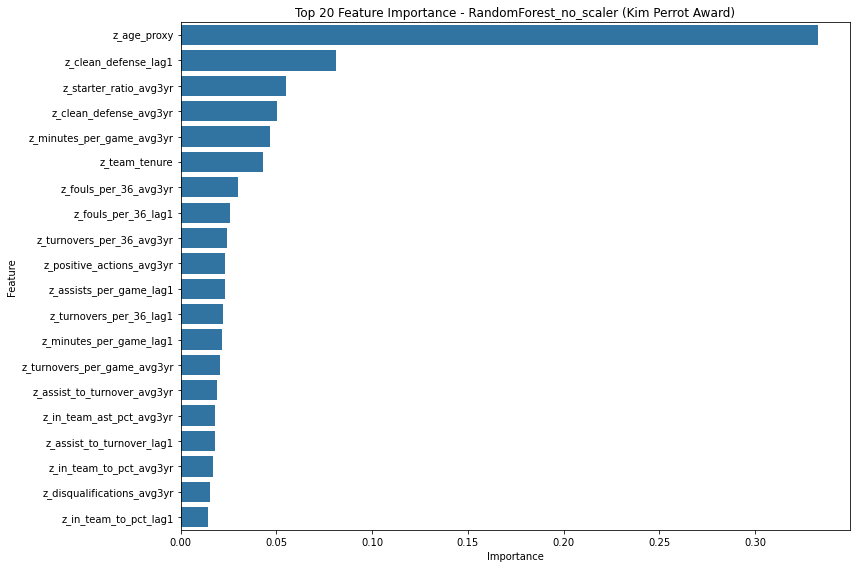

In [31]:
# ---------------------------------------------------------
# White-box logistic + feature importance of the final model
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

logistic_row = comparison_df[comparison_df["Model"] == "LogisticRegression"]
if not logistic_row.empty:
    logistic_estimator = logistic_row.iloc[0]["Estimator"]
    coefs = logistic_estimator.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features_final_c).sort_values(key=abs, ascending=False)

    print("\n=== Logistic Regression coefficients (white-box) ===")
    print(coef_series.head(15))

    plt.figure(figsize=(10, 6))
    coef_series.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 coefficients - Logistic Regression (KPSA)")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = features_final_c

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 15 Most Important Features (final model):")
    print(feature_importance_df.head(15).to_string(index=False))

    plt.figure(figsize=(12, 8))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=feature_importance_df.head(20)
    )
    plt.title(f"Top 20 Feature Importance - {final_model_name} (Kim Perrot Award)")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


In [49]:
# NEW APPROACH USING EXPADING WINDOW / ROLLING ORIGIN

from collections import defaultdict
from collections import Counter
from sklearn.model_selection import StratifiedKFold

model_configs = {
    "RandomForest_no_scaler": {
        "model": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "RandomForest_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "GradientBoosting_no_scaler": {
        "model": Pipeline([
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 4]
        }
    },

    "GradientBoosting_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GradientBoostingClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 4]
        }
    },

    "LogisticRegression_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

years = sorted(model_df_c["year"].unique())

min_year = 2
max_val_year = 9
splits = []

for val_year in range(3, max_val_year + 1):
    train_years = list(range(min_year, val_year))
    splits.append((train_years, val_year))

print("Rolling splits (train_years -> val_year):")
for tr, v in splits:
    print(tr, "->", v)

history = defaultdict(list)

# 1) Rolling tuning over years (expanding window)

for split_idx, (train_years, val_year) in enumerate(splits, start=1):
    print(f"\n=== Rolling Split {split_idx}: Train years {train_years} | Val year {val_year} ===")

    train_mask = model_df_c["year"].isin(train_years)
    val_mask   = model_df_c["year"] == val_year

    X_train_rs = model_df_c.loc[train_mask, features_final_c]
    y_train_rs = model_df_c.loc[train_mask, target_c]

    X_val_rs   = model_df_c.loc[val_mask, features_final_c]
    y_val_rs   = model_df_c.loc[val_mask, target_c]

    print(f"  Train size: {len(X_train_rs)}, Positives: {y_train_rs.sum()} | Val size: {len(X_val_rs)}")

    if len(X_val_rs) == 0 or y_val_rs.sum() == 0:
        print("  Skipping split (no positives or empty validation).")
        continue

    n_pos = int(y_train_rs.sum())
    n_neg = len(y_train_rs) - n_pos

    if n_pos < 3 or n_neg < 3:
        print("  Skipping split (not enough positives/negatives for 3-fold CV).")
        continue

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for name, config in model_configs.items():
        print(f"  > Tuning {name}...")

        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0,
            error_score=np.nan
        )
        grid.fit(X_train_rs, y_train_rs)

        best_estimator = grid.best_estimator_
        best_params    = grid.best_params_

        probs_val = best_estimator.predict_proba(X_val_rs)[:, 1]
        val_auc   = roc_auc_score(y_val_rs, probs_val)
        val_ap    = average_precision_score(y_val_rs, probs_val)

        print(f"    Split {split_idx} | Val year {val_year} | AUC={val_auc:.3f}")

        history[name].append({
            "split": split_idx,
            "val_year": val_year,
            "best_params": best_params,
            "val_auc": val_auc,
            "val_ap": val_ap
        })

# 2) Select hyperparameters per model based on rolling history

import pandas as pd
from collections import Counter

selected_configs = {}

for name, records in history.items():
    if not records:
        continue

    df_h = pd.DataFrame(records)
    df_h["params_str"] = df_h["best_params"].astype(str)

    freq = Counter(df_h["params_str"])
    mean_auc_by_params = df_h.groupby("params_str")["val_auc"].mean()

    best_params_str = None
    best_tuple = (-1, -1.0)  # (frequency, mean_auc)

    for p_str, count in freq.items():
        mean_auc = mean_auc_by_params[p_str]
        cand = (count, mean_auc)
        if cand > best_tuple:
            best_tuple = cand
            best_params_str = p_str

    chosen_row = df_h[df_h["params_str"] == best_params_str].iloc[0]
    chosen_params = chosen_row["best_params"]

    selected_configs[name] = {
        "chosen_params": chosen_params,
        "wins": best_tuple[0],
        "mean_auc": best_tuple[1]
    }

    print(f"\nModel {name}: chosen params used in {best_tuple[0]} splits, mean AUC={best_tuple[1]:.3f}")
    print(chosen_params)

# 3) Final training on years <= 9 and test on year 10

train_final_mask = model_df_c["year"] < 10
test_final_mask  = model_df_c["year"] == 10

X_train_final = model_df_c.loc[train_final_mask, features_final_c]
y_train_final = model_df_c.loc[train_final_mask, target_c]

X_test_final  = model_df_c.loc[test_final_mask, features_final_c]
y_test_final  = model_df_c.loc[test_final_mask, target_c]

final_results = []

from sklearn.base import clone

for name, info in selected_configs.items():
    print(f"\n=== Final training for {name} with rolling-selected params ===")

    base_pipeline = model_configs[name]["model"]
    estimator = clone(base_pipeline)
    estimator.set_params(**info["chosen_params"])

    estimator.fit(X_train_final, y_train_final)
    probs_test = estimator.predict_proba(X_test_final)[:, 1]

    test_auc = roc_auc_score(y_test_final, probs_test)
    test_ap  = average_precision_score(y_test_final, probs_test)

    res_df = model_df_c.loc[test_final_mask, ["playerID", "tmID", target_c]].copy()
    res_df["prob_winning"] = probs_test
    res_df = res_df.sort_values("prob_winning", ascending=False)

    final_results.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        "Results_Test": res_df,
        "wins": info["wins"],
        "mean_auc_cv": info["mean_auc"]
    })

final_comp_df = pd.DataFrame(final_results).sort_values(by="Test AUC", ascending=False)
print("\n--- Final comparison on Test (Year 10) using rolling-selected hyperparams ---")
print(final_comp_df[["Model", "wins", "mean_auc_cv", "Test AUC", "Test AP"]].to_string(index=False))


Rolling splits (train_years -> val_year):
[2] -> 3
[2, 3] -> 4
[2, 3, 4] -> 5
[2, 3, 4, 5] -> 6
[2, 3, 4, 5, 6] -> 7
[2, 3, 4, 5, 6, 7] -> 8
[2, 3, 4, 5, 6, 7, 8] -> 9

=== Rolling Split 1: Train years [2] | Val year 3 ===
  Train size: 146, Positives: 1 | Val size: 178
  Skipping split (not enough positives/negatives for 3-fold CV).

=== Rolling Split 2: Train years [2, 3] | Val year 4 ===
  Train size: 324, Positives: 2 | Val size: 149
  Skipping split (not enough positives/negatives for 3-fold CV).

=== Rolling Split 3: Train years [2, 3, 4] | Val year 5 ===
  Train size: 473, Positives: 3 | Val size: 127
  > Tuning RandomForest_no_scaler...
    Split 3 | Val year 5 | AUC=0.825
  > Tuning RandomForest_scaled...
    Split 3 | Val year 5 | AUC=0.825
  > Tuning GradientBoosting_no_scaler...
    Split 3 | Val year 5 | AUC=0.944
  > Tuning GradientBoosting_scaled...
    Split 3 | Val year 5 | AUC=0.944
  > Tuning LogisticRegression_scaled...
    Split 3 | Val year 5 | AUC=0.627

=== Roll

In [50]:
# Map model name -> full test results DataFrame (year 10)
results_by_model = {r["Model"]: r["Results_Test"] for r in final_results}

K = 10
for name, res_df in results_by_model.items():
    print(f"\n=== {name}: Top {K} predictions (Year 10) ===")
    print(res_df.head(K).to_string(index=False))

    true_winner_rows = res_df[res_df["is_kpsa"] == 1]

    if not true_winner_rows.empty:
        idx = true_winner_rows.index[0]
        rank = res_df.index.get_loc(idx) + 1
        player_id = true_winner_rows["playerID"].values[0]
        prob = true_winner_rows["prob_winning"].values[0]
        print(f"\n  -> True winner {player_id} rank: #{rank} (prob={prob:.4f})")
    else:
        print("\n  -> True winner not present in this model's candidate set.")



=== RandomForest_no_scaler: Top 10 predictions (Year 10) ===
  playerID tmID  is_kpsa  prob_winning
beviltu01w  IND        0      0.298957
mcwilta01w  DET        0      0.291061
johnsvi01w  SAS        0      0.288171
griffyo01w  IND        0      0.112250
penicti01w  SAC        0      0.103338
smithka01w  DET        0      0.063677
perkiji01w  CHI        0      0.049068
leslili01w  LAS        0      0.049048
mitchle01w  NYL        0      0.048496
johnssh01w  SEA        0      0.044646

  -> True winner lawsoka01w rank: #20 (prob=0.0222)

=== RandomForest_scaled: Top 10 predictions (Year 10) ===
  playerID tmID  is_kpsa  prob_winning
beviltu01w  IND        0      0.298957
mcwilta01w  DET        0      0.291061
johnsvi01w  SAS        0      0.288171
griffyo01w  IND        0      0.112250
penicti01w  SAC        0      0.103338
smithka01w  DET        0      0.063677
perkiji01w  CHI        0      0.049068
leslili01w  LAS        0      0.049048
mitchle01w  NYL        0      0.048496
johnssh

#### Defensive Player of the Year Award

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load Data
df = pd.read_csv('../dataset_for_modeling/defensive_player_of_year_features.csv')
teams = pd.read_csv('../dataset_cleaned/teams.csv')

teams['win_pct'] = teams['won'] / teams['GP']
teams['ppg_allowed'] = teams['d_pts'] / teams['GP']
teams['team_def_rank'] = teams.groupby('year')['ppg_allowed'].rank(ascending=True)

team_stats = teams[['year', 'tmID', 'win_pct', 'team_def_rank']]
df = df.merge(team_stats, on=['year', 'tmID'], how='left')

df = df.sort_values(['playerID', 'year'])
df['experience'] = df.groupby('playerID').cumcount()

# -------------------------------------------------------------------------
# Comparison Analysis: Winner vs League Average
# -------------------------------------------------------------------------
all_stats_columns = [
    "steals_per_game", "blocks_per_game", "def_reb_per_game",
    "steals_per_36", "blocks_per_36", "def_reb_per_36",
    "def_reb_pct", "steals_pct", "blocks_pct",
    "def_stocks", "def_stocks_per_game", "def_stocks_per_36", "def_stocks_pct",
    "def_versatility", "def_versatility_per_game", "def_versatility_per_36", "def_versatility_pct",
    "fouls_per_game", "fouls_per_36",
    "stocks_to_fouls_ratio", "steals_to_fouls_ratio",
    "minutes_per_game", "games_started_pct", "games_played_pct",
    "turnovers_per_game", "assist_to_steal_ratio", "block_to_steal_ratio",
    "in_team_blk_pct", "in_team_stl_pct", "in_team_dreb_pct",
    "win_pct", "team_def_rank", "experience"
]

# Calculate League Averages per Year
yearly_means = df.groupby('year')[all_stats_columns].mean()

# Filter Winners
winners = df[df['is_dpoy'] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    player_id = winners.loc[year, 'playerID']
    tm_id = winners.loc[year, 'tmID']
    
    print(f"\n----------------------------------------------------------------")
    print(f"YEAR {year}: Winner {player_id} ({tm_id})")
    print(f"----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>8} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 65)
    
    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]
        
        # Calculate percentage difference
        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100
            
        print(f"{col:<30} | {val_winner:>8.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")

selected_features = [
    "steals_per_game", "blocks_per_game", "def_reb_per_game",
    "def_stocks_per_game", "stocks_to_fouls_ratio", "minutes_per_game",
    "games_started_pct", "turnovers_per_game", "in_team_blk_pct",
    "in_team_stl_pct", "in_team_dreb_pct", "win_pct", "team_def_rank"
]



=== DETAILED ANALYSIS: WINNER vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: Winner swoopsh01w (HOU)
----------------------------------------------------------------
FEATURE                        |   WINNER | LEAGUE AVG |     DIFF %
-----------------------------------------------------------------
steals_per_game                |     2.81 |       0.72 |    +292.2%
blocks_per_game                |     1.06 |       0.29 |    +268.8%
def_reb_per_game               |     5.00 |       1.79 |    +179.9%
steals_per_36                  |     2.87 |       1.35 |    +113.0%
blocks_per_36                  |     1.09 |       0.51 |    +113.2%
def_reb_per_36                 |     5.12 |       3.64 |     +40.6%
def_reb_pct                    |     0.79 |       0.67 |     +18.4%
steals_pct                     |     0.08 |       0.04 |    +113.0%
blocks_pct                     |     0.03 |       0.01 |    +113.2%
def_stocks                 

In [33]:
# ---------------------------------------------------------
# Standardization (Z-Scores)
# ---------------------------------------------------------
z_features = []
# Helper lambda for robust Z-score (prevents division by zero)
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

# Calculate Z-scores (grouped by year to account for different eras/pace)
for col in selected_features:
    new_col = f"z_{col}"
    df[new_col] = df.groupby('year')[col].transform(get_z_score)
    z_features.append(new_col)

# Sort strictly by Player and Year for time-series operations
df = df.sort_values(['playerID', 'year'])

# Lag-1 (Performance from the previous year)
lag_cols = [f"{col}_lag1" for col in z_features]
df[lag_cols] = df.groupby('playerID')[z_features].shift(1)

# 3-Year Weighted Rolling Average
def weighted_avg_robust(series):
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    w = weights[-len(s):]
    mask = ~np.isnan(s)
    if not np.any(mask): 
        return np.nan
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

avg_cols = [f"{col}_avg3yr" for col in z_features]

rolling_stats = df.groupby('playerID')[lag_cols] \
                  .rolling(window=3, min_periods=1) \
                  .apply(weighted_avg_robust, raw=True)

df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

features_final = lag_cols + avg_cols + ["experience"]
target = 'is_dpoy'

# We need at least 1 year of history for lags, so we drop NaNs in lag_cols.
# This removes Rookies (Year 1) from the training, which is acceptable for DPOY.
model_df = df.dropna(subset=lag_cols)

print(f"Total Features for Model: {len(features_final)}")
print(f"Example Features: {features_final[:3]} ...")
print(f"Rows ready for training: {len(model_df)}")


Total Features for Model: 27
Example Features: ['z_steals_per_game_lag1', 'z_blocks_per_game_lag1', 'z_def_reb_per_game_lag1'] ...
Rows ready for training: 1321


In [34]:
# ---------------------------------------------------------
# Temporal Data Split
# ---------------------------------------------------------
train_df = model_df[model_df["year"] < 9]
val_df   = model_df[model_df["year"] == 9]
test_df  = model_df[model_df["year"] == 10]

X_train, y_train = train_df[features_final], train_df[target]
X_val,   y_val   = val_df[features_final],   val_df[target]
X_test,  y_test  = test_df[features_final],  test_df[target]

print(f"Training Samples: {len(X_train)} | Positive Cases (Winners): {y_train.sum()}")
print(f"Validation Samples: {len(X_val)} | Test Samples: {len(X_test)}")

K = 5  # for Top-K hit

# ---------------------------------------------------------
# Baseline (simple defensive stocks heuristic)
# ---------------------------------------------------------
def build_baseline_score(df_):
    score = (
        df_["z_def_stocks_per_game_lag1"].fillna(0) * 1.0
        - df_["z_team_def_rank_lag1"].fillna(0) * 0.3
    )
    return score

val_baseline = val_df[["playerID", "tmID", target]].copy()
val_baseline["baseline_score"] = build_baseline_score(val_df)
val_baseline = val_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 9) ---")
print(val_baseline.head(K).to_string(index=False))
if (val_baseline[target] == 1).any():
    dpoy_rank_baseline_val = val_baseline.index.get_loc(
        val_baseline[val_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (validation): #{dpoy_rank_baseline_val}")

test_baseline = test_df[["playerID", "tmID", target]].copy()
test_baseline["baseline_score"] = build_baseline_score(test_df)
test_baseline = test_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 10) ---")
print(test_baseline.head(K).to_string(index=False))
if (test_baseline[target] == 1).any():
    dpoy_rank_baseline_test = test_baseline.index.get_loc(
        test_baseline[test_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (test): #{dpoy_rank_baseline_test}")
    

Training Samples: 1030 | Positive Cases (Winners): 7
Validation Samples: 151 | Test Samples: 140

--- Baseline ranking (Year 9) ---
  playerID tmID  is_dpoy  baseline_score
catchta01w  IND        0        4.754916
leslili01w  LAS        1        3.135874
rileyru01w  SAS        0        2.806016
jacksla01w  SEA        0        2.453807
suttota01w  IND        0        2.357216
Baseline winner rank (validation): #2

--- Baseline ranking (Year 10) ---
  playerID tmID  is_dpoy  baseline_score
leslili01w  LAS        0        4.350953
parkeca01w  LAS        0        3.260363
fowlesy01w  CHI        0        3.025169
jacksla01w  SEA        0        3.016841
anosini01w  MIN        0        2.718294
Baseline winner rank (test): #8


In [35]:
def summarize_dpoy_errors(bestvalresults, finalresultstest, top_k=5):
    print("\n=== Defensive Player of the Year – Error Analysis ===")

    for label, df, year in [
        ("Validation", bestvalresults, 9),
        ("Test",        finalresultstest, 10),
    ]:
        tmp = df.copy()
        tmp["model_rank"] = tmp["prob_winning"].rank(
            method="first", ascending=False
        ).astype(int)

        winner = tmp[tmp["is_dpoy"] == 1]
        if winner.empty:
            print(f"\n{label} year {year}: winner not in candidate set.")
            continue

        winner_rank = int(winner["model_rank"].iloc[0])
        winner_prob = float(winner["prob_winning"].iloc[0])

        print(f"\n{label} year {year}:")
        print(f"  Winner rank = {winner_rank}")
        print(f"  Winner prob = {winner_prob:.3f}")
        print(f"  Top-{top_k} hit? {winner_rank <= top_k}")

        false_pos = (
            tmp[tmp["is_dpoy"] == 0]
            .sort_values("prob_winning", ascending=False)
            .head(top_k)
        )
        print(f"\n  Top-{top_k} false positives ({label}):")
        print(false_pos[["playerID", "tmID", "prob_winning", "model_rank"]]
              .to_string(index=False))


In [37]:
# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search) - TRAIN only
# ---------------------------------------------------------
model_configs = {
    "RandomForest_no_scaler": {
        "model": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "RandomForest_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "XGBoost_no_scaler": {
        "model": Pipeline([
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "XGBoost_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "LogisticRegression_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

tuned_models = []

print(f"\n--- Grid Search on TRAIN only (years < 9) for {len(model_configs)} models ---")

for name, config in model_configs.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=3,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_auc = grid.best_score_
    print(f"  > Best ROC AUC (CV on train): {best_auc:.4f}")
    print(f"  > Best Params: {grid.best_params_}")

    tuned_models.append({
        "Model": name,
        "CV AUC (train)": best_auc,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })

tuned_df = pd.DataFrame(tuned_models).sort_values(by="CV AUC (train)", ascending=False)
print("\n--- Tuned models (CV on train) ---")
print(tuned_df[["Model", "CV AUC (train)", "Best_Params"]].to_string(index=False))

# ---------------------------------------------------------
# Validation performance (Year 9) for all the models
# ---------------------------------------------------------
val_results = []

print("\n--- Validation performance (Year 9) for tuned models ---")

for row in tuned_models:
    name = row["Model"]
    model = row["Best_Estimator"]

    probs_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, probs_val)
    val_ap = average_precision_score(y_val, probs_val)

    tmp = val_df[["playerID", "tmID", target]].copy()
    tmp["prob_winning"] = probs_val
    tmp = tmp.sort_values("prob_winning", ascending=False)

    top_k = tmp.head(K)
    hit_k = int(top_k[target].any())

    val_results.append({
        "Model": name,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        f"Top-{K} hit (val)": hit_k,
        "Estimator": model,
        "Results_Val": tmp
    })

val_df_models = pd.DataFrame(val_results).sort_values(by="Val AUC", ascending=False)

print("\n--- Model ranking on Validation (Year 9) ---")
print(val_df_models[["Model", "Val AUC", "Val AP", f"Top-{K} hit (val)"]].to_string(index=False))

best_val_row = val_df_models.iloc[0]
best_val_model_name = best_val_row["Model"]
best_val_model = best_val_row["Estimator"]
best_val_results = best_val_row["Results_Val"]

print(f"\nBest model on validation: {best_val_model_name}")

print("\n--- Validation Results (Year 9) ---")
print("Model's Top 5 Predictions (best validation model):")
print(best_val_results.head(5).to_string(index=False))

actual_winner_val = best_val_results[best_val_results[target] == 1]
if not actual_winner_val.empty:
    rank_val = best_val_results.index.get_loc(actual_winner_val.index[0]) + 1
    winner_name_val = actual_winner_val["playerID"].values[0]
    print(f"\nYear 9 Actual Winner ({winner_name_val}) Rank: #{rank_val}")
else:
    print("\nActual Winner not found in validation set (filtered out?).")

# ---------------------------------------------------------
# Retraining (Train + Val) -> Prediction (Test Year 10)
# ---------------------------------------------------------
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_comparison = []

print("\n--- Evaluating tuned models retrained on TRAIN+VAL ---")

for row in tuned_models:
    name = row["Model"]
    estimator = row["Best_Estimator"]

    estimator.fit(X_train_full, y_train_full)
    probs_test = estimator.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, probs_test)
    test_ap = average_precision_score(y_test, probs_test)

    results_test_tmp = test_df[["playerID", "tmID", target]].copy()
    results_test_tmp["prob_winning"] = probs_test
    results_test_tmp = results_test_tmp.sort_values("prob_winning", ascending=False)

    top_k = results_test_tmp.head(K)
    hit_k = int(top_k[target].any())

    final_comparison.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        f"Top-{K} hit (test)": hit_k,
        "Results_Test": results_test_tmp,
        "Estimator": estimator
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) ---")
print(comparison_df[["Model", "Test AUC", "Test AP", f"Top-{K} hit (test)"]].to_string(index=False))

# ---------------------------------------------------------
# Soft-voting ensemble of top DPOY models (Year 10)
# ---------------------------------------------------------
topN = 3  # number of best models to ensemble
top_models = comparison_df.head(topN)

probs_list = []
weights = []

for _, row in top_models.iterrows():
    est = row["Estimator"]
    auc = row["Test AUC"]
    
    # Predict probabilities on the same X_test
    p = est.predict_proba(X_test)[:, 1]
    probs_list.append(p)
    
    # Use Test AUC as weight
    weights.append(auc)

probs_array = np.vstack(probs_list)  # shape: (topN, n_candidates)
weights = np.array(weights)
weights = weights / weights.sum()

# Weighted-average ensemble probabilities
probs_ens = np.average(probs_array, axis=0, weights=weights)

# Ensemble metrics on test (Year 10)
test_auc_ens = roc_auc_score(y_test, probs_ens)
test_ap_ens = average_precision_score(y_test, probs_ens)

print("\n=== Soft-voting ensemble on Test (Year 10) – DPOY ===")
print(f"Ensemble Test AUC: {test_auc_ens:.4f}")
print(f"Ensemble Test AP:  {test_ap_ens:.4f}")

# Build ensemble ranking dataframe
ensemble_results_test = test_df[["playerID", "tmID", target]].copy()
ensemble_results_test["prob_winning"] = probs_ens
ensemble_results_test = ensemble_results_test.sort_values("prob_winning", ascending=False)

top_k_ens = ensemble_results_test.head(K)
hit_k_ens = int(top_k_ens[target].any())

print(f"\n--- Ensemble Top-{K} candidates (Year 10) ---")
print(ensemble_results_test.head(K).to_string(index=False))
print(f"Ensemble Top-{K} hit (test): {hit_k_ens}")

# Where did the actual DPOY land in the ensemble ranking?
actual_winner_ens = ensemble_results_test[ensemble_results_test[target] == 1]
if not actual_winner_ens.empty:
    winner_rank_ens = ensemble_results_test.index.get_loc(actual_winner_ens.index[0]) + 1
    winner_id_ens = actual_winner_ens["playerID"].values[0]
    winner_prob_ens = actual_winner_ens["prob_winning"].values[0]
    top_prob_ens = ensemble_results_test.iloc[0]["prob_winning"]
    
    print(f"\nEnsemble: Actual DPOY {winner_id_ens} rank (Year 10): #{winner_rank_ens}")
    print(f"Winner prob (ensemble): {winner_prob_ens:.4f} (Top prob: {top_prob_ens:.4f})")
else:
    print("\nEnsemble: actual DPOY winner not found in test set.")

best_row = comparison_df.iloc[0]
final_model_name = best_row["Model"]
final_model = best_row["Estimator"]
final_results_test = best_row["Results_Test"]

print(f"\nBest model on Test: {final_model_name}")

# --- TEST PREDICTION (Year 10) ---
print("\n--- TEST Results (Year 10) ---")
print(f"Model's Top 5 Predictions ({final_model_name}):")
print(final_results_test.head(5).to_string(index=False))

actual_winner_test = final_results_test[final_results_test[target] == 1]
if not actual_winner_test.empty:
    rank_10 = final_results_test.index.get_loc(actual_winner_test.index[0]) + 1
    winner_id = actual_winner_test["playerID"].values[0]
    print(f"\nYear 10 Actual Winner ({winner_id}) Rank: #{rank_10}")
    print(f"   Probability: {actual_winner_test['prob_winning'].values[0]:.4f}")
else:
    print("\nActual Winner not found in test set.")

# ---------------------------------------------------------
# Generalization gap (model chosen on validation)
# ---------------------------------------------------------
val_row_for_best = val_df_models[val_df_models["Model"] == best_val_model_name].iloc[0]
val_auc_best = val_row_for_best["Val AUC"]
val_ap_best = val_row_for_best["Val AP"]

test_row_for_best_val = comparison_df[comparison_df["Model"] == best_val_model_name].iloc[0]
test_auc_best = test_row_for_best_val["Test AUC"]
test_ap_best = test_row_for_best_val["Test AP"]

print("\n--- Generalization gap (model chosen on validation) ---")
print(f"AUC gap (test - validation): {test_auc_best - val_auc_best:+.4f}")
print(f"AP gap  (test - validation): {test_ap_best - val_ap_best:+.4f}")

# ---------------------------------------------------------
# Error analysis summary (ranks + false positives)
# ---------------------------------------------------------
summarize_dpoy_errors(best_val_results, final_results_test, top_k=5)



--- Grid Search on TRAIN only (years < 9) for 5 models ---

Training RandomForest_no_scaler...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.8275
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Training RandomForest_scaled...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.8275
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}

Training XGBoost_no_scaler...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  > Best ROC AUC (CV on train): 0.8379
  > Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Training XGBoost_scaled...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  > B


Top 15 Most Important Features (final model):
                       Feature  Importance
  z_def_stocks_per_game_avg3yr    0.143546
    z_def_stocks_per_game_lag1    0.134416
     z_in_team_dreb_pct_avg3yr    0.130223
      z_steals_per_game_avg3yr    0.071837
       z_def_reb_per_game_lag1    0.067305
        z_steals_per_game_lag1    0.064853
z_stocks_to_fouls_ratio_avg3yr    0.059128
      z_in_team_stl_pct_avg3yr    0.046290
    z_games_started_pct_avg3yr    0.036983
     z_def_reb_per_game_avg3yr    0.036921
      z_in_team_blk_pct_avg3yr    0.029721
  z_stocks_to_fouls_ratio_lag1    0.026119
     z_minutes_per_game_avg3yr    0.024696
   z_turnovers_per_game_avg3yr    0.022347
       z_in_team_dreb_pct_lag1    0.021726


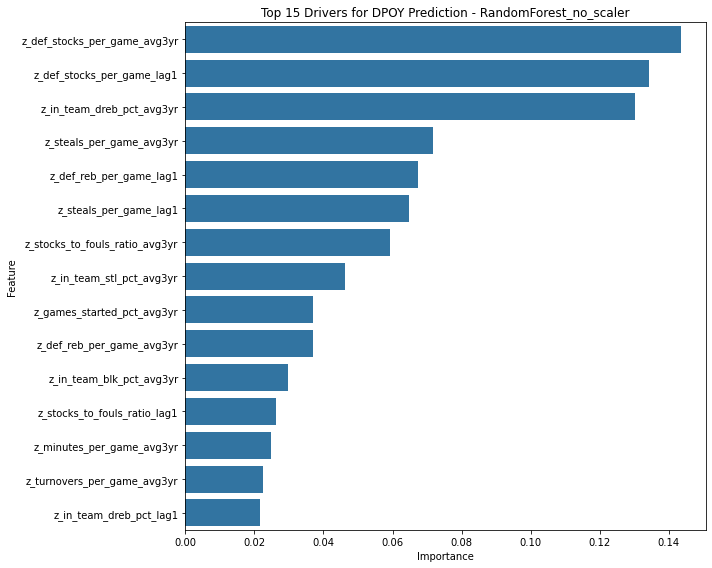

In [39]:
# ---------------------------------------------------------
# White-box logistic + feature importance of the final model
# ---------------------------------------------------------
logistic_row = comparison_df[comparison_df["Model"] == "LogisticRegression"]
if not logistic_row.empty:
    logistic_estimator = logistic_row.iloc[0]["Estimator"]
    coefs = logistic_estimator.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features_final).sort_values(key=abs, ascending=False)

    print("\n=== Logistic Regression coefficients (white-box) ===")
    print(coef_series.head(15))

    plt.figure(figsize=(10, 6))
    coef_series.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 coefficients - Logistic Regression (DPOY)")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = features_final

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 15 Most Important Features (final model):")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=fi_df.head(15))
    plt.title(f"Top 15 Drivers for DPOY Prediction - {final_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


In [54]:
from collections import defaultdict, Counter
from sklearn.model_selection import StratifiedKFold

# =========================
# Rolling expanding-window tuning (years 2..9)
# =========================

model_configs = {
    "RandomForest_no_scaler": {
        "model": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "RandomForest_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "XGBoost_no_scaler": {
        "model": Pipeline([
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "XGBoost_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "LogisticRegression_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

years = sorted(model_df["year"].unique())
min_year = 2
max_val_year = 9

splits = []
for val_year in range(3, max_val_year + 1):
    train_years = list(range(min_year, val_year))
    splits.append((train_years, val_year))

print("\nRolling splits (train_years -> val_year):")
for tr, v in splits:
    print(tr, "->", v)

history = defaultdict(list)

for split_idx, (train_years, val_year) in enumerate(splits, start=1):
    print(f"\n=== Rolling Split {split_idx}: Train years {train_years} | Val year {val_year} ===")

    train_mask = model_df["year"].isin(train_years)
    val_mask   = model_df["year"] == val_year

    X_train_rs = model_df.loc[train_mask, features_final]
    y_train_rs = model_df.loc[train_mask, target]

    X_val_rs   = model_df.loc[val_mask, features_final]
    y_val_rs   = model_df.loc[val_mask, target]

    print(f"  Train size: {len(X_train_rs)}, Positives: {y_train_rs.sum()} | Val size: {len(X_val_rs)}")

    if len(X_val_rs) == 0 or y_val_rs.sum() == 0:
        print("  Skipping split (no positives or empty validation).")
        continue

    n_pos = int(y_train_rs.sum())
    n_neg = len(y_train_rs) - n_pos
    if n_pos < 3 or n_neg < 3:
        print("  Skipping split (not enough positives/negatives for 3-fold CV).")
        continue

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    for name, config in model_configs.items():
        print(f"  > Tuning {name}...")

        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0,
            error_score=np.nan
        )
        grid.fit(X_train_rs, y_train_rs)

        best_estimator = grid.best_estimator_
        best_params    = grid.best_params_

        probs_val = best_estimator.predict_proba(X_val_rs)[:, 1]
        val_auc   = roc_auc_score(y_val_rs, probs_val)
        val_ap    = average_precision_score(y_val_rs, probs_val)

        print(f"    Split {split_idx} | Val year {val_year} | AUC={val_auc:.3f}")

        history[name].append({
            "split": split_idx,
            "val_year": val_year,
            "best_params": best_params,
            "val_auc": val_auc,
            "val_ap": val_ap
        })



Rolling splits (train_years -> val_year):
[2] -> 3
[2, 3] -> 4
[2, 3, 4] -> 5
[2, 3, 4, 5] -> 6
[2, 3, 4, 5, 6] -> 7
[2, 3, 4, 5, 6, 7] -> 8
[2, 3, 4, 5, 6, 7, 8] -> 9

=== Rolling Split 1: Train years [2] | Val year 3 ===
  Train size: 146, Positives: 1 | Val size: 178
  Skipping split (not enough positives/negatives for 3-fold CV).

=== Rolling Split 2: Train years [2, 3] | Val year 4 ===
  Train size: 324, Positives: 2 | Val size: 149
  Skipping split (not enough positives/negatives for 3-fold CV).

=== Rolling Split 3: Train years [2, 3, 4] | Val year 5 ===
  Train size: 473, Positives: 3 | Val size: 127
  > Tuning RandomForest_no_scaler...
    Split 3 | Val year 5 | AUC=0.960
  > Tuning RandomForest_scaled...
    Split 3 | Val year 5 | AUC=0.960
  > Tuning XGBoost_no_scaler...
    Split 3 | Val year 5 | AUC=0.921
  > Tuning XGBoost_scaled...
    Split 3 | Val year 5 | AUC=0.921
  > Tuning LogisticRegression_scaled...
    Split 3 | Val year 5 | AUC=0.421

=== Rolling Split 4: Trai

In [55]:
# =========================
# Select hyperparameters per model based on rolling history
# =========================

selected_configs = {}

for name, records in history.items():
    if not records:
        continue

    df_h = pd.DataFrame(records)
    df_h["params_str"] = df_h["best_params"].astype(str)

    freq = Counter(df_h["params_str"])
    mean_auc_by_params = df_h.groupby("params_str")["val_auc"].mean()

    best_params_str = None
    best_tuple = (-1, -1.0)  # (frequency, mean_auc)

    for p_str, count in freq.items():
        mean_auc = mean_auc_by_params[p_str]
        cand = (count, mean_auc)
        if cand > best_tuple:
            best_tuple = cand
            best_params_str = p_str

    chosen_row = df_h[df_h["params_str"] == best_params_str].iloc[0]
    chosen_params = chosen_row["best_params"]

    selected_configs[name] = {
        "chosen_params": chosen_params,
        "wins": best_tuple[0],
        "mean_auc": best_tuple[1]
    }

    print(f"\nModel {name}: chosen params used in {best_tuple[0]} splits, mean AUC={best_tuple[1]:.3f}")
    print(chosen_params)

# =========================
# Final training on years <= 9 and test on year 10
# =========================

train_final_mask = model_df["year"] < 10
test_final_mask  = model_df["year"] == 10

X_train_final = model_df.loc[train_final_mask, features_final]
y_train_final = model_df.loc[train_final_mask, target]

X_test_final  = model_df.loc[test_final_mask, features_final]
y_test_final  = model_df.loc[test_final_mask, target]

final_results = []

from sklearn.base import clone

for name, info in selected_configs.items():
    print(f"\n=== Final training for {name} with rolling-selected params ===")

    base_pipeline = model_configs[name]["model"]
    estimator = clone(base_pipeline)
    estimator.set_params(**info["chosen_params"])

    estimator.fit(X_train_final, y_train_final)
    probs_test = estimator.predict_proba(X_test_final)[:, 1]

    test_auc = roc_auc_score(y_test_final, probs_test)
    test_ap  = average_precision_score(y_test_final, probs_test)

    res_df = model_df.loc[test_final_mask, ["playerID", "tmID", target]].copy()
    res_df["prob_winning"] = probs_test
    res_df = res_df.sort_values("prob_winning", ascending=False)

    final_results.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        "Results_Test": res_df,
        "wins": info["wins"],
        "mean_auc_cv": info["mean_auc"]
    })

final_comp_df = pd.DataFrame(final_results).sort_values(by="Test AUC", ascending=False)
print("\n--- Final comparison on Test (Year 10) using rolling-selected hyperparams (DPOY) ---")
print(final_comp_df[["Model", "wins", "mean_auc_cv", "Test AUC", "Test AP"]].to_string(index=False))

K = 10
results_by_model = {r["Model"]: r["Results_Test"] for r in final_results}
for name, res_df in results_by_model.items():
    print(f"\n=== {name}: Top {K} predictions (Year 10) ===")
    print(res_df.head(K).to_string(index=False))

    true_rows = res_df[res_df[target] == 1]
    if not true_rows.empty:
        idx = true_rows.index[0]
        rank = res_df.index.get_loc(idx) + 1
        pid = true_rows["playerID"].values[0]
        prob = true_rows["prob_winning"].values[0]
        print(f"  -> True winner {pid} rank: #{rank} (prob={prob:.4f})")
    else:
        print("  -> True winner not present in this model's candidate set.")



Model RandomForest_no_scaler: chosen params used in 1 splits, mean AUC=1.000
{'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Model RandomForest_scaled: chosen params used in 1 splits, mean AUC=1.000
{'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Model XGBoost_no_scaler: chosen params used in 1 splits, mean AUC=1.000
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Model XGBoost_scaled: chosen params used in 1 splits, mean AUC=1.000
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Model LogisticRegression_scaled: chosen params used in 5 splits, mean AUC=0.866
{'model__C': 0.01}

=== Final training for RandomForest_no_scaler with rolling-selected par

#### WNBA Final MVP Award

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Load Data
df = pd.read_csv('../dataset_for_modeling/wnba_finals_mvp_features.csv')
teams = pd.read_csv('../dataset_cleaned/teams.csv')

# ---------------------------------------------------------
# Feature Engineering
# ---------------------------------------------------------

teams['win_pct'] = teams['won'] / teams['GP']

team_stats = teams[['year', 'tmID', 'win_pct']]
df = df.merge(team_stats, on=['year', 'tmID'], how='left')

df = df.sort_values(['playerID', 'year'])

df['experience'] = df.groupby('playerID').cumcount()

# ---------------------------------------------------------
# Comparison Analysis: Winner vs League Average
# ---------------------------------------------------------

all_stats_columns = [
    "playoff_points_per_game",
    "playoff_rebounds_per_game",
    "playoff_assists_per_game",
    "playoff_steals_per_game",
    "playoff_blocks_per_game",
    "playoff_points_per_36",
    "playoff_rebounds_per_36",
    "playoff_assists_per_36",
    "playoff_fg_pct",
    "playoff_three_pct",
    "playoff_ft_pct",
    "playoff_impact",
    "playoff_impact_per_game",
    "playoff_minutes_per_game",
    "playoff_games_started_pct",
    "playoff_ast_to_ratio",
    "playoff_turnover_per_game",
    "is_champion",
    "win_pct",
    "experience"
]

# League averages per year
yearly_means = df.groupby('year')[all_stats_columns].mean()

# Filter Finals MVP winners
winners = df[df['is_finals_mvp'] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: FINALS MVP vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    player_id = winners.loc[year, 'playerID']
    tm_id = winners.loc[year, 'tmID']

    print("\n----------------------------------------------------------------")
    print(f"YEAR {year}: Finals MVP {player_id} ({tm_id})")
    print("----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>8} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 65)

    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]

        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100

        print(f"{col:<30} | {val_winner:>8.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")

# ---------------------------------------------------------
# Feature Set for Modeling
# ---------------------------------------------------------

selected_features = [
    "playoff_points_per_game",
    "playoff_impact_per_game",
    "playoff_minutes_per_game",
    "playoff_games_started_pct",
    "playoff_rebounds_per_game",
    "playoff_assists_per_game",
    "playoff_steals_per_game",
    "playoff_blocks_per_game",
    "playoff_fg_pct",
    "win_pct"
]

target = "is_finals_mvp"



=== DETAILED ANALYSIS: FINALS MVP vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: Finals MVP coopecy01w (HOU)
----------------------------------------------------------------
FEATURE                        |   WINNER | LEAGUE AVG |     DIFF %
-----------------------------------------------------------------
playoff_points_per_game        |    22.67 |       5.66 |    +300.5%
playoff_rebounds_per_game      |     2.50 |       2.42 |      +3.1%
playoff_assists_per_game       |     3.67 |       1.14 |    +223.0%
playoff_steals_per_game        |     1.50 |       0.76 |     +96.6%
playoff_blocks_per_game        |     0.17 |       0.23 |     -27.4%
playoff_points_per_36          |    21.47 |       9.93 |    +116.4%
playoff_rebounds_per_36        |     2.37 |       4.29 |     -44.8%
playoff_assists_per_36         |     3.47 |       1.70 |    +104.1%
playoff_fg_pct                 |     0.38 |       0.35 |      +7.2%
playoff_three_pct  

In [41]:
# ---------------------------------------------------------
# Standardization (Per-year Z-scores)
# ---------------------------------------------------------
z_features = []
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

for col in selected_features:
    new_col = f"z_{col}"
    df[new_col] = df.groupby('year')[col].transform(get_z_score)
    z_features.append(new_col)

# Ensure strictly sorted for time-series ops
df = df.sort_values(['playerID', 'year'])

# ---------------------------------------------------------
# Lag-1 and 3-Year Weighted Rolling Averages
# ---------------------------------------------------------

# Lag-1: previous-year standardized performance
lag_cols = [f"{col}_lag1" for col in z_features]
df[lag_cols] = df.groupby('playerID')[z_features].shift(1)

# 3-year weighted rolling average on lagged z-features
def weighted_avg_robust(series):
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    w = weights[-len(s):]
    mask = ~np.isnan(s)
    if not np.any(mask):
        return np.nan
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

avg_cols = [f"{col}_avg3yr" for col in z_features]

rolling_stats = (
    df.groupby('playerID')[lag_cols]
      .rolling(window=3, min_periods=1)
      .apply(weighted_avg_robust, raw=True)
)

df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

# Final feature set: ONLY lag + avg variants + narrative + experience
features_final = lag_cols + avg_cols + ["experience"]

# Need at least 1 year of history → drop rows with missing lags
model_df = df.dropna(subset=lag_cols)

print(f"\nTotal Features for Model: {len(features_final)}")
print(f"Example Features: {features_final[:3]} ...")
print(f"Rows ready for training: {len(model_df)}")



Total Features for Model: 21
Example Features: ['z_playoff_points_per_game_lag1', 'z_playoff_impact_per_game_lag1', 'z_playoff_minutes_per_game_lag1'] ...
Rows ready for training: 81


In [42]:
# ---------------------------------------------------------
# Temporal Train / Val / Test Split
# ---------------------------------------------------------
train_df = model_df[model_df["year"] < 9]
val_df   = model_df[model_df["year"] == 9]
test_df  = model_df[model_df["year"] == 10]

X_train, y_train = train_df[features_final], train_df[target]
X_val,   y_val   = val_df[features_final],   val_df[target]
X_test,  y_test  = test_df[features_final],  test_df[target]

print(f"\nTraining Samples: {len(X_train)} | Positive Cases (FMVP): {y_train.sum()}")
print(f"Validation Samples: {len(X_val)} | Test Samples: {len(X_test)}")

K = 5  # Top-K hit

# ---------------------------------------------------------
# Baseline (simple Finals MVP heuristic)
# ---------------------------------------------------------
def build_baseline_score(df_):
    score = (
        df_["z_playoff_points_per_game_lag1"].fillna(0) * 0.6
        + df_["z_playoff_impact_per_game_lag1"].fillna(0) * 0.4
        + df_["z_win_pct_lag1"].fillna(0) * 0.3
    )
    return score

val_baseline = val_df[["playerID", "tmID", target]].copy()
val_baseline["baseline_score"] = build_baseline_score(val_df)
val_baseline = val_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 9) ---")
print(val_baseline.head(K).to_string(index=False))
if (val_baseline[target] == 1).any():
    fmvp_rank_baseline_val = val_baseline.index.get_loc(
        val_baseline[val_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (validation): #{fmvp_rank_baseline_val}")

test_baseline = test_df[["playerID", "tmID", target]].copy()
test_baseline["baseline_score"] = build_baseline_score(test_df)
test_baseline = test_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 10) ---")
print(test_baseline.head(K).to_string(index=False))
if (test_baseline[target] == 1).any():
    fmvp_rank_baseline_test = test_baseline.index.get_loc(
        test_baseline[test_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (test): #{fmvp_rank_baseline_test}")
    


Training Samples: 56 | Positive Cases (FMVP): 2
Validation Samples: 13 | Test Samples: 12

--- Baseline ranking (Year 9) ---
  playerID tmID  is_finals_mvp  baseline_score
mcwilta01w  DET              0        2.130814
nolande01w  DET              0        1.947114
smithka01w  DET              1        1.048438
pierspl01w  DET              0        1.027583
  samsh01w  DET              0        0.712321
Baseline winner rank (validation): #3

--- Baseline ranking (Year 10) ---
  playerID tmID  is_finals_mvp  baseline_score
pondeca01w  PHO              0        1.945840
taylope01w  PHO              0        1.510799
tauradi01w  PHO              1        1.407577
douglka01w  IND              0        1.327008
griffyo01w  IND              0        1.158636
Baseline winner rank (test): #3


In [43]:
def summarize_fmvp_errors(bestvalresults, finalresultstest, top_k=5):
    print("\n=== Finals MVP – Error Analysis ===")

    for label, df, year in [
        ("Validation", bestvalresults, 9),
        ("Test",        finalresultstest, 10),
    ]:
        tmp = df.copy()
        tmp["model_rank"] = tmp["prob_winning"].rank(
            method="first", ascending=False
        ).astype(int)

        winner = tmp[tmp["is_finals_mvp"] == 1]
        if winner.empty:
            print(f"\n{label} year {year}: Finals MVP not in candidate set.")
            continue

        winner_rank = int(winner["model_rank"].iloc[0])
        winner_prob = float(winner["prob_winning"].iloc[0])

        print(f"\n{label} year {year}:")
        print(f"  FMVP rank = {winner_rank}")
        print(f"  FMVP prob = {winner_prob:.3f}")
        print(f"  Top-{top_k} hit? {winner_rank <= top_k}")

        false_pos = (
            tmp[tmp["is_finals_mvp"] == 0]
            .sort_values("prob_winning", ascending=False)
            .head(top_k)
        )
        print(f"\n  Top-{top_k} false positives ({label}):")
        print(false_pos[["playerID", "tmID", "prob_winning", "model_rank"]]
              .to_string(index=False))


In [45]:
# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search) - TRAIN only
# ---------------------------------------------------------
model_configs = {
    "RandomForest_no_scaler": {
        "model": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "RandomForest_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "XGBoost_no_scaler": {
        "model": Pipeline([
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "XGBoost_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "LogisticRegression_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

tuned_models = []

print(f"\n--- Grid Search on TRAIN only (years < 9) for {len(model_configs)} models ---")

n_pos_train = int(y_train.sum())
print("Positives in train:", n_pos_train)

n_splits = 2 if n_pos_train < 3 else 3
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for name, config in model_configs.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_auc = grid.best_score_
    print(f"  > Best ROC AUC (CV on train): {best_auc:.4f}")
    print(f"  > Best Params: {grid.best_params_}")

    tuned_models.append({
        "Model": name,
        "CV AUC (train)": best_auc,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })

tuned_df = pd.DataFrame(tuned_models).sort_values(by="CV AUC (train)", ascending=False)
print("\n--- Tuned models (CV on train) ---")
print(tuned_df[["Model", "CV AUC (train)", "Best_Params"]].to_string(index=False))

# ---------------------------------------------------------
# Validation performance (Year 9) for all the models
# ---------------------------------------------------------
val_results = []

print("\n--- Validation performance (Year 9) for tuned models ---")

for row in tuned_models:
    name = row["Model"]
    model = row["Best_Estimator"]

    probs_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, probs_val)
    val_ap = average_precision_score(y_val, probs_val)

    tmp = val_df[["playerID", "tmID", target]].copy()
    tmp["prob_winning"] = probs_val
    tmp = tmp.sort_values("prob_winning", ascending=False)

    top_k = tmp.head(K)
    hit_k = int(top_k[target].any())

    val_results.append({
        "Model": name,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        f"Top-{K} hit (val)": hit_k,
        "Estimator": model,
        "Results_Val": tmp
    })

val_df_models = pd.DataFrame(val_results).sort_values(by="Val AUC", ascending=False)

print("\n--- Model ranking on Validation (Year 9) ---")
print(val_df_models[["Model", "Val AUC", "Val AP", f"Top-{K} hit (val)"]].to_string(index=False))

best_val_row = val_df_models.iloc[0]
best_val_model_name = best_val_row["Model"]
best_val_model = best_val_row["Estimator"]
best_val_results = best_val_row["Results_Val"]

print(f"\nBest model on validation: {best_val_model_name}")

print("\n--- Validation Results (Year 9) ---")
print("Model's Top 5 Predictions (best validation model):")
print(best_val_results.head(5).to_string(index=False))

actual_winner_val = best_val_results[best_val_results[target] == 1]
if not actual_winner_val.empty:
    rank_val = best_val_results.index.get_loc(actual_winner_val.index[0]) + 1
    winner_name_val = actual_winner_val["playerID"].values[0]
    print(f"\nYear 9 Actual FMVP ({winner_name_val}) Rank: #{rank_val}")
else:
    print("\nActual Finals MVP not found in validation set (may have been filtered out).")

# ---------------------------------------------------------
# Detailed comparison: Top 2 vs actual FMVP (Year 9)
# ---------------------------------------------------------
year_to_inspect = 9

top2 = best_val_results.head(2).copy()
top2_ids = top2["playerID"].tolist()
top2_tmids = top2["tmID"].tolist()

true_winner_row = df[(df["year"] == year_to_inspect) & (df[target] == 1)].iloc[0]
true_winner_id = true_winner_row["playerID"]
true_winner_tmid = true_winner_row["tmID"]

print(f"\n=== DETAILED FEATURE COMPARISON – YEAR {year_to_inspect} ===")
print(f"Model Top 1: {top2_ids[0]} ({top2_tmids[0]})")
print(f"Model Top 2: {top2_ids[1]} ({top2_tmids[1]})")
print(f"Actual FMVP: {true_winner_id} ({true_winner_tmid})")

print("\n{:<30} | {:>10} | {:>10} | {:>10}".format(
    "FEATURE", "TOP1", "TOP2", "FMVP"
))
print("-" * 70)

year9_df = df[df["year"] == year_to_inspect]

row_top1 = year9_df[year9_df["playerID"] == top2_ids[0]].iloc[0]
row_top2 = year9_df[year9_df["playerID"] == top2_ids[1]].iloc[0]
row_fmvp = year9_df[year9_df["playerID"] == true_winner_id].iloc[0]

for col in features_final:
    v1 = row_top1[col]
    v2 = row_top2[col]
    vw = row_fmvp[col]
    print("{:<30} | {:>10.2f} | {:>10.2f} | {:>10.2f}".format(col, v1, v2, vw))

# ---------------------------------------------------------
# Retraining (Train + Val) -> Prediction (Test Year 10)
# ---------------------------------------------------------
print("\n--- Evaluating tuned models retrained on TRAIN+VAL ---")

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_comparison = []

for row in tuned_models:
    name = row["Model"]
    estimator = row["Best_Estimator"]

    estimator.fit(X_train_full, y_train_full)
    probs_test = estimator.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, probs_test)
    test_ap = average_precision_score(y_test, probs_test)

    results_test_tmp = test_df[["playerID", "tmID", target]].copy()
    results_test_tmp["prob_winning"] = probs_test
    results_test_tmp = results_test_tmp.sort_values("prob_winning", ascending=False)

    top_k = results_test_tmp.head(K)
    hit_k = int(top_k[target].any())

    final_comparison.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        f"Top-{K} hit (test)": hit_k,
        "Results_Test": results_test_tmp,
        "Estimator": estimator
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) ---")
print(comparison_df[["Model", "Test AUC", "Test AP", f"Top-{K} hit (test)"]].to_string(index=False))

# ---------------------------------------------------------
# Soft-voting ensemble of top FMVP models (Year 10)
# ---------------------------------------------------------
topN = 3  # number of best models to ensemble
top_models = comparison_df.head(topN)

probs_list = []
weights = []

for _, row in top_models.iterrows():
    est = row["Estimator"]
    auc = row["Test AUC"]
    
    # Predict probabilities on the same X_test
    p = est.predict_proba(X_test)[:, 1]
    probs_list.append(p)
    
    # Use Test AUC as weight (better models get higher weight)
    weights.append(auc)

probs_array = np.vstack(probs_list)  # shape: (topN, n_candidates)
weights = np.array(weights)
weights = weights / weights.sum()    # normalize

# Weighted-average ensemble probabilities
probs_ens = np.average(probs_array, axis=0, weights=weights)

# Ensemble metrics on test (Year 10)
test_auc_ens = roc_auc_score(y_test, probs_ens)
test_ap_ens = average_precision_score(y_test, probs_ens)

print("\n=== Soft-voting ensemble on Test (Year 10) – Finals MVP ===")
print(f"Ensemble Test AUC: {test_auc_ens:.4f}")
print(f"Ensemble Test AP:  {test_ap_ens:.4f}")

# Build ensemble ranking dataframe
ensemble_results_test = test_df[["playerID", "tmID", target]].copy()
ensemble_results_test["prob_winning"] = probs_ens
ensemble_results_test = ensemble_results_test.sort_values("prob_winning", ascending=False)

top_k_ens = ensemble_results_test.head(K)
hit_k_ens = int(top_k_ens[target].any())

print(f"\n--- Ensemble Top-{K} candidates (Year 10) ---")
print(ensemble_results_test.head(K).to_string(index=False))
print(f"Ensemble Top-{K} hit (test): {hit_k_ens}")

# Where did the actual FMVP land in the ensemble ranking?
actual_winner_ens = ensemble_results_test[ensemble_results_test[target] == 1]
if not actual_winner_ens.empty:
    winner_rank_ens = ensemble_results_test.index.get_loc(actual_winner_ens.index[0]) + 1
    winner_id_ens = actual_winner_ens["playerID"].values[0]
    winner_prob_ens = actual_winner_ens["prob_winning"].values[0]
    top_prob_ens = ensemble_results_test.iloc[0]["prob_winning"]
    
    print(f"\nEnsemble: Actual FMVP {winner_id_ens} rank (Year 10): #{winner_rank_ens}")
    print(f"Winner prob (ensemble): {winner_prob_ens:.4f} (Top prob: {top_prob_ens:.4f})")
else:
    print("\nEnsemble: actual FMVP not found in test set.")

best_row = comparison_df.iloc[0]
final_model_name = best_row["Model"]
final_model = best_row["Estimator"]
final_results_test = best_row["Results_Test"]

print(f"\nBest model on Test: {final_model_name}")

# --- TEST PREDICTION (Year 10) ---
print("\n--- TEST Results (Year 10 Forecast) ---")
print(f"Model's Top 5 Predictions ({final_model_name}):")
print(final_results_test.head(5).to_string(index=False))

actual_winner_test = final_results_test[final_results_test[target] == 1]
if not actual_winner_test.empty:
    rank_test = final_results_test.index.get_loc(actual_winner_test.index[0]) + 1
    winner_id_test = actual_winner_test["playerID"].values[0]
    prob_test = actual_winner_test["prob_winning"].values[0]
    print(f"\nYear 10 Actual FMVP ({winner_id_test}) Rank: #{rank_test}")
    print(f"   Predicted Probability: {prob_test:.4f}")
else:
    print("\nActual Finals MVP not found in test set.")

# ---------------------------------------------------------
# Generalization gap (model chosen on validation)
# ---------------------------------------------------------
val_row_for_best = val_df_models[val_df_models["Model"] == best_val_model_name].iloc[0]
val_auc_best = val_row_for_best["Val AUC"]
val_ap_best = val_row_for_best["Val AP"]

test_row_for_best_val = comparison_df[comparison_df["Model"] == best_val_model_name].iloc[0]
test_auc_best = test_row_for_best_val["Test AUC"]
test_ap_best = test_row_for_best_val["Test AP"]

print("\n--- Generalization gap (model chosen on validation) ---")
print(f"AUC gap (test - validation): {test_auc_best - val_auc_best:+.4f}")
print(f"AP gap  (test - validation): {test_ap_best - val_ap_best:+.4f}")

# ---------------------------------------------------------
# Error analysis summary (ranks + false positives)
# ---------------------------------------------------------
summarize_fmvp_errors(best_val_results, final_results_test, top_k=5)



--- Grid Search on TRAIN only (years < 9) for 5 models ---
Positives in train: 2

Training RandomForest_no_scaler...
Fitting 2 folds for each of 54 candidates, totalling 108 fits
  > Best ROC AUC (CV on train): 0.8519
  > Best Params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Training RandomForest_scaled...
Fitting 2 folds for each of 54 candidates, totalling 108 fits
  > Best ROC AUC (CV on train): 0.8519
  > Best Params: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Training XGBoost_no_scaler...
Fitting 2 folds for each of 32 candidates, totalling 64 fits
  > Best ROC AUC (CV on train): 0.9444
  > Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Training XGBoost_scaled...
Fitting 2 folds for each of 32 candidates, totalling 64 fits
  >


Top 15 Most Important Features (final model):
                           Feature  Importance
 z_playoff_minutes_per_game_avg3yr    0.140648
  z_playoff_points_per_game_avg3yr    0.108164
   z_playoff_minutes_per_game_lag1    0.098781
z_playoff_games_started_pct_avg3yr    0.075475
                    z_win_pct_lag1    0.066002
   z_playoff_assists_per_game_lag1    0.065862
    z_playoff_points_per_game_lag1    0.064149
 z_playoff_assists_per_game_avg3yr    0.049543
    z_playoff_steals_per_game_lag1    0.045652
  z_playoff_games_started_pct_lag1    0.045225
  z_playoff_impact_per_game_avg3yr    0.043212
  z_playoff_steals_per_game_avg3yr    0.031411
                  z_win_pct_avg3yr    0.030164
    z_playoff_impact_per_game_lag1    0.028006
  z_playoff_rebounds_per_game_lag1    0.025868


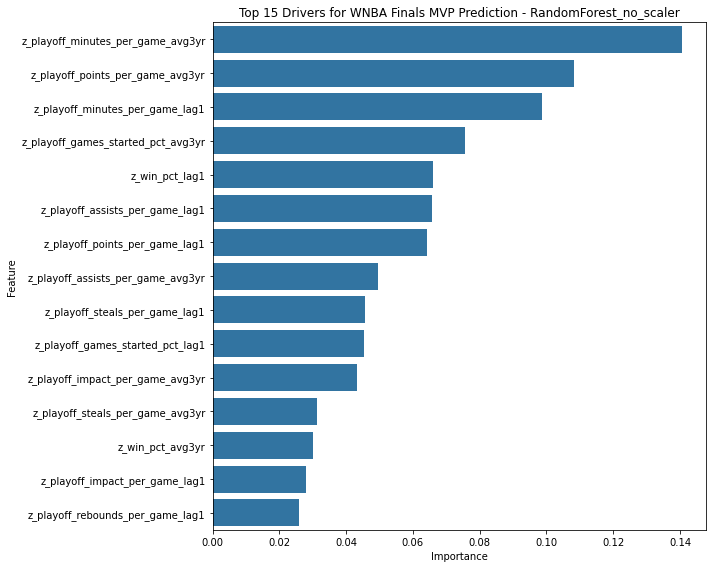

In [46]:
# ---------------------------------------------------------
# White-box logistic + feature importance of the final model
# ---------------------------------------------------------
logistic_row = comparison_df[comparison_df["Model"] == "LogisticRegression"]
if not logistic_row.empty:
    logistic_estimator = logistic_row.iloc[0]["Estimator"]
    coefs = logistic_estimator.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features_final).sort_values(key=abs, ascending=False)

    print("\n=== Logistic Regression coefficients (white-box) ===")
    print(coef_series.head(15))

    plt.figure(figsize=(10, 6))
    coef_series.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 coefficients - Logistic Regression (WNBA Finals MVP)")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = features_final

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 15 Most Important Features (final model):")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=fi_df.head(15))
    plt.title(f"Top 15 Drivers for WNBA Finals MVP Prediction - {final_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
    

In [67]:
from collections import defaultdict, Counter
from sklearn.model_selection import StratifiedKFold

# =========================
# 1) Rolling expanding-window tuning (years 2..9)
# =========================

model_configs = {
    "RandomForest_no_scaler": {
        "model": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "RandomForest_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "XGBoost_no_scaler": {
        "model": Pipeline([
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "XGBoost_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "LogisticRegression_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

years = sorted(model_df["year"].unique())
min_year = 2
max_val_year = 9

splits = []
for val_year in range(3, max_val_year + 1):
    train_years = list(range(min_year, val_year))
    splits.append((train_years, val_year))

print("\nRolling splits (train_years -> val_year):")
for tr, v in splits:
    print(tr, "->", v)

history = defaultdict(list)

for split_idx, (train_years, val_year) in enumerate(splits, start=1):
    print(f"\n=== Rolling Split {split_idx}: Train years {train_years} | Val year {val_year} ===")

    train_mask = model_df["year"].isin(train_years)
    val_mask   = model_df["year"] == val_year

    X_train_rs = model_df.loc[train_mask, features_final]
    y_train_rs = model_df.loc[train_mask, target]

    X_val_rs   = model_df.loc[val_mask, features_final]
    y_val_rs   = model_df.loc[val_mask, target]

    print(f"  Train size: {len(X_train_rs)}, Positives: {y_train_rs.sum()} | Val size: {len(X_val_rs)}")

    if len(X_val_rs) == 0 or y_val_rs.sum() == 0:
        print("  Skipping split (no positives or empty validation).")
        continue

    n_pos = int(y_train_rs.sum())
    n_neg = len(y_train_rs) - n_pos

    max_splits = min(3, n_pos, n_neg)

    if max_splits < 2:
        print("  Skipping split (not enough positives/negatives for CV).")
        continue

    cv = StratifiedKFold(n_splits=max_splits, shuffle=True, random_state=42)

    for name, config in model_configs.items():
        print(f"  > Tuning {name}...")

        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0,
            error_score=np.nan
        )
        grid.fit(X_train_rs, y_train_rs)

        best_estimator = grid.best_estimator_
        best_params    = grid.best_params_

        probs_val = best_estimator.predict_proba(X_val_rs)[:, 1]
        val_auc   = roc_auc_score(y_val_rs, probs_val)
        val_ap    = average_precision_score(y_val_rs, probs_val)

        print(f"    Split {split_idx} | Val year {val_year} | AUC={val_auc:.3f}")

        history[name].append({
            "split": split_idx,
            "val_year": val_year,
            "best_params": best_params,
            "val_auc": val_auc,
            "val_ap": val_ap
        })



Rolling splits (train_years -> val_year):
[2] -> 3
[2, 3] -> 4
[2, 3, 4] -> 5
[2, 3, 4, 5] -> 6
[2, 3, 4, 5, 6] -> 7
[2, 3, 4, 5, 6, 7] -> 8
[2, 3, 4, 5, 6, 7, 8] -> 9

=== Rolling Split 1: Train years [2] | Val year 3 ===
  Train size: 0, Positives: 0 | Val size: 14
  Skipping split (not enough positives/negatives for CV).

=== Rolling Split 2: Train years [2, 3] | Val year 4 ===
  Train size: 14, Positives: 1 | Val size: 9
  Skipping split (no positives or empty validation).

=== Rolling Split 3: Train years [2, 3, 4] | Val year 5 ===
  Train size: 23, Positives: 1 | Val size: 0
  Skipping split (no positives or empty validation).

=== Rolling Split 4: Train years [2, 3, 4, 5] | Val year 6 ===
  Train size: 23, Positives: 1 | Val size: 8
  Skipping split (no positives or empty validation).

=== Rolling Split 5: Train years [2, 3, 4, 5, 6] | Val year 7 ===
  Train size: 31, Positives: 1 | Val size: 14
  Skipping split (not enough positives/negatives for CV).

=== Rolling Split 6: Tra

In [68]:
# =========================
# 2) Select hyperparameters per model (frequency then mean AUC)
# =========================

selected_configs = {}

for name, records in history.items():
    if not records:
        continue

    df_h = pd.DataFrame(records)
    df_h["params_str"] = df_h["best_params"].astype(str)

    freq = Counter(df_h["params_str"])
    mean_auc_by_params = df_h.groupby("params_str")["val_auc"].mean()

    best_params_str = None
    best_tuple = (-1, -1.0)  # (wins, mean_auc)

    for p_str, count in freq.items():
        mean_auc = mean_auc_by_params[p_str]
        cand = (count, mean_auc)
        if cand > best_tuple:
            best_tuple = cand
            best_params_str = p_str

    chosen_row = df_h[df_h["params_str"] == best_params_str].iloc[0]
    chosen_params = chosen_row["best_params"]

    selected_configs[name] = {
        "chosen_params": chosen_params,
        "wins": best_tuple[0],
        "mean_auc": best_tuple[1]
    }

    print(f"\nModel {name}: chosen params used in {best_tuple[0]} splits, mean AUC={best_tuple[1]:.3f}")
    print(chosen_params)



Model RandomForest_no_scaler: chosen params used in 1 splits, mean AUC=0.833
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Model RandomForest_scaled: chosen params used in 1 splits, mean AUC=0.833
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}

Model XGBoost_no_scaler: chosen params used in 1 splits, mean AUC=0.833
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Model XGBoost_scaled: chosen params used in 1 splits, mean AUC=0.833
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Model LogisticRegression_scaled: chosen params used in 1 splits, mean AUC=0.833
{'model__C': 0.01}


In [69]:
# =========================
# 3) Final training on years <= 9 and test on year 10
# =========================

train_final_mask = model_df["year"] < 10
test_final_mask  = model_df["year"] == 10

X_train_final = model_df.loc[train_final_mask, features_final]
y_train_final = model_df.loc[train_final_mask, target]

X_test_final  = model_df.loc[test_final_mask, features_final]
y_test_final  = model_df.loc[test_final_mask, target]

final_results = []

from sklearn.base import clone

for name, info in selected_configs.items():
    print(f"\n=== Final training for {name} with rolling-selected params (FMVP) ===")

    base_pipeline = model_configs[name]["model"]
    estimator = clone(base_pipeline)
    estimator.set_params(**info["chosen_params"])

    estimator.fit(X_train_final, y_train_final)
    probs_test = estimator.predict_proba(X_test_final)[:, 1]

    test_auc = roc_auc_score(y_test_final, probs_test)
    test_ap  = average_precision_score(y_test_final, probs_test)

    res_df = model_df.loc[test_final_mask, ["playerID", "tmID", target]].copy()
    res_df["prob_winning"] = probs_test
    res_df = res_df.sort_values("prob_winning", ascending=False)

    final_results.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        "Results_Test": res_df,
        "wins": info["wins"],
        "mean_auc_cv": info["mean_auc"]
    })

final_comp_df = pd.DataFrame(final_results).sort_values(by="Test AUC", ascending=False)
print("\n--- Final comparison on Test (Year 10) using rolling-selected hyperparams (FMVP) ---")
print(final_comp_df[["Model", "wins", "mean_auc_cv", "Test AUC", "Test AP"]].to_string(index=False))

K = 10
results_by_model = {r["Model"]: r["Results_Test"] for r in final_results}

for name, res_df in results_by_model.items():
    print(f"\n=== {name}: Top {K} predictions (Year 10) ===")
    print(res_df.head(K).to_string(index=False))

    true_rows = res_df[res_df[target] == 1]
    if not true_rows.empty:
        idx = true_rows.index[0]
        rank = res_df.index.get_loc(idx) + 1
        pid = true_rows["playerID"].values[0]
        prob = true_rows["prob_winning"].values[0]
        print(f"  -> True winner {pid} rank: #{rank} (prob={prob:.4f})")
    else:
        print("  -> True winner not present in this model's candidate set.")



=== Final training for RandomForest_no_scaler with rolling-selected params (FMVP) ===

=== Final training for RandomForest_scaled with rolling-selected params (FMVP) ===

=== Final training for XGBoost_no_scaler with rolling-selected params (FMVP) ===

=== Final training for XGBoost_scaled with rolling-selected params (FMVP) ===

=== Final training for LogisticRegression_scaled with rolling-selected params (FMVP) ===

--- Final comparison on Test (Year 10) using rolling-selected hyperparams (FMVP) ---
                    Model  wins  mean_auc_cv  Test AUC  Test AP
   RandomForest_no_scaler     1     0.833333  1.000000 1.000000
      RandomForest_scaled     1     0.833333  1.000000 1.000000
        XGBoost_no_scaler     1     0.833333  0.818182 0.333333
           XGBoost_scaled     1     0.833333  0.818182 0.333333
LogisticRegression_scaled     1     0.833333  0.818182 0.333333

=== RandomForest_no_scaler: Top 10 predictions (Year 10) ===
  playerID tmID  is_finals_mvp  prob_winning
t

#### Coach of the Year Award

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Load Data
df = pd.read_csv('../dataset_for_modeling/coach_of_year_features.csv')

# Ensure sorted for time-based operations
df = df.sort_values(['coachID', 'year'])

# Experience: number of seasons this coach appears in dataset
df['experience'] = df.groupby('coachID').cumcount()

target = 'won_coy'

# ---------------------------------------------------------
# Comparison: COY vs League Average
# ---------------------------------------------------------

all_stats_columns = [
    # Coach performance
    'won_coach', 'lost_coach', 'win_percentage', 'total_games', 'stint',
    'post_wins', 'post_losses', 'playoff_games', 'playoff_win_pct', 'made_playoffs',

    # Team performance
    'rank', 'confW', 'confL', 'conference_win_pct',
    'homeW', 'homeL', 'home_win_pct',
    'awayW', 'awayL', 'away_win_pct', 'home_advantage',

    # Team stats
    'o_pts', 'd_pts', 'point_differential',
    'offensive_efficiency', 'defensive_efficiency', 'GP', 'attend',

    # Improvement metrics
    'prev_year_wins', 'prev_year_win_pct',
    'win_improvement', 'win_pct_improvement',
    'team_prev_wins', 'team_win_improvement',

    # Extra context
    'experience'
]

# League averages per year (only on numeric columns above)
yearly_means = df.groupby('year')[all_stats_columns].mean()

# Filter COY winners
winners = df[df[target] == 1].set_index('year').sort_index()

print("\n=== DETAILED ANALYSIS: COACH OF THE YEAR vs LEAGUE AVERAGE (PER YEAR) ===")

for year in winners.index:
    coach_id = winners.loc[year, 'coachID']
    tm_id = winners.loc[year, 'tmID']

    print("\n----------------------------------------------------------------")
    print(f"YEAR {year}: COY {coach_id} ({tm_id})")
    print("----------------------------------------------------------------")
    print(f"{'FEATURE':<30} | {'WINNER':>10} | {'LEAGUE AVG':>10} | {'DIFF %':>10}")
    print("-" * 70)

    for col in all_stats_columns:
        val_winner = winners.loc[year, col]
        val_mean = yearly_means.loc[year, col]

        if val_mean == 0:
            diff_pct = 0.0
        else:
            diff_pct = ((val_winner - val_mean) / val_mean) * 100

        print(f"{col:<30} | {val_winner:>10.2f} | {val_mean:>10.2f} | {diff_pct:>+9.1f}%")


# ---------------------------------------------------------
# Feature Set for Modeling
# ---------------------------------------------------------

selected_features = [
    'win_percentage', 'stint', 'playoff_win_pct', 'made_playoffs',
    'rank', 'confW', 'confL', 'conference_win_pct',
    'homeW', 'homeL', 'home_win_pct', 'away_win_pct', 'home_advantage',
    'offensive_efficiency', 'defensive_efficiency'
]

narrative_features = ['experience']



=== DETAILED ANALYSIS: COACH OF THE YEAR vs LEAGUE AVERAGE (PER YEAR) ===

----------------------------------------------------------------
YEAR 1: COY coopemi01w (LAS)
----------------------------------------------------------------
FEATURE                        |     WINNER | LEAGUE AVG |     DIFF %
----------------------------------------------------------------------
won_coach                      |      28.00 |      15.06 |     +85.9%
lost_coach                     |       4.00 |      15.06 |     -73.4%
win_percentage                 |       0.88 |       0.50 |     +76.5%
total_games                    |      32.00 |      30.12 |      +6.3%
stint                          |       0.00 |       0.18 |    -100.0%
post_wins                      |       2.00 |       0.94 |    +112.5%
post_losses                    |       2.00 |       0.94 |    +112.5%
playoff_games                  |       4.00 |       1.88 |    +112.5%
playoff_win_pct                |       0.50 |       0.17 |    +1

In [48]:
# ---------------------------------------------------------
# Standardization (Per-year Z-scores)
# ---------------------------------------------------------
z_features = []
get_z_score = lambda x: (x - x.mean()) / (x.std() + 1e-5)

for col in selected_features:
    new_col = f"z_{col}"
    df[new_col] = df.groupby('year')[col].transform(get_z_score)
    z_features.append(new_col)

# Re-sort to be safe for time-series operations
df = df.sort_values(['coachID', 'year'])

# ---------------------------------------------------------
# Lag-1 and 3-Year Weighted Rolling Averages
# ---------------------------------------------------------
lag_cols = [f"{col}_lag1" for col in z_features]
df[lag_cols] = df.groupby('coachID')[z_features].shift(1)

def weighted_avg_robust(series):
    weights = np.array([0.2, 0.3, 0.5])
    s = np.array(series)
    w = weights[-len(s):]
    mask = ~np.isnan(s)
    if not np.any(mask):
        return np.nan
    return np.sum(s[mask] * w[mask]) / np.sum(w[mask])

avg_cols = [f"{col}_avg3yr" for col in z_features]

rolling_stats = (
    df.groupby('coachID')[lag_cols]
      .rolling(window=3, min_periods=1)
      .apply(weighted_avg_robust, raw=True)
)

df[avg_cols] = rolling_stats.reset_index(level=0, drop=True)

# Final feature set: ONLY lag + avg variants + narrative
features_final = lag_cols + avg_cols + narrative_features

# Need at least 1 year of history for lags
model_df = df.dropna(subset=lag_cols)

print(f"\nTotal Features for COY Model: {len(features_final)}")
print(f"Example Features: {features_final[:3]} ...")
print(f"Rows ready for training: {len(model_df)}")



Total Features for COY Model: 31
Example Features: ['z_win_percentage_lag1', 'z_stint_lag1', 'z_playoff_win_pct_lag1'] ...
Rows ready for training: 105


In [49]:
# ---------------------------------------------------------
# Temporal Train / Val / Test Split
# ---------------------------------------------------------
train_df = model_df[model_df["year"] < 9]
val_df   = model_df[model_df["year"] == 9]
test_df  = model_df[model_df["year"] == 10]

X_train, y_train = train_df[features_final], train_df[target]
X_val,   y_val   = val_df[features_final],   val_df[target]
X_test,  y_test  = test_df[features_final],  test_df[target]

print(f"\nTraining Samples: {len(X_train)} | COY Winners: {y_train.sum()}")
print(f"Validation Samples: {len(X_val)} | Test Samples: {len(X_test)}")

K = 5  # Top-K hit

# ---------------------------------------------------------
# Baseline (simple COY heuristic)
# ---------------------------------------------------------
def build_baseline_score(df_):
    score = (
        df_["z_win_percentage_lag1"].fillna(0) * 0.7
        - df_["z_rank_lag1"].fillna(0) * 0.3
        + df_["z_playoff_win_pct_lag1"].fillna(0) * 0.2
    )
    return score

val_baseline = val_df[["coachID", "tmID", target]].copy()
val_baseline["baseline_score"] = build_baseline_score(val_df)
val_baseline = val_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 9) ---")
print(val_baseline.head(K).to_string(index=False))
if (val_baseline[target] == 1).any():
    coy_rank_baseline_val = val_baseline.index.get_loc(
        val_baseline[val_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (validation): #{coy_rank_baseline_val}")

test_baseline = test_df[["coachID", "tmID", target]].copy()
test_baseline["baseline_score"] = build_baseline_score(test_df)
test_baseline = test_baseline.sort_values("baseline_score", ascending=False)

print("\n--- Baseline ranking (Year 10) ---")
print(test_baseline.head(K).to_string(index=False))
if (test_baseline[target] == 1).any():
    coy_rank_baseline_test = test_baseline.index.get_loc(
        test_baseline[test_baseline[target] == 1].index[0]
    ) + 1
    print(f"Baseline winner rank (test): #{coy_rank_baseline_test}")
    


Training Samples: 81 | COY Winners: 6
Validation Samples: 11 | Test Samples: 13

--- Baseline ranking (Year 9) ---
   coachID tmID  won_coy  baseline_score
laimbbi01w  DET        0        1.584381
hugheda99w  SAS        0        0.871970
bouceje01w  SAC        0        0.553438
thibami99w  CON        1        0.442066
dunnli99wc  IND        0        0.240270
Baseline winner rank (validation): #4

--- Baseline ranking (Year 10) ---
   coachID tmID  won_coy  baseline_score
laimbbi01w  DET        0        1.557200
hugheda99w  SAS        0        1.536593
whisejo99w  SAC        0        1.142271
aglerbr99w  SEA        0        1.062194
thibami99w  CON        0        0.941333
Baseline winner rank (test): #13


In [50]:
def summarize_coy_errors(bestvalresults, finalresultstest, top_k=5):
    print("\n=== Coach of the Year – Error Analysis ===")

    for label, df, year in [
        ("Validation", bestvalresults, 9),
        ("Test",        finalresultstest, 10),
    ]:
        tmp = df.copy()
        tmp["model_rank"] = tmp["prob_winning"].rank(
            method="first", ascending=False
        ).astype(int)

        winner = tmp[tmp["won_coy"] == 1]
        if winner.empty:
            print(f"\n{label} year {year}: COY winner not in candidate set.")
            continue

        winner_rank = int(winner["model_rank"].iloc[0])
        winner_prob = float(winner["prob_winning"].iloc[0])

        print(f"\n{label} year {year}:")
        print(f"  COY rank = {winner_rank}")
        print(f"  COY prob = {winner_prob:.3f}")
        print(f"  Top-{top_k} hit? {winner_rank <= top_k}")

        false_pos = (
            tmp[tmp["won_coy"] == 0]
            .sort_values("prob_winning", ascending=False)
            .head(top_k)
        )
        print(f"\n  Top-{top_k} false positives ({label}):")
        print(false_pos[["coachID", "tmID", "prob_winning", "model_rank"]]
              .to_string(index=False))


In [53]:
# ---------------------------------------------------------
# Hyperparameter Optimization (Grid Search) - TRAIN only
# ---------------------------------------------------------
model_configs = {
    "RandomForest_no_scaler": {
        "model": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "RandomForest_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "XGBoost_no_scaler": {
        "model": Pipeline([
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "XGBoost_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "LogisticRegression_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

tuned_models = []

print(f"\n--- Grid Search on TRAIN only (years < 9) for {len(model_configs)} models ---")

n_pos_train = int(y_train.sum())
n_splits = 2 if n_pos_train < 3 else 3
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print("Positives in train:", n_pos_train)

for name, config in model_configs.items():
    print(f"\nTraining {name}...")

    grid = GridSearchCV(
        estimator=config["model"],
        param_grid=config["params"],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_auc = grid.best_score_
    print(f"  > Best ROC AUC (CV on train): {best_auc:.4f}")
    print(f"  > Best Params: {grid.best_params_}")

    tuned_models.append({
        "Model": name,
        "CV AUC (train)": best_auc,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })

tuned_df = pd.DataFrame(tuned_models).sort_values(by="CV AUC (train)", ascending=False)
print("\n--- Tuned models (CV on train) ---")
print(tuned_df[["Model", "CV AUC (train)", "Best_Params"]].to_string(index=False))

# ---------------------------------------------------------
# Validation performance (Year 9) for all the models
# ---------------------------------------------------------
val_results = []

print("\n--- Validation performance (Year 9) for tuned models ---")

for row in tuned_models:
    name = row["Model"]
    model = row["Best_Estimator"]

    probs_val = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, probs_val)
    val_ap = average_precision_score(y_val, probs_val)

    tmp = val_df[["coachID", "tmID", target]].copy()
    tmp["prob_winning"] = probs_val
    tmp = tmp.sort_values("prob_winning", ascending=False)

    top_k = tmp.head(K)
    hit_k = int(top_k[target].any())

    val_results.append({
        "Model": name,
        "Val AUC": val_auc,
        "Val AP": val_ap,
        f"Top-{K} hit (val)": hit_k,
        "Estimator": model,
        "Results_Val": tmp
    })

val_df_models = pd.DataFrame(val_results).sort_values(by="Val AUC", ascending=False)

print("\n--- Model ranking on Validation (Year 9) ---")
print(val_df_models[["Model", "Val AUC", "Val AP", f"Top-{K} hit (val)"]].to_string(index=False))

best_val_row = val_df_models.iloc[0]
best_val_model_name = best_val_row["Model"]
best_val_model = best_val_row["Estimator"]
best_val_results = best_val_row["Results_Val"]

print(f"\nBest model on validation: {best_val_model_name}")

print("\n--- Validation Results (Year 9) ---")
print("Model's Top 5 Predictions (best validation model):")
print(best_val_results.head(5).to_string(index=False))

actual_winner_val = best_val_results[best_val_results[target] == 1]
if not actual_winner_val.empty:
    rank_val = best_val_results.index.get_loc(actual_winner_val.index[0]) + 1
    winner_name_val = actual_winner_val["coachID"].values[0]
    print(f"\nYear 9 Actual COY ({winner_name_val}) Rank: #{rank_val}")
else:
    print("\nActual COY winner not found in validation set (may have been filtered out).")

# ---------------------------------------------------------
# Retrain on Full History (Years 1–9) and Test on Year 10
# ---------------------------------------------------------
print("\n--- Evaluating tuned models retrained on TRAIN+VAL ---")

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_comparison = []

for row in tuned_models:
    name = row["Model"]
    estimator = row["Best_Estimator"]

    estimator.fit(X_train_full, y_train_full)
    probs_test = estimator.predict_proba(X_test)[:, 1]

    test_auc = roc_auc_score(y_test, probs_test)
    test_ap = average_precision_score(y_test, probs_test)

    results_test_tmp = test_df[["coachID", "tmID", target]].copy()
    results_test_tmp["prob_winning"] = probs_test
    results_test_tmp = results_test_tmp.sort_values("prob_winning", ascending=False)

    top_k = results_test_tmp.head(K)
    hit_k = int(top_k[target].any())

    final_comparison.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        f"Top-{K} hit (test)": hit_k,
        "Results_Test": results_test_tmp,
        "Estimator": estimator
    })

comparison_df = pd.DataFrame(final_comparison).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) ---")
print(comparison_df[["Model", "Test AUC", "Test AP", f"Top-{K} hit (test)"]].to_string(index=False))

# ---------------------------------------------------------
# Soft-voting ensemble of top COY models (Year 10)
# ---------------------------------------------------------
topN = 3  # number of best models to ensemble
top_models = comparison_df.head(topN)

probs_list = []
weights = []

for _, row in top_models.iterrows():
    est = row["Estimator"]
    auc = row["Test AUC"]
    
    # Predict probabilities on the same X_test
    p = est.predict_proba(X_test)[:, 1]
    probs_list.append(p)
    
    # Use Test AUC as weight (better models get higher weight)
    weights.append(auc)

probs_array = np.vstack(probs_list)  # shape: (topN, n_candidates)
weights = np.array(weights)
weights = weights / weights.sum()    # normalize

# Weighted-average ensemble probabilities
probs_ens = np.average(probs_array, axis=0, weights=weights)

# Ensemble metrics on test (Year 10)
test_auc_ens = roc_auc_score(y_test, probs_ens)
test_ap_ens = average_precision_score(y_test, probs_ens)

print("\n=== Soft-voting ensemble on Test (Year 10) – COY ===")
print(f"Ensemble Test AUC: {test_auc_ens:.4f}")
print(f"Ensemble Test AP:  {test_ap_ens:.4f}")

# Build ensemble ranking dataframe
ensemble_results_test = test_df[["coachID", "tmID", target]].copy()
ensemble_results_test["prob_winning"] = probs_ens
ensemble_results_test = ensemble_results_test.sort_values("prob_winning", ascending=False)

top_k_ens = ensemble_results_test.head(K)
hit_k_ens = int(top_k_ens[target].any())

print(f"\n--- Ensemble Top-{K} candidates (Year 10) ---")
print(ensemble_results_test.head(K).to_string(index=False))
print(f"Ensemble Top-{K} hit (test): {hit_k_ens}")

# Where did the actual COY land in the ensemble ranking?
actual_winner_ens = ensemble_results_test[ensemble_results_test[target] == 1]
if not actual_winner_ens.empty:
    winner_rank_ens = ensemble_results_test.index.get_loc(actual_winner_ens.index[0]) + 1
    winner_id_ens = actual_winner_ens["coachID"].values[0]
    winner_prob_ens = actual_winner_ens["prob_winning"].values[0]
    top_prob_ens = ensemble_results_test.iloc[0]["prob_winning"]
    
    print(f"\nEnsemble: Actual COY {winner_id_ens} rank (Year 10): #{winner_rank_ens}")
    print(f"Winner prob (ensemble): {winner_prob_ens:.4f} (Top prob: {top_prob_ens:.4f})")
else:
    print("\nEnsemble: actual COY winner not found in test set.")

best_row = comparison_df.iloc[0]
final_model_name = best_row["Model"]
final_model = best_row["Estimator"]
final_results_test = best_row["Results_Test"]

print(f"\nBest model on Test: {final_model_name}")

# --- TEST PREDICTION (Year 10) ---
print("\n--- TEST Results (Year 10 Forecast) ---")
print(f"Model's Top 5 Predictions ({final_model_name}):")
print(final_results_test.head(5).to_string(index=False))

actual_winner_test = final_results_test[final_results_test[target] == 1]
if not actual_winner_test.empty:
    rank_test = final_results_test.index.get_loc(actual_winner_test.index[0]) + 1
    winner_id_test = actual_winner_test["coachID"].values[0]
    prob_test = actual_winner_test["prob_winning"].values[0]
    print(f"\nYear 10 Actual COY ({winner_id_test}) Rank: #{rank_test}")
    print(f"   Predicted Probability: {prob_test:.4f}")
else:
    print("\nActual COY winner not found in test set.")

# ---------------------------------------------------------
# Generalization gap (model chosen on validation)
# ---------------------------------------------------------
val_row_for_best = val_df_models[val_df_models["Model"] == best_val_model_name].iloc[0]
val_auc_best = val_row_for_best["Val AUC"]
val_ap_best = val_row_for_best["Val AP"]

test_row_for_best_val = comparison_df[comparison_df["Model"] == best_val_model_name].iloc[0]
test_auc_best = test_row_for_best_val["Test AUC"]
test_ap_best = test_row_for_best_val["Test AP"]

print("\n--- Generalization gap (model chosen on validation) ---")
print(f"AUC gap (test - validation): {test_auc_best - val_auc_best:+.4f}")
print(f"AP gap  (test - validation): {test_ap_best - val_ap_best:+.4f}")

# ---------------------------------------------------------
# Error analysis summary (ranks + false positives)
# ---------------------------------------------------------
summarize_coy_errors(best_val_results, final_results_test, top_k=5)



--- Grid Search on TRAIN only (years < 9) for 5 models ---
Positives in train: 6

Training RandomForest_no_scaler...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.1867
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}

Training RandomForest_scaled...
Fitting 3 folds for each of 54 candidates, totalling 162 fits
  > Best ROC AUC (CV on train): 0.1867
  > Best Params: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}

Training XGBoost_no_scaler...
Fitting 3 folds for each of 32 candidates, totalling 96 fits
  > Best ROC AUC (CV on train): 0.1767
  > Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 400, 'model__subsample': 1.0}

Training XGBoost_scaled...
Fitting 3 folds for each of 32 candidates, to


Top 15 Most Important Features (final model):
                    Feature  Importance
      z_home_win_pct_avg3yr    0.106855
               z_confL_lag1    0.084386
z_offensive_efficiency_lag1    0.081870
     z_playoff_win_pct_lag1    0.071717
    z_home_advantage_avg3yr    0.056969
       z_made_playoffs_lag1    0.056904
      z_win_percentage_lag1    0.054003
             z_stint_avg3yr    0.053997
             z_homeW_avg3yr    0.047683
               z_confW_lag1    0.046744
z_defensive_efficiency_lag1    0.045230
             z_homeL_avg3yr    0.037705
  z_conference_win_pct_lag1    0.036448
             z_confL_avg3yr    0.029135
      z_home_advantage_lag1    0.023236


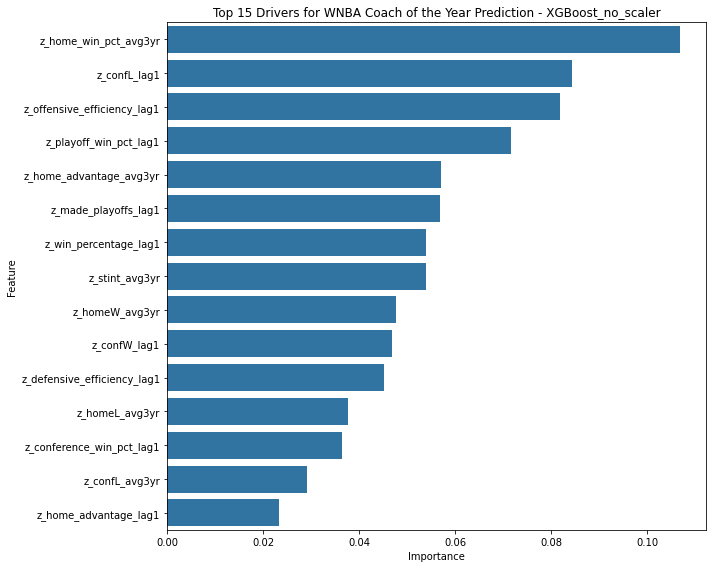

In [54]:
# ---------------------------------------------------------
# White-box logistic + feature importance of the final model
# ---------------------------------------------------------
logistic_row = comparison_df[comparison_df["Model"] == "LogisticRegression"]
if not logistic_row.empty:
    logistic_estimator = logistic_row.iloc[0]["Estimator"]
    coefs = logistic_estimator.named_steps["model"].coef_[0]
    coef_series = pd.Series(coefs, index=features_final).sort_values(key=abs, ascending=False)

    print("\n=== Logistic Regression coefficients (white-box) ===")
    print(coef_series.head(15))

    plt.figure(figsize=(10, 6))
    coef_series.head(15).sort_values().plot(kind="barh")
    plt.title("Top 15 coefficients - Logistic Regression (COY)")
    plt.xlabel("Coefficient (standardized features)")
    plt.tight_layout()
    plt.show()

if hasattr(final_model.named_steps["model"], "feature_importances_"):
    importances = final_model.named_steps["model"].feature_importances_
    feature_names = features_final

    fi_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    print("\nTop 15 Most Important Features (final model):")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(x="Importance", y="Feature", data=fi_df.head(15))
    plt.title(f"Top 15 Drivers for WNBA Coach of the Year Prediction - {final_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


In [72]:
from collections import defaultdict, Counter

# =========================
# 1) Rolling expanding-window tuning (years 2..9)
# =========================

model_configs = {
    "RandomForest_no_scaler": {
        "model": Pipeline([
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "RandomForest_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_leaf": [1, 2, 4],
            "model__class_weight": ["balanced", "balanced_subsample"]
        }
    },

    "XGBoost_no_scaler": {
        "model": Pipeline([
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "XGBoost_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            ))
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0]
        }
    },

    "LogisticRegression_scaled": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            ))
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1.0, 10.0]
        }
    }
}

years = sorted(model_df["year"].unique())
min_year = 2
max_val_year = 9

splits = []
for val_year in range(3, max_val_year + 1):
    train_years = list(range(min_year, val_year))
    splits.append((train_years, val_year))

print("\nRolling splits (train_years -> val_year):")
for tr, v in splits:
    print(tr, "->", v)

history = defaultdict(list)

for split_idx, (train_years, val_year) in enumerate(splits, start=1):
    print(f"\n=== Rolling Split {split_idx}: Train years {train_years} | Val year {val_year} ===")

    train_mask = model_df["year"].isin(train_years)
    val_mask   = model_df["year"] == val_year

    X_train_rs = model_df.loc[train_mask, features_final]
    y_train_rs = model_df.loc[train_mask, target]

    X_val_rs   = model_df.loc[val_mask, features_final]
    y_val_rs   = model_df.loc[val_mask, target]

    print(f"  Train size: {len(X_train_rs)}, Positives: {y_train_rs.sum()} | Val size: {len(X_val_rs)}")

    if len(X_val_rs) == 0 or y_val_rs.sum() == 0:
        print("  Skipping split (no positives or empty validation).")
        continue

    n_pos = int(y_train_rs.sum())
    n_neg = len(y_train_rs) - n_pos
    max_splits = min(3, n_pos, n_neg)

    if max_splits < 2:
        print("  Skipping split (not enough positives/negatives for CV).")
        continue

    cv_rs = StratifiedKFold(n_splits=max_splits, shuffle=True, random_state=42)

    for name, config in model_configs.items():
        print(f"  > Tuning {name}...")

        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            cv=cv_rs,
            scoring="roc_auc",
            n_jobs=-1,
            verbose=0,
            error_score=np.nan
        )
        grid.fit(X_train_rs, y_train_rs)

        best_estimator = grid.best_estimator_
        best_params    = grid.best_params_

        probs_val = best_estimator.predict_proba(X_val_rs)[:, 1]
        val_auc   = roc_auc_score(y_val_rs, probs_val)
        val_ap    = average_precision_score(y_val_rs, probs_val)

        print(f"    Split {split_idx} | Val year {val_year} | AUC={val_auc:.3f}")

        history[name].append({
            "split": split_idx,
            "val_year": val_year,
            "best_params": best_params,
            "val_auc": val_auc,
            "val_ap": val_ap
        })



Rolling splits (train_years -> val_year):
[2] -> 3
[2, 3] -> 4
[2, 3, 4] -> 5
[2, 3, 4, 5] -> 6
[2, 3, 4, 5, 6] -> 7
[2, 3, 4, 5, 6, 7] -> 8
[2, 3, 4, 5, 6, 7, 8] -> 9

=== Rolling Split 1: Train years [2] | Val year 3 ===
  Train size: 12, Positives: 1 | Val size: 14
  Skipping split (no positives or empty validation).

=== Rolling Split 2: Train years [2, 3] | Val year 4 ===
  Train size: 26, Positives: 1 | Val size: 10
  Skipping split (not enough positives/negatives for CV).

=== Rolling Split 3: Train years [2, 3, 4] | Val year 5 ===
  Train size: 36, Positives: 2 | Val size: 11
  > Tuning RandomForest_no_scaler...
    Split 3 | Val year 5 | AUC=0.100
  > Tuning RandomForest_scaled...
    Split 3 | Val year 5 | AUC=0.100
  > Tuning XGBoost_no_scaler...
    Split 3 | Val year 5 | AUC=0.200
  > Tuning XGBoost_scaled...
    Split 3 | Val year 5 | AUC=0.200
  > Tuning LogisticRegression_scaled...
    Split 3 | Val year 5 | AUC=0.400

=== Rolling Split 4: Train years [2, 3, 4, 5] | Va

In [73]:
# =========================
# 2) Select hyperparameters per model (frequency, then mean AUC)
# =========================

selected_configs = {}

for name, records in history.items():
    if not records:
        continue

    df_h = pd.DataFrame(records)
    df_h["params_str"] = df_h["best_params"].astype(str)

    freq = Counter(df_h["params_str"])
    mean_auc_by_params = df_h.groupby("params_str")["val_auc"].mean()

    best_params_str = None
    best_tuple = (-1, -1.0)  # (wins, mean_auc)

    for p_str, count in freq.items():
        mean_auc = mean_auc_by_params[p_str]
        cand = (count, mean_auc)
        if cand > best_tuple:
            best_tuple = cand
            best_params_str = p_str

    chosen_row = df_h[df_h["params_str"] == best_params_str].iloc[0]
    chosen_params = chosen_row["best_params"]

    selected_configs[name] = {
        "chosen_params": chosen_params,
        "wins": best_tuple[0],
        "mean_auc": best_tuple[1]
    }

    print(f"\nModel {name}: chosen params used in {best_tuple[0]} splits, mean AUC={best_tuple[1]:.3f}")
    print(chosen_params)



Model RandomForest_no_scaler: chosen params used in 1 splits, mean AUC=1.000
{'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}

Model RandomForest_scaled: chosen params used in 1 splits, mean AUC=1.000
{'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__min_samples_leaf': 4, 'model__n_estimators': 100}

Model XGBoost_no_scaler: chosen params used in 2 splits, mean AUC=0.211
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}

Model XGBoost_scaled: chosen params used in 2 splits, mean AUC=0.211
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 1.0}

Model LogisticRegression_scaled: chosen params used in 4 splits, mean AUC=0.450
{'model__C': 10.0}


In [75]:
# =========================
# 3) Final training on years <= 9 and test on year 10
# =========================

train_final_mask = model_df["year"] < 10
test_final_mask  = model_df["year"] == 10

X_train_final = model_df.loc[train_final_mask, features_final]
y_train_final = model_df.loc[train_final_mask, target]

X_test_final  = model_df.loc[test_final_mask, features_final]
y_test_final  = model_df.loc[test_final_mask, target]

rolling_final_results = []

from sklearn.base import clone

for name, info in selected_configs.items():
    print(f"\n=== Final training for {name} with rolling-selected params (COY) ===")

    base_pipeline = model_configs[name]["model"]
    estimator = clone(base_pipeline)
    estimator.set_params(**info["chosen_params"])

    estimator.fit(X_train_final, y_train_final)
    probs_test = estimator.predict_proba(X_test_final)[:, 1]

    test_auc = roc_auc_score(y_test_final, probs_test)
    test_ap  = average_precision_score(y_test_final, probs_test)

    res_df = model_df.loc[test_final_mask, ["coachID", "tmID", target]].copy()
    res_df["prob_winning"] = probs_test
    res_df = res_df.sort_values("prob_winning", ascending=False)

    rolling_final_results.append({
        "Model": name,
        "Test AUC": test_auc,
        "Test AP": test_ap,
        "Results_Test": res_df,
        "wins": info["wins"],
        "mean_auc_cv": info["mean_auc"]
    })

rolling_comp_df = pd.DataFrame(rolling_final_results).sort_values(by="Test AUC", ascending=False)

print("\n--- Final comparison on Test (Year 10) using rolling-selected hyperparams (COY) ---")
print(rolling_comp_df[["Model", "wins", "mean_auc_cv", "Test AUC", "Test AP"]].to_string(index=False))

K = 10
results_by_model = {r["Model"]: r["Results_Test"] for r in rolling_final_results}

for name, res_df in results_by_model.items():
    print(f"\n=== {name}: Top {K} predictions (Year 10) ===")
    print(res_df.head(K).to_string(index=False))

    true_rows = res_df[res_df[target] == 1]
    if not true_rows.empty:
        idx = true_rows.index[0]
        rank = res_df.index.get_loc(idx) + 1
        cid = true_rows["coachID"].values[0]
        prob = true_rows["prob_winning"].values[0]
        print(f"  -> True COY {cid} rank: #{rank} (prob={prob:.4f})")
    else:
        print("  -> True COY not present in this model's candidate set.")



=== Final training for RandomForest_no_scaler with rolling-selected params (COY) ===

=== Final training for RandomForest_scaled with rolling-selected params (COY) ===

=== Final training for XGBoost_no_scaler with rolling-selected params (COY) ===

=== Final training for XGBoost_scaled with rolling-selected params (COY) ===

=== Final training for LogisticRegression_scaled with rolling-selected params (COY) ===

--- Final comparison on Test (Year 10) using rolling-selected hyperparams (COY) ---
                    Model  wins  mean_auc_cv  Test AUC  Test AP
   RandomForest_no_scaler     1     1.000000       1.0 1.000000
      RandomForest_scaled     1     1.000000       1.0 1.000000
        XGBoost_no_scaler     2     0.211111       1.0 1.000000
           XGBoost_scaled     2     0.211111       1.0 1.000000
LogisticRegression_scaled     4     0.450000       0.5 0.142857

=== RandomForest_no_scaler: Top 10 predictions (Year 10) ===
   coachID tmID  won_coy  prob_winning
meadoma99w  A

#### All Star Game MVP Award

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

df_features=pd.read_csv("../dataset_for_modeling/all_star_game_mvp_features.csv")


##### Data Analysis


--- SECTION 1: DATA ANALYSIS ---
ASG MVP Winners in Dataset: 7


/tmp/ipykernel_12646/172373019.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='magma')


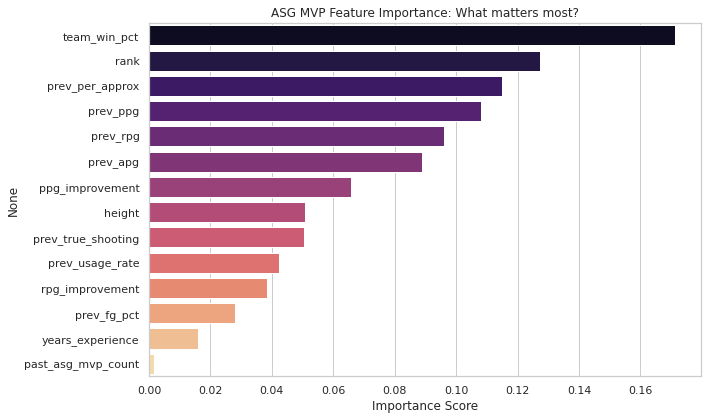

/tmp/ipykernel_12646/172373019.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_12646/172373019.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='coolwarm')
/tmp/ipykernel_12646/172373019.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='coolwarm')


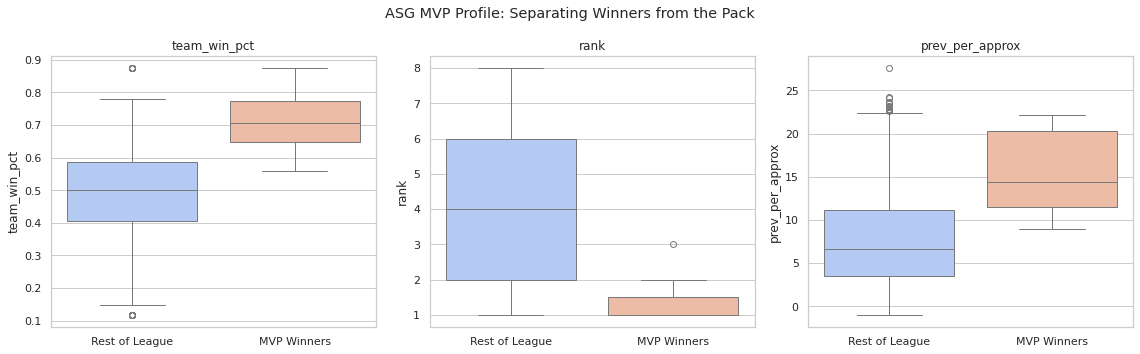

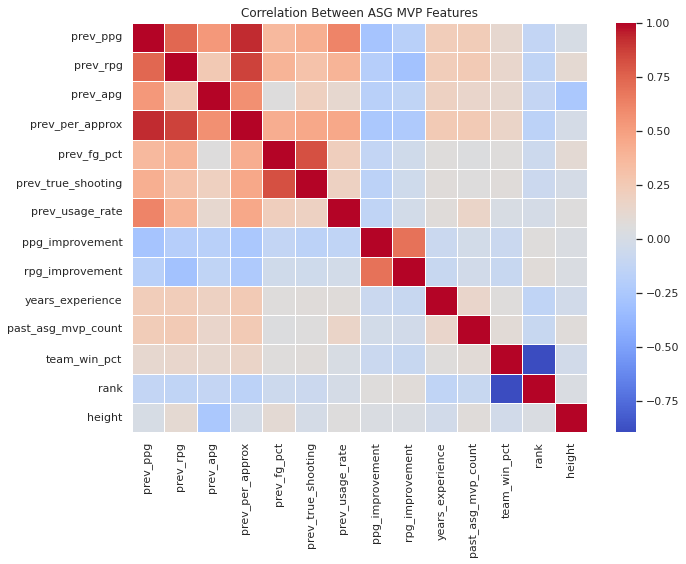

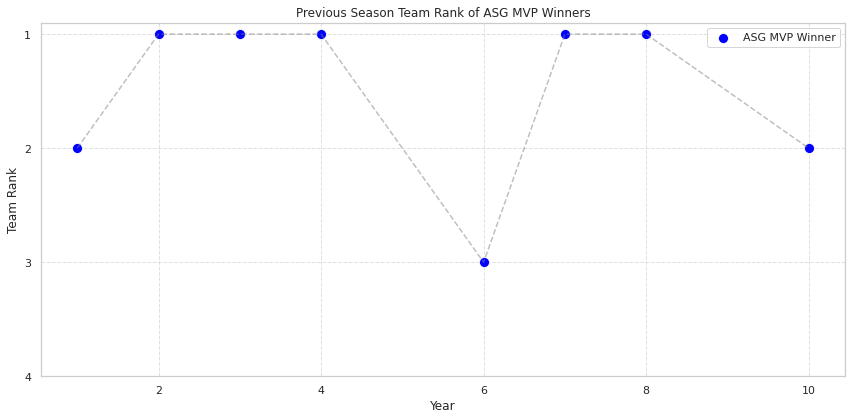

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

features = [
    'prev_ppg', 'prev_rpg', 'prev_apg', 'prev_per_approx', 
    'prev_fg_pct', 'prev_true_shooting', 'prev_usage_rate',
    'ppg_improvement', 'rpg_improvement',
    'years_experience', 'past_asg_mvp_count',
    'team_win_pct', 'rank', # Note: 'rank' is the Team Rank
    'height'
]

df_clean = df_features.dropna(subset=features).copy()

target = 'won_asg_mvp' 

print("\n--- SECTION 1: DATA ANALYSIS ---")
print(f"ASG MVP Winners in Dataset: {df_clean[target].sum()}")

# Train Initial Model for Importance
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42)
rf.fit(df_clean[features], df_clean[target])

# --- PLOT 1: Feature Importance ---
plt.figure(figsize=(10, 6))
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index, palette='magma')
plt.title('ASG MVP Feature Importance: What matters most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# --- PLOT 2: Winners vs Field (Top 3 Features) ---
top_3 = imp.index[:3].tolist()
df_plot = df_clean.copy()
df_plot['Status'] = df_plot[target].map({0: 'Rest of League', 1: 'MVP Winners'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, feature in enumerate(top_3):
    sns.boxplot(x='Status', y=feature, data=df_plot, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{feature}')
    axes[i].set_xlabel('')
plt.suptitle('ASG MVP Profile: Separating Winners from the Pack')
plt.tight_layout()
plt.show()

# --- PLOT 3: Correlation Heatmap ---
plt.figure(figsize=(10, 8))
corr = df_clean[features].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Between ASG MVP Features')
plt.tight_layout()
plt.show()

# --- PLOT 4: Trend of MVP Team Rank ---
# Using 'rank' which is the column name for team rank in your saved CSV
mvp_winners = df_features[df_features[target] == 1].sort_values('year')

plt.figure(figsize=(12, 6))
sns.scatterplot(data=mvp_winners, x='year', y='rank', s=100, color='blue', marker='o', label='ASG MVP Winner')
plt.plot(mvp_winners['year'], mvp_winners['rank'], linestyle='--', color='gray', alpha=0.5)

# Invert Y-axis because Rank 1 is better than Rank 6
plt.gca().invert_yaxis()
# Set Y-ticks to be integers only
plt.yticks(range(1, int(mvp_winners['rank'].max()) + 2))

plt.title('Previous Season Team Rank of ASG MVP Winners')
plt.xlabel('Year')
plt.ylabel('Team Rank')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


##### Feature Engineering & Data Loading

In [25]:
# 1. Load Data
df_features = pd.read_csv('../dataset_for_modeling/all_star_game_mvp_features.csv')
df_teams = pd.read_csv('../dataset_cleaned/teams.csv')
# df_awards could be loaded if needed for lookups, but past_mvp_count is in features

# 2. Feature Engineering
df_model = df_features[df_features['year'] > 1].copy()

# --- Add Previous Team Stats (Lagged) ---
# We want to predict based on the performance leading up to the ASG.
# Since ASG is mid-season, previous full season team stats are a strong prior.
df_teams_prev = df_teams[['year', 'tmID', 'won', 'lost', 'rank']].copy()
df_teams_prev.rename(columns={'rank': 'prev_team_rank'}, inplace=True)
df_teams_prev['prev_win_pct'] = df_teams_prev['won'] / (df_teams_prev['won'] + df_teams_prev['lost'])
df_teams_prev['next_year'] = df_teams_prev['year'] + 1

# Merge lagged team stats
df_model = pd.merge(df_model, df_teams_prev[['next_year', 'tmID', 'prev_win_pct', 'prev_team_rank']], 
                    left_on=['year', 'tmID'], right_on=['next_year', 'tmID'], how='left')

# --- Add Relative Stats ---
# Compare player's previous stats to the league average of that year
stats_to_normalize = ['prev_ppg', 'prev_per_approx', 'prev_true_shooting']
for col in stats_to_normalize:
    if col in df_model.columns:
        league_avg = df_model.groupby('year')[col].transform('mean')
        df_model[f'{col}_rel'] = df_model[col] - league_avg

# --- Add Score-Rank Feature ---
# Weighted scoring: High PPG on High Ranked Team (Low Rank Number) is better
# We use the Prev Team Rank we just merged
if 'prev_team_rank' in df_model.columns:
    max_rank = df_model['prev_team_rank'].max()
    # Fill NaN ranks with max_rank (worst case)
    df_model['prev_team_rank'] = df_model['prev_team_rank'].fillna(max_rank)
    df_model['score_rank'] = df_model['prev_ppg'] * ((max_rank + 1) - df_model['prev_team_rank'])

print("Feature Engineering Complete.")
print(df_model[['playerID', 'year', 'score_rank', 'prev_team_rank']].head())


Feature Engineering Complete.
     playerID  year  score_rank  prev_team_rank
0  abrossv01w     2         NaN             6.0
1  abrossv01w     3   39.576923             6.0
2  abrossv01w     4   11.629630             8.0
3  abrossv01w     5   53.000000             4.0
4  abrossv01w     6   39.818182             3.0


##### Model Training and Evaluation


--- FINAL PREDICTION PHASE (Train on Years 2-9, Predict Year 10) ---
>>> Top 10 Pre-Season ASG MVP Candidates (Year 10):
        playerID  mvp_prob   prev_ppg  prev_ppg_rel  rank  past_asg_mvp_count  \
254   catchta01w  0.220933  13.280000      5.057291     1                   0   
592   hoffmeb01w  0.178101  10.363636      2.140928     1                   0   
1411  tauradi01w  0.140218  24.117647     15.894938     1                   0   
1420  taylope01w  0.139450  17.794118      9.571409     1                   0   
366   douglka01w  0.132747  15.636364      7.413655     1                   1   
803   leslili01w  0.117210  15.060606      6.837897     3                   2   
1467  thompti01w  0.117152  18.066667      9.843958     3                   1   
1134  pondeca01w  0.110281  21.218750     12.996041     1                   0   
819   littlca01w  0.096798   9.736842      1.514134     2                   0   
648   jacksla01w  0.092531  20.238095     12.015387     2           

/tmp/ipykernel_12646/3794600244.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='magma')


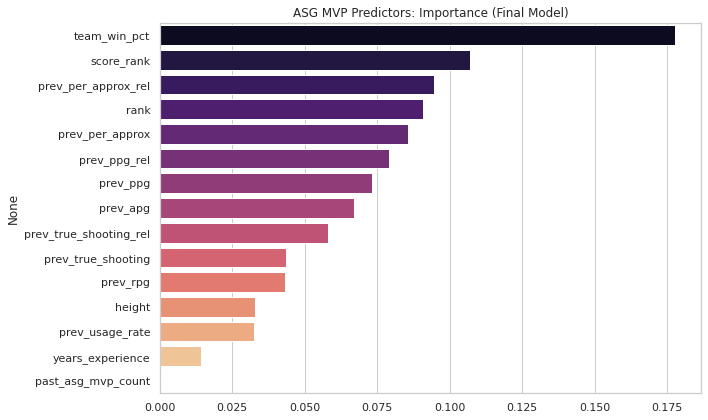

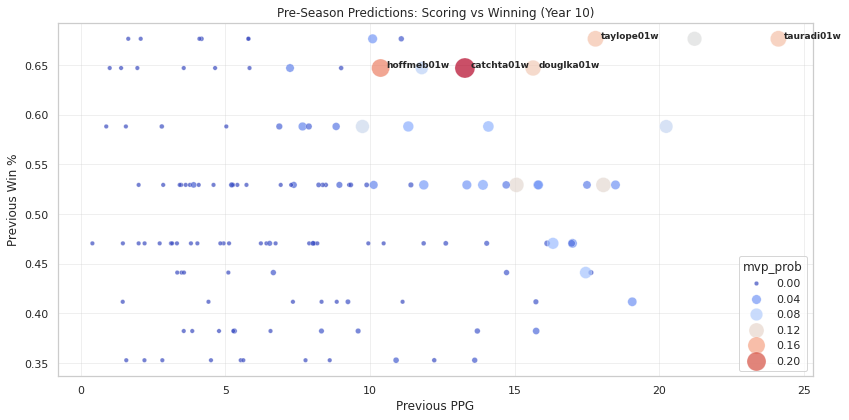

In [26]:
# Model Training and Evaluation

# 3. Define Features
features = [
    'prev_ppg', 'prev_rpg', 'prev_apg', 
    'prev_per_approx', 'prev_true_shooting',
    'years_experience', 'height',
    'rank',              # Team Rank
    'team_win_pct',      # Team Win %
    'score_rank',        # Engineered above
    'past_asg_mvp_count', # From CSV
    'prev_ppg_rel', 'prev_per_approx_rel', 'prev_true_shooting_rel', # Engineered above
    'prev_usage_rate'
]

# Clean Data
df_model = df_model.dropna(subset=features).copy()
target = 'won_asg_mvp'

# --- Final Prediction (Train 2-9, Test 10) ---
print("\n--- FINAL PREDICTION PHASE (Train on Years 2-9, Predict Year 10) ---")

train_final = df_model[df_model['year'] < 10]
test_final = df_model[df_model['year'] == 10].copy()

rf_final = RandomForestClassifier(n_estimators=500, class_weight='balanced', max_depth=5, random_state=42)
rf_final.fit(train_final[features], train_final[target])

test_final['mvp_prob'] = rf_final.predict_proba(test_final[features])[:, 1]
top_candidates = test_final.sort_values('mvp_prob', ascending=False).head(10)

print(">>> Top 10 Pre-Season ASG MVP Candidates (Year 10):")
# Adjust column names for printing
print(top_candidates[['playerID', 'mvp_prob', 'prev_ppg', 'prev_ppg_rel', 'rank', 'past_asg_mvp_count', 'prev_usage_rate', 'score_rank']])

# Feature Importance
plt.figure(figsize=(10, 6))
imp = pd.Series(rf_final.feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=imp.values, y=imp.index, palette='magma')
plt.title('ASG MVP Predictors: Importance (Final Model)')
plt.tight_layout()
plt.show()

# Landscape
plt.figure(figsize=(12, 6))
sns.scatterplot(data=test_final, x='prev_ppg', y='team_win_pct', size='mvp_prob', sizes=(20, 400), 
                hue='mvp_prob', palette='coolwarm', alpha=0.7)

for i in range(5):
    if i < len(top_candidates):
        player = top_candidates.iloc[i]
        plt.text(player['prev_ppg']+0.2, player['team_win_pct'], player['playerID'], fontsize=9, weight='bold')

plt.title('Pre-Season Predictions: Scoring vs Winning (Year 10)')
plt.xlabel('Previous PPG')
plt.ylabel('Previous Win %')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



--- SECTION 4: FORECASTING PERFORMANCE REPORT ---
--- STARTING ASG MVP FORECAST (Window=3) ---

[Year 5] No ASG Winner (Due to Olympic Year (2004 and 2008)).
>>> Hypothetical Top 5 (Excluded from Metrics):
  playerID  mvp_prob  prev_ppg  prev_team_rank
leslili01w  0.210000 18.434783             1.0
teaslni01w  0.101572 11.529412             1.0
jacksla01w  0.080000 21.151515             5.0
rileyru01w  0.065672  9.617647             1.0
nolande01w  0.059842 12.375000             1.0

[Year 9] No ASG Winner (Due to Olympic Year (2004 and 2008)).
>>> Hypothetical Top 5 (Excluded from Metrics):
  playerID  mvp_prob  prev_ppg  prev_team_rank
 fordch01w  0.304401 13.000000             1.0
mcwilta01w  0.147300 11.068966             1.0
powelni01w  0.128884 12.823529             3.0
brunsre01w  0.114714 11.454545             3.0
smithta01w  0.109498 12.588235             1.0

ASG MVP FORECAST RESULTS (Valid Years Only)
Overall ROC AUC: 0.6357

>>> Actual ASG MVP Winners & Model Ranks:
     y

/tmp/ipykernel_12646/1046831844.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette='viridis')


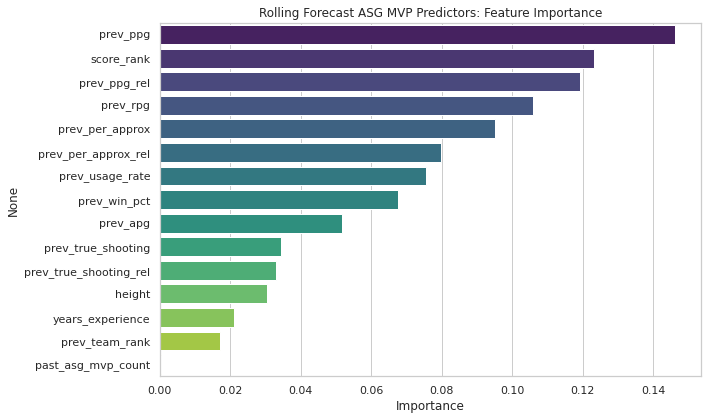

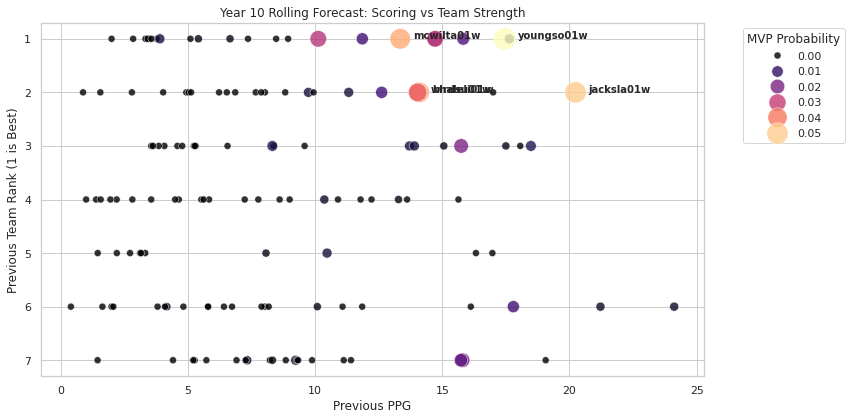

In [27]:
from sklearn.metrics import roc_auc_score

print("\n--- SECTION 4: FORECASTING PERFORMANCE REPORT ---")

WINDOW = 3
predictions = []
target = 'won_asg_mvp'

features = [
    'prev_ppg', 'prev_rpg', 'prev_apg', 
    'prev_per_approx', 'prev_true_shooting',
    'years_experience', 'height',
    'prev_team_rank',   
    'score_rank',
    'past_asg_mvp_count',
    'prev_ppg_rel', 'prev_per_approx_rel', 'prev_true_shooting_rel',
    'prev_usage_rate',
    'prev_win_pct'
]

print(f"--- STARTING ASG MVP FORECAST (Window={WINDOW}) ---")

for test_year in range(5, 11):
    
    start_train = test_year - WINDOW
    
    train = df_model[(df_model['year'] >= start_train) & (df_model['year'] < test_year)].copy()
    test = df_model[df_model['year'] == test_year].copy()
    
    if train.empty or test.empty: continue
    
    rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', max_depth=6, random_state=42, n_jobs=-1)
    rf.fit(train[features], train[target])
    
    test['mvp_prob'] = rf.predict_proba(test[features])[:, 1]
    
    n_winners = test[target].sum()
    
    if n_winners == 0:
        print(f"\n[Year {test_year}] No ASG Winner (Due to Olympic Year (2004 and 2008)).")
        print(">>> Hypothetical Top 5 (Excluded from Metrics):")
        top_hypothetical = test.sort_values('mvp_prob', ascending=False).head(5)
        print(top_hypothetical[['playerID', 'mvp_prob', 'prev_ppg', 'prev_team_rank']].to_string(index=False))
    else:
        predictions.append(test[['playerID', 'year', 'mvp_prob', target] + features])

# --- Output & Visualization ---
if predictions:
    df_preds = pd.concat(predictions, ignore_index=True)
    
    df_preds['rank'] = df_preds.groupby('year')['mvp_prob'].rank(ascending=False, method='first')
    
    print("\n" + "="*30)
    print("ASG MVP FORECAST RESULTS (Valid Years Only)")
    print("="*30)
    
    try:
        if df_preds[target].nunique() > 1:
            auc = roc_auc_score(df_preds[target], df_preds['mvp_prob'])
            print(f"Overall ROC AUC: {auc:.4f}")
        else:
            print("ROC AUC: N/A")
    except Exception as e:
        print(f"AUC Error: {e}")

    winners = df_preds[df_preds[target] == 1]
    print("\n>>> Actual ASG MVP Winners & Model Ranks:")
    cols_win = ['year', 'playerID', 'rank', 'mvp_prob', 'prev_ppg', 'prev_team_rank', 'past_asg_mvp_count']
    print(winners[cols_win].sort_values('year'))

    print("\n>>> Top 5 Predicted Candidates (Valid Years):")
    cols_top = ['year', 'playerID', 'rank', 'mvp_prob', 'prev_ppg', 'prev_team_rank']
    print(df_preds[df_preds['rank'] <= 5].sort_values(['year', 'rank'])[cols_top])

    rf_final_eval = RandomForestClassifier(n_estimators=500, class_weight='balanced', max_depth=6, random_state=42)
    rf_final_eval.fit(df_preds[features], df_preds[target])
    
    plt.figure(figsize=(10, 6))
    imp = pd.Series(rf_final_eval.feature_importances_, index=features).sort_values(ascending=False)
    sns.barplot(x=imp.values, y=imp.index, palette='viridis')
    plt.title('Rolling Forecast ASG MVP Predictors: Feature Importance')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    last_year_data = df_preds[df_preds['year'] == 10]
    if not last_year_data.empty:
        plt.figure(figsize=(12, 6))
        sns.scatterplot(
            data=last_year_data, x='prev_ppg', y='prev_team_rank',
            size='mvp_prob', sizes=(50, 500), hue='mvp_prob', palette='magma', alpha=0.8
        )
        plt.gca().invert_yaxis()
        
        top_5 = last_year_data.sort_values('mvp_prob', ascending=False).head(5)
        for _, row in top_5.iterrows():
            plt.text(row['prev_ppg']+0.5, row['prev_team_rank'], row['playerID'], fontsize=10, weight='bold')
            
        plt.title('Year 10 Rolling Forecast: Scoring vs Team Strength')
        plt.xlabel('Previous PPG')
        plt.ylabel('Previous Team Rank (1 is Best)')
        plt.legend(title='MVP Probability', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
else:
    print("No predictions generated.")
    

##### Final Prediction for Test Year 11

In [29]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- SECTION 5: FUTURE PREDICTION (Year 11) ---")

# We need raw player stats (df_pt) again to calculate Year 10 stats for Year 11 prediction
df_players_teams_raw = pd.read_csv('../dataset_cleaned/players_teams.csv')
df_players_bio_raw = pd.read_csv('../dataset_cleaned/players.csv')
df_teams_raw = pd.read_csv('../dataset_cleaned/teams.csv')
df_awards_raw = pd.read_csv('../dataset_cleaned/awards_players.csv')

# Re-create df_pt (Player Stats)
df_pt = df_players_teams_raw[df_players_teams_raw['stint'] == 0].copy()
df_pt['ppg'] = df_pt['points'] / df_pt['GP']
df_pt['rpg'] = df_pt['rebounds'] / df_pt['GP']
df_pt['apg'] = df_pt['assists'] / df_pt['GP']
df_pt['fg_pct'] = df_pt['fgMade'] / df_pt['fgAttempted']
df_pt['true_shooting'] = df_pt['points'] / (2 * (df_pt['fgAttempted'] + 0.44 * df_pt['ftAttempted']))
df_pt['per_approx'] = df_pt['true_shooting'] # Proxy
df_pt['usage_rate'] = (df_pt['fgAttempted'] + 0.44 * df_pt['ftAttempted'] + df_pt['turnovers']) / df_pt['minutes']

# Merge Bio
df_bio_simple = df_players_bio_raw[['bioID', 'height', 'birthDate']].rename(columns={'bioID': 'playerID'})
df_pt = pd.merge(df_pt, df_bio_simple, on='playerID', how='left')
df_pt['year'] = df_pt['year'].astype(int)
df_pt['years_experience'] = df_pt.groupby('playerID')['year'].transform('rank', method='min')

# 2. Prepare Base Data for Year 11 Prediction
# We use Year 10 stats as the 'previous' stats for Year 11
df_year10_stats = df_pt[
    (df_pt['year'] == 10) & 
    (df_pt['GP'] >= 10) & 
    (df_pt['minutes'] >= 100)
].copy()

# Get Year 10 Team Ranks (to use as prev_team_rank for Year 11)
df_year10_teams = df_teams_raw[df_teams_raw['year'] == 10][['tmID', 'rank', 'won', 'lost']].copy()
df_year10_teams['win_pct'] = df_year10_teams['won'] / (df_year10_teams['won'] + df_year10_teams['lost'])

# Map Year 10 stats to 'prev_' columns
df_year11 = df_year10_stats[['playerID', 'tmID', 'years_experience', 'height']].copy()
df_year11['year'] = 11

cols_map = {
    'ppg': 'prev_ppg', 'rpg': 'prev_rpg', 'apg': 'prev_apg', 
    'per_approx': 'prev_per_approx', 'true_shooting': 'prev_true_shooting',
    'usage_rate': 'prev_usage_rate'
}
for curr, prev in cols_map.items():
    df_year11[prev] = df_year10_stats[curr].values

# Merge Team Stats (Year 10 Team Rank becomes 'prev_team_rank')
df_year11 = pd.merge(df_year11, df_year10_teams[['tmID', 'rank', 'win_pct']], on='tmID', how='left')
df_year11.rename(columns={'rank': 'prev_team_rank', 'win_pct': 'prev_win_pct'}, inplace=True)

# Relative Stats
stats_to_normalize = ['prev_ppg', 'prev_per_approx', 'prev_true_shooting']
for col in stats_to_normalize:
    if col in df_year11.columns:
        league_avg = df_year11[col].mean()
        df_year11[f'{col}_rel'] = df_year11[col] - league_avg

# Score-Rank Feature
max_rank = df_year11['prev_team_rank'].max()
if pd.isna(max_rank): max_rank = 6 # Fallback
df_year11['prev_team_rank'] = df_year11['prev_team_rank'].fillna(max_rank)
df_year11['score_rank'] = df_year11['prev_ppg'] * ((max_rank + 1) - df_year11['prev_team_rank'])

# Past MVP Count (Including Year 10 winner)
year10_winner_row = df_awards_raw[
    (df_awards_raw['year'] == 10) & 
    (df_awards_raw['award'] == 'All-Star Game Most Valuable Player')
]
year10_winner_id = year10_winner_row['playerID'].values[0] if not year10_winner_row.empty else None

def get_updated_past_wins(pid):
    # Count wins in years 1-9
    past_wins = len(df_awards_raw[
        (df_awards_raw['playerID'] == pid) & 
        (df_awards_raw['award'] == 'All-Star Game Most Valuable Player') & 
        (df_awards_raw['year'] < 10)
    ])
    # Add Year 10 win if applicable
    if pid == year10_winner_id:
        past_wins += 1
    return past_wins

df_year11['past_asg_mvp_count'] = df_year11['playerID'].apply(get_updated_past_wins)

# 5. Predict
features_list = [
    'prev_ppg', 'prev_rpg', 'prev_apg', 
    'prev_per_approx', 'prev_true_shooting',
    'years_experience', 'height',
    'prev_team_rank', 'score_rank',
    'past_asg_mvp_count',
    'prev_ppg_rel', 'prev_per_approx_rel', 'prev_true_shooting_rel',
    'prev_usage_rate', 'prev_win_pct'
]

# Ensure training data (df_model) is ready from previous sections
X_all = df_model[features_list]
y_all = df_model['won_asg_mvp']

# Retrain model on ALL available data (Years 2-10)
rf_final_y11 = RandomForestClassifier(n_estimators=500, class_weight='balanced', max_depth=6, random_state=42)
rf_final_y11.fit(X_all, y_all)

# Generate Probabilities
df_year11_clean = df_year11.dropna(subset=features_list).copy()
df_year11_clean['mvp_prob'] = rf_final_y11.predict_proba(df_year11_clean[features_list])[:, 1]

# 6. Show Results
print("\nPrediction: Top 10 All-Star Game MVP Candidates for Year 11:")
top_candidates_y11 = df_year11_clean.sort_values('mvp_prob', ascending=False).head(10)
print(top_candidates_y11[['playerID', 'mvp_prob', 'prev_ppg', 'prev_team_rank', 'past_asg_mvp_count', 'score_rank']])



--- SECTION 5: FUTURE PREDICTION (Year 11) ---

Prediction: Top 10 All-Star Game MVP Candidates for Year 11:
       playerID  mvp_prob   prev_ppg  prev_team_rank  past_asg_mvp_count  \
18   catchta01w  0.174485  15.058824               1                   0   
27   dupreca01w  0.095354  15.705882               5                   0   
26   douglka01w  0.093126  17.645161               1                   1   
91   parkeca01w  0.081294  13.120000               3                   0   
114  thompti01w  0.070088  12.970588               3                   1   
68   lyttlsa01w  0.068451  13.029412               2                   0   
44   holdsch01w  0.067252  13.920000               2                   0   
129  youngso01w  0.066107  18.181818               4                   0   
16    cashsw01w  0.063338  12.187500               2                   1   
43   hoffmeb01w  0.054015   9.941176               1                   0   

     score_rank  
18   105.411765  
27    47.117647  